# Notebook - Find best Drug compound for Ebola virus (include all species)

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [195]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [196]:
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

#Needed to show molecules
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 
import seaborn as sns
from copy import deepcopy
import pickle

import sys
sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600

%run "./plotting.py"

1.0.1


In [197]:
%config InlineBackend.figure_format = 'retina'

## 1. Regression Target: pPotency

### 1.1 Data preparation

In [246]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')
saveDir = os.path.join(resultsDir, "EbolaAllSpecies/")
os.makedirs(saveDir, exist_ok=True)

In [199]:
EbolaAllSpeciesData_chEMBL_uM = pd.read_csv(modelBuildingDataDir + 'EbolaAllStrainsData_chEMBL_uM.csv')

In [200]:
EbolaAllSpeciesData_chEMBL_uM

,Unnamed: 0,strain,molecule_chembl_id,smiles,molecular_formula,inchi_key,inchi,molecular_weight,type,standard_value,...,qed_weighted,heavy_atoms,aromatic_rings,ro5_violations,Target ChEMBL ID,Target Name,Target Organism,value_uM,pPotency,pPotencyMid
0,2,Ebola,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,C11H15N5O3,CVSSXRUFNBCRPB-UHFFFAOYSA-N,InChI=1S/C11H15N5O3/c1-18-10-8(4-13-11(12)15-1...,265.27,Small molecule,100000.0,...,0.70,19.0,2.0,0.0,CHEMBL4434621,Ebolavirus,Ebolavirus,100.00,NaN,4.000000
1,5,Ebola,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,C12H14N4O3,PCJCKCSFBICBNZ-NRZXQICZSA-N,InChI=1S/C12H14N4O3/c13-12-9-7(1-2-14-12)16(5-...,262.27,Small molecule,320.0,...,0.56,19.0,2.0,0.0,CHEMBL4434621,Ebolavirus,Ebolavirus,0.32,NaN,6.494850
2,6,Ebola,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C37H42N3O5P,BCNOLUKYPQLFDY-UHFFFAOYSA-N,"InChI=1S/C37H42N3O5P/c1-3-43-46(41,44-4-2)27-3...",639.73,Unknown,1880.0,...,0.12,46.0,5.0,2.0,CHEMBL4434621,Ebolavirus,Ebolavirus,1.88,5.725842,5.725842
3,7,Ebola,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,C38H41F3N3O5P,YPONQFDDBHJAOJ-UHFFFAOYSA-N,"InChI=1S/C38H41F3N3O5P/c1-3-47-50(45,48-4-2)26...",707.73,Unknown,2490.0,...,0.12,50.0,5.0,2.0,CHEMBL4434621,Ebolavirus,Ebolavirus,2.49,5.603801,5.603801
4,8,Ebola,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,C43H65N6O9P,VXYCOVDOXKSLFC-NKSQPNMBSA-N,InChI=1S/C43H65N6O9P/c1-5-8-9-10-11-12-13-14-1...,841.00,Unknown,50000.0,...,0.04,59.0,3.0,3.0,CHEMBL4434621,Ebolavirus,Ebolavirus,50.00,NaN,4.301030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1107,1420,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.62,NaN,520.0,...,0.34,34.0,4.0,1.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,0.52,6.283997,6.283997
1108,1421,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,C29H34N4O,IJMIYPOMQDWUPR-UHFFFAOYSA-N,InChI=1S/C29H34N4O/c34-29(31-33-27-12-6-4-10-2...,454.62,NaN,520.0,...,0.34,34.0,4.0,1.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,0.52,6.283997,6.283997
1109,1422,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.61,NaN,1900.0,...,0.35,33.0,3.0,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,1.90,5.721246,5.721246
1110,1423,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,C28H34N4O,ARYIHVDLZUTPHU-UHFFFAOYSA-N,InChI=1S/C28H34N4O/c33-28(30-32(26-12-6-2-7-13...,442.61,NaN,1900.0,...,0.35,33.0,3.0,0.0,CHEMBL4513181,Zaire ebolavirus,Zaire ebolavirus,1.90,5.721246,5.721246


### Filter columns and keeping only data for Ebola virus

In [201]:
EbolaAllSpeciesData_chEMBL_uM =  EbolaAllSpeciesData_chEMBL_uM.filter(
    items=["strain","molecule_chembl_id", "smiles", "pPotencyMid"]
)
EbolaAllSpeciesData_chEMBL_uM

,strain,molecule_chembl_id,smiles,pPotencyMid
0,Ebola,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,4.000000
1,Ebola,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850
2,Ebola,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.725842
3,Ebola,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.603801
4,Ebola,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,4.301030
...,...,...,...,...
1107,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997
1108,ZaireEbola,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.283997
1109,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246
1110,ZaireEbola,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721246


### Remove `Remdesivir` from training set

In [202]:
Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'

# Canonicalize the Remdesivir SMILES
remMol = Chem.MolFromSmiles(Remdesivir_SMILES)
remCan = Chem.MolToSmiles(remMol, canonical=True)

# Canonicalize all SMILES in your dataframe
EbolaAllSpeciesData_chEMBL_uM["canonical_smiles"] = (
    EbolaAllSpeciesData_chEMBL_uM["smiles"]
    .apply(lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(s), canonical=True)
          if Chem.MolFromSmiles(s) else None)
)

# Remove rows matching Remdesivir
mask = EbolaAllSpeciesData_chEMBL_uM["canonical_smiles"] != remCan
EbolaAllSpeciesData_chEMBL_uM_clean = EbolaAllSpeciesData_chEMBL_uM[mask].copy()

print("Original shape of data frame:", len(EbolaAllSpeciesData_chEMBL_uM))
print("After removing Remdesivir:", len(EbolaAllSpeciesData_chEMBL_uM_clean))
EbolaAllSpeciesData_chEMBL_uM = EbolaAllSpeciesData_chEMBL_uM_clean.copy()

Original shape of data frame: 1112
After removing Remdesivir: 1088


### Rename columns

In [203]:
EbolaAllSpeciesData_chEMBL_uM = EbolaAllSpeciesData_chEMBL_uM.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
    "strain" : "StrainClassifier",
    "pPotencyMid" : "pPotency"
})

### Compound Distribution Across Viruses

In [204]:
virus_counts = EbolaAllSpeciesData_chEMBL_uM['StrainClassifier'].value_counts().sort_values(ascending=False)
total_compounds = len(EbolaAllSpeciesData_chEMBL_uM)

print(f"\n{'Strain':<30} {'Count':>10} {'Percentage':>12}")
print("-"*70)

for virus, count in virus_counts.items():
    percentage = (count / total_compounds) * 100
    print(f"{virus:<30} {count:>10} {percentage:>11.2f}%")

print("-"*70)
print(f"{'TOTAL':<30} {total_compounds:>10} {100.0:>11.2f}%")
print(f"\nNumber of unique viruses: {len(virus_counts)}")


Strain                              Count   Percentage
----------------------------------------------------------------------
Ebola                                 816       75.00%
ZaireEbola                            135       12.41%
SudanEbola                             65        5.97%
BundibugyoEbola                        36        3.31%
TaiForestEbola                         36        3.31%
----------------------------------------------------------------------
TOTAL                                1088      100.00%

Number of unique viruses: 5


### Add `ID` column to left

In [205]:
EbolaAllSpeciesData_chEMBL_uM.insert(0, 'ID', range(1, len(EbolaAllSpeciesData_chEMBL_uM) + 1))
EbolaAllSpeciesData_chEMBL_uM.head()

,ID,StrainClassifier,compound_id,Smiles,pPotency,canonical_smiles
0,1,Ebola,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,4.000000,COc1nc(N)ncc1-c1cn(COCCO)cn1
1,2,Ebola,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O
2,3,Ebola,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.725842,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...
3,4,Ebola,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.603801,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...
4,5,Ebola,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,4.301030,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...


### Add another filer to keep only these four columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `StrainClassifier`

In [206]:
EbolaAllSpeciesData_chEMBL_uM = EbolaAllSpeciesData_chEMBL_uM.filter(
    items=["ID", "compound_id", "Smiles", "pPotency", "StrainClassifier"]
)
EbolaAllSpeciesData_chEMBL_uM.head()

,ID,compound_id,Smiles,pPotency,StrainClassifier
0,1,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,4.000000,Ebola
1,2,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850,Ebola
2,3,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.725842,Ebola
3,4,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.603801,Ebola
4,5,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,4.301030,Ebola


In [207]:
# Define bins and labels
bins = [0, 3, 10, 12, float('inf')]
labels = ['0-3', '3-10', '10-12', '> 12']

# Create categories
EbolaAllSpeciesData_chEMBL_uM['pPotency_category'] = pd.cut(
    EbolaAllSpeciesData_chEMBL_uM['pPotency'], 
    bins=bins, 
    labels=labels, 
    right=False  # right=False means 0 <= x < 3, 3 <= x < 10, etc.
)

# Count values per category
category_counts = EbolaAllSpeciesData_chEMBL_uM['pPotency_category'].value_counts().sort_index()
print("pPotency Distribution:")
print(category_counts)
print(f"\nTotal: {category_counts.sum()}")

pPotency Distribution:
pPotency_category
0-3         0
3-10     1082
10-12       6
> 12        0
Name: count, dtype: int64

Total: 1088


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | Drop         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep (with caution)** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [208]:
print("Original shape:", EbolaAllSpeciesData_chEMBL_uM.shape)

EbolaAllSpeciesData_chEMBL_uM = EbolaAllSpeciesData_chEMBL_uM[EbolaAllSpeciesData_chEMBL_uM['pPotency'].notna() 
    & (EbolaAllSpeciesData_chEMBL_uM['pPotency'] > 0)  & (EbolaAllSpeciesData_chEMBL_uM['pPotency'] < 12)]

print("Shape after cleaning 'pPotency' value:", EbolaAllSpeciesData_chEMBL_uM.shape)

Original shape: (1088, 6)
Shape after cleaning 'pPotency' value: (1088, 6)


In [209]:
duplicates = EbolaAllSpeciesData_chEMBL_uM.duplicated(subset=['Smiles', 'StrainClassifier'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 484


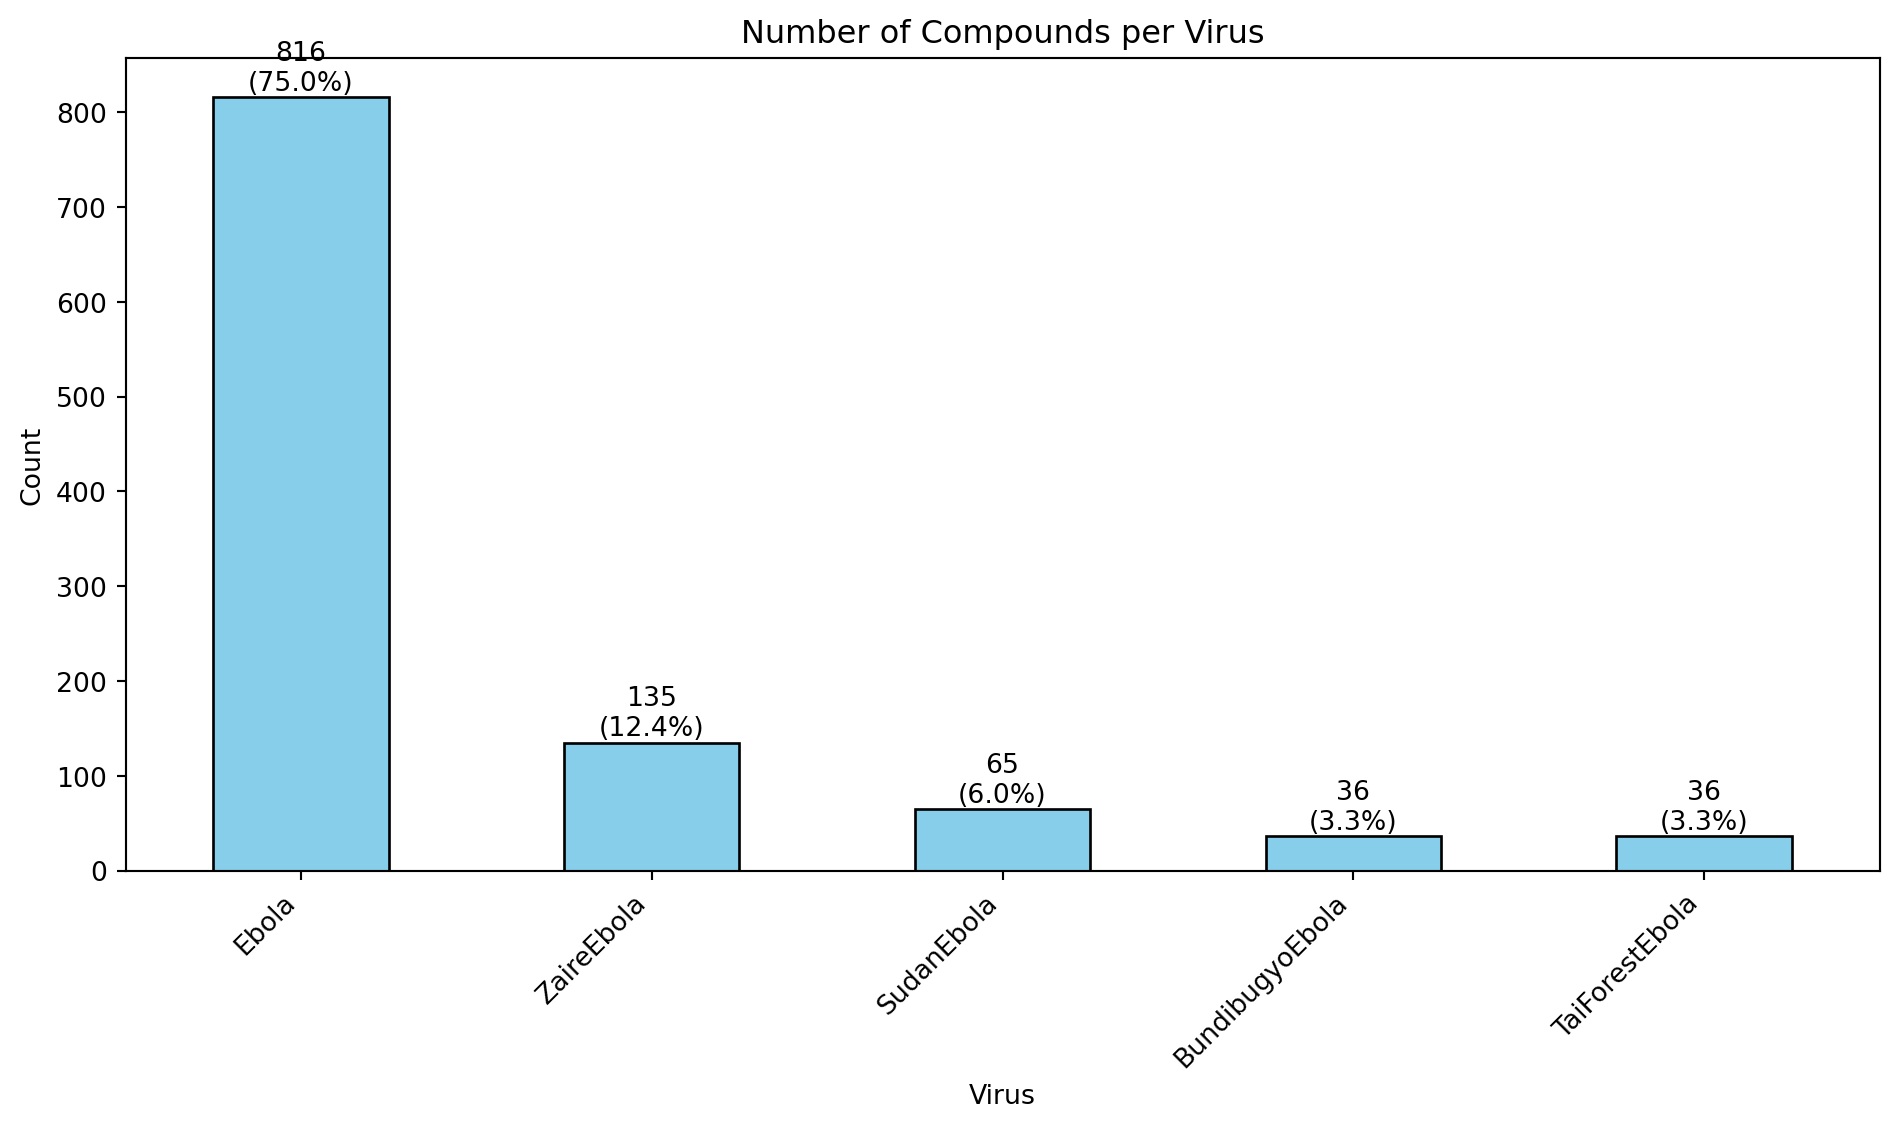

In [210]:
# Get counts and percentages
counts = EbolaAllSpeciesData_chEMBL_uM['StrainClassifier'].value_counts()
percentages = counts / counts.sum() * 100

# Create bar plot
plt.figure(figsize=(10, 6))
bars = counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Compounds per Virus')
plt.xlabel('Virus')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with count and %
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(
        i, count + 1,                 # position (x, y)
        f'{count}\n({pct:.1f}%)',     # label: count + percentage
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [211]:
EbolaAllSpeciesData_chEMBL_uM.to_csv(os.path.join(modelBuildingDataDir, "EbolaAllSpeciesData_chEMBL_uM_MLready.csv"), index=False)

### pPotency value distribution across each Virus

In [212]:
EbolaAllSpeciesData_chEMBL_uM_ordered = EbolaAllSpeciesData_chEMBL_uM.sort_values(by='StrainClassifier')
EbolaAllSpeciesData_chEMBL_uM_ordered.head()

,ID,compound_id,Smiles,pPotency,StrainClassifier,pPotency_category
847,824,CHEMBL5594836,CN(C)C1CCN(C(=O)c2cc3sccc3n2Cc2ccc(Cl)cc2)CC1,5.721246,BundibugyoEbola,3-10
856,833,CHEMBL5593153,CN(C)C1CCN(C(=O)c2cc3occc3n2Cc2ccc(Cl)cc2)CC1,5.701147,BundibugyoEbola,3-10
855,832,CHEMBL5583881,CN(C)CCNC(=O)c1cc2occc2n1Cc1ccc(Cl)cc1,5.709965,BundibugyoEbola,3-10
853,830,CHEMBL5583881,CN(C)CCNC(=O)c1cc2occc2n1Cc1ccc(Cl)cc1,5.709965,BundibugyoEbola,3-10
852,829,CHEMBL5583881,CN(C)CCNC(=O)c1cc2occc2n1Cc1ccc(Cl)cc1,5.709965,BundibugyoEbola,3-10


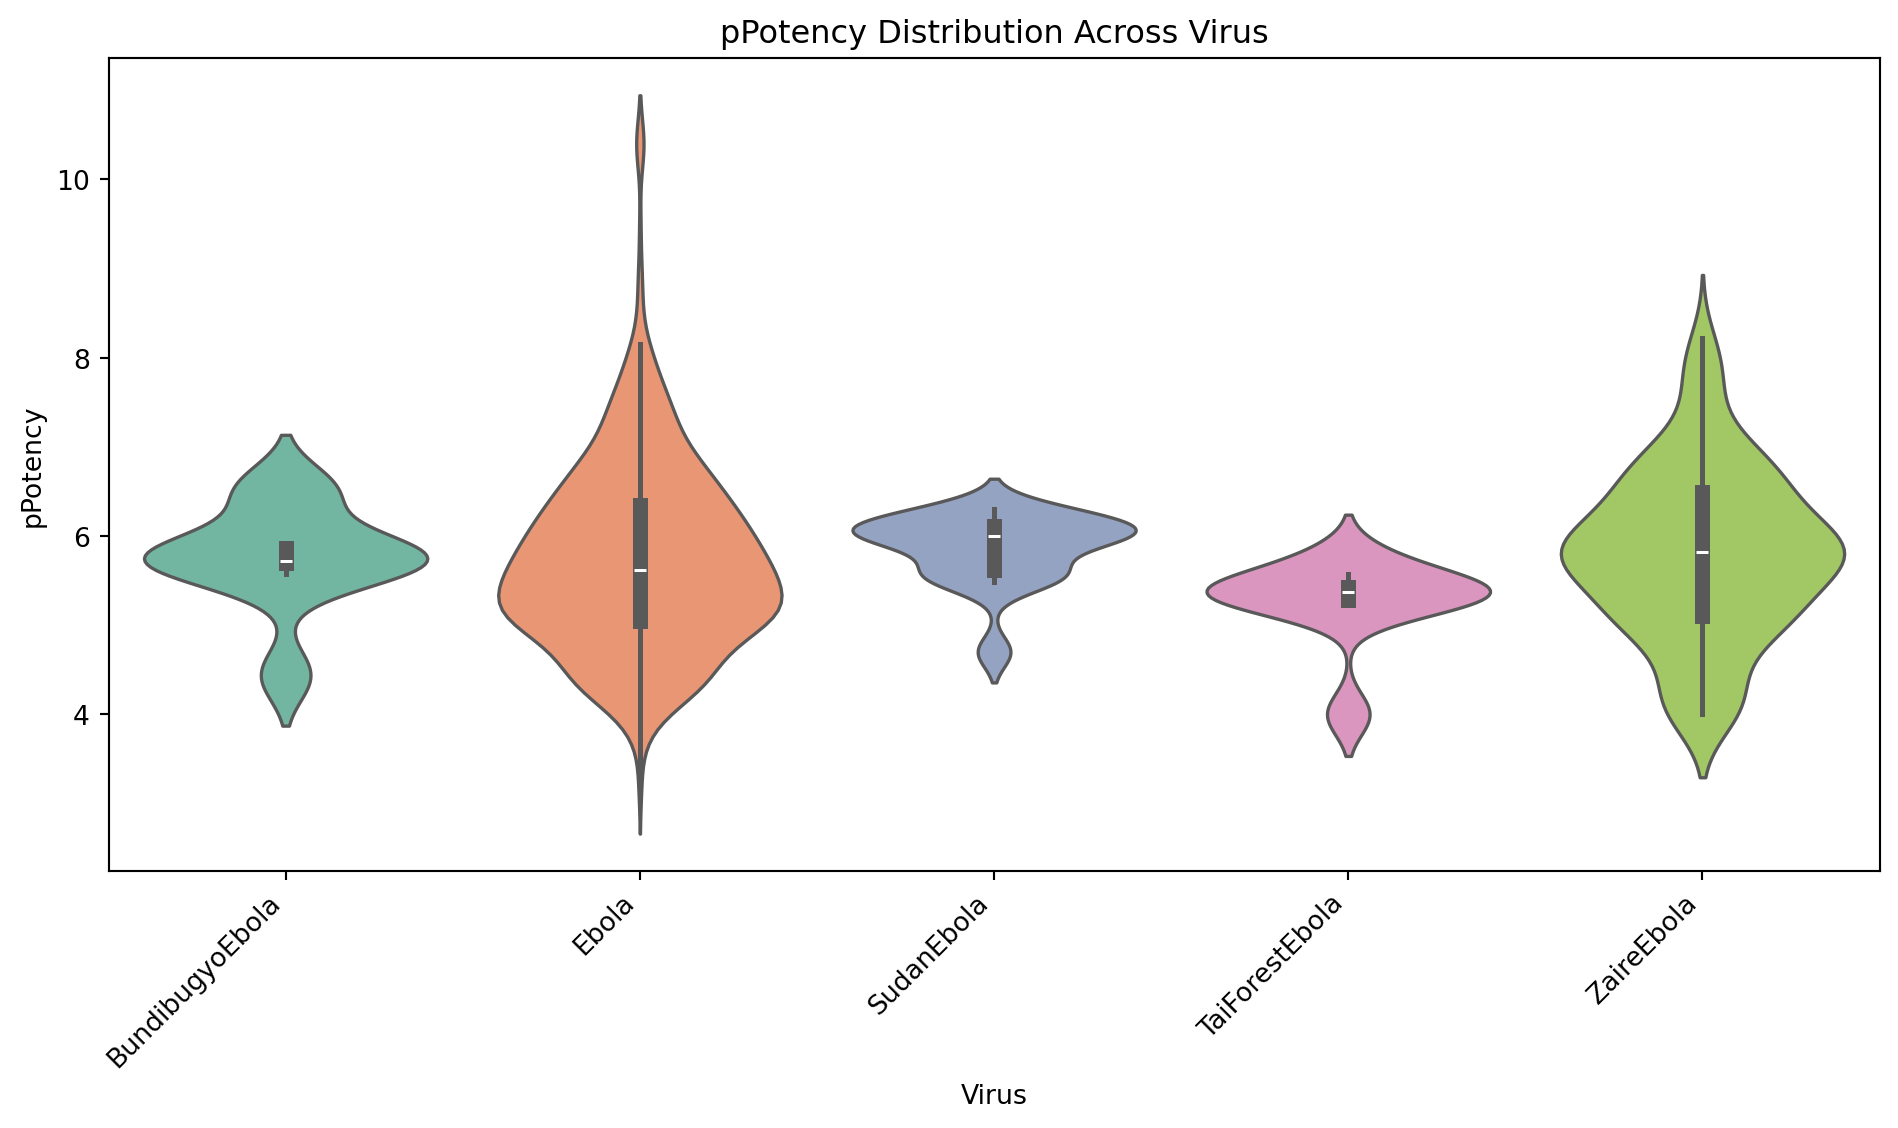

In [213]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=EbolaAllSpeciesData_chEMBL_uM_ordered,
    x='StrainClassifier',
    y='pPotency',
    palette='Set2',
    inner='box'
)

plt.xticks(rotation=45, ha='right')
plt.title('pPotency Distribution Across Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

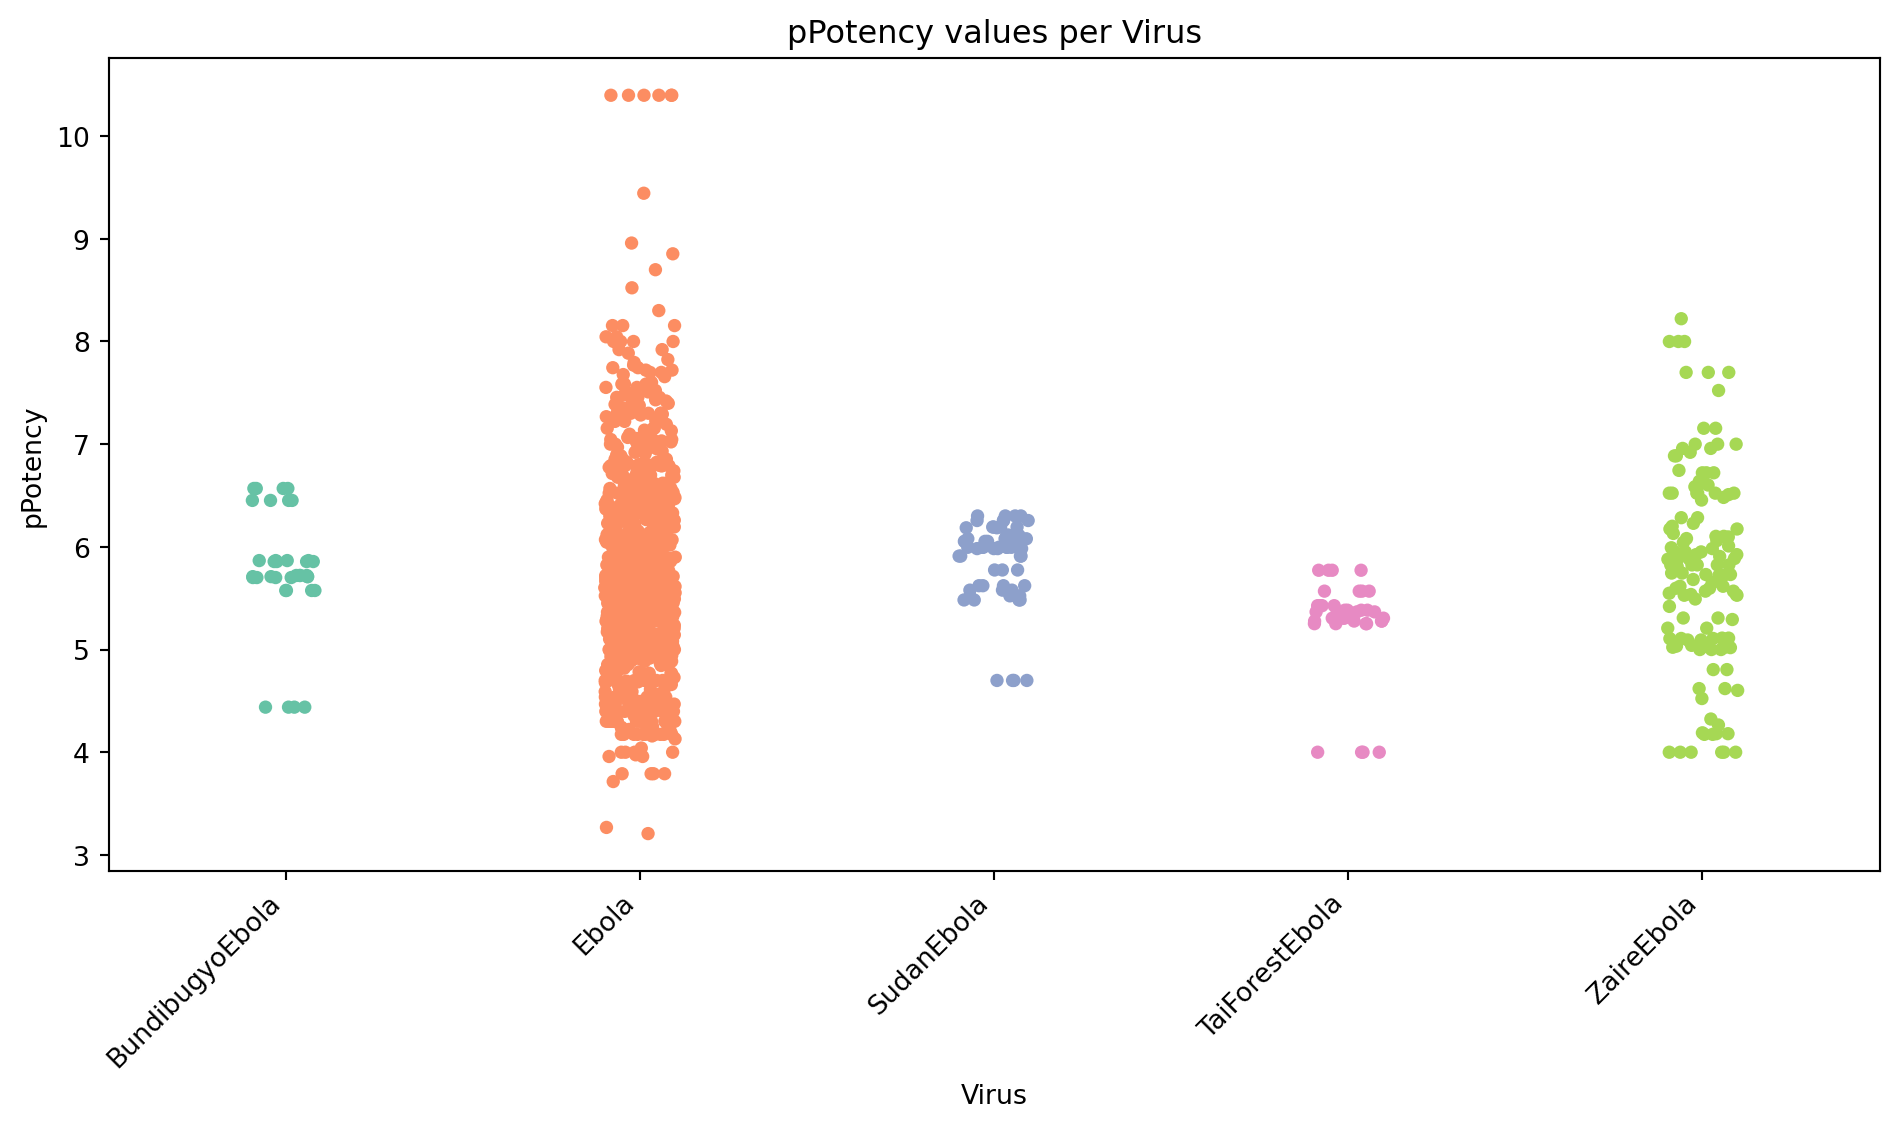

In [214]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=EbolaAllSpeciesData_chEMBL_uM_ordered,
    x='StrainClassifier',
    y='pPotency',
    jitter=True,          # spreads the dots to avoid overlap
    palette='Set2',
    alpha=1
)
plt.xticks(rotation=45, ha='right')
plt.title('pPotency values per Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

### Clip first 1000 rows from the data set for fast testing

### Create MACAW embeedings to run ART

In [215]:
# ---------------------------
# 1. FIT MACAW AND GENERATE EMBEDDINGS
# ---------------------------
# Initialize MACAW
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=42
)

# Fit MACAW on SMILES and pPotency
mcw.fit(EbolaAllSpeciesData_chEMBL_uM['Smiles'], EbolaAllSpeciesData_chEMBL_uM['pPotency'])

# Save MACAW transformer
macaw_save_path = os.path.join(modelBuildingDataDir, "EbolaAllSpeciesData_chEMBL_uM_MACAW_transformer.pkl")
with open(macaw_save_path, 'wb') as f:
    pickle.dump(mcw, f)
print(f"MACAW transformer saved to: {macaw_save_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(EbolaAllSpeciesData_chEMBL_uM['Smiles'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")

# ---------------------------
# 2. CREATE DATAFRAME WITH EMBEDDINGS
# ---------------------------
# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=EbolaAllSpeciesData_chEMBL_uM.index)

# ---------------------------
# 3. CONCATENATE WITH ORIGINAL DATAFRAME
# ---------------------------
EbolaAllSpeciesData_chEMBL_wMACAW = pd.concat([EbolaAllSpeciesData_chEMBL_uM, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {EbolaAllSpeciesData_chEMBL_uM.shape}")
print(f"New dataframe shape: {EbolaAllSpeciesData_chEMBL_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
EbolaAllSpeciesData_chEMBL_wMACAW.head()

MACAW transformer saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/modelBuildingData/EbolaAllSpeciesData_chEMBL_uM_MACAW_transformer.pkl
MACAW embeddings shape: (1088, 15)

Original dataframe shape: (1088, 6)
New dataframe shape: (1088, 21)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15']


,ID,compound_id,Smiles,pPotency,StrainClassifier,pPotency_category,MACAW_1,MACAW_2,MACAW_3,MACAW_4,...,MACAW_6,MACAW_7,MACAW_8,MACAW_9,MACAW_10,MACAW_11,MACAW_12,MACAW_13,MACAW_14,MACAW_15
0,1,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,4.000000,Ebola,3-10,0.078685,-0.163957,0.067417,0.020231,...,0.045227,-0.038880,0.160021,0.033269,-0.037613,0.050856,-0.072541,0.082323,0.040355,-0.004011
1,2,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.494850,Ebola,3-10,0.089042,-0.245224,0.134363,0.056285,...,0.161302,-0.067264,0.335167,0.153361,-0.123716,0.082700,0.212669,0.037156,-0.010502,-0.031821
2,3,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.725842,Ebola,3-10,-0.122037,0.037083,0.126166,-0.034602,...,-0.025209,-0.026038,-0.050838,0.017113,-0.005441,0.027663,-0.030286,0.057323,-0.056247,-0.036988
3,4,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.603801,Ebola,3-10,-0.146102,0.028717,0.121921,-0.044233,...,-0.031028,0.003689,-0.048836,0.016655,-0.025587,0.033879,-0.037771,0.032299,-0.081758,-0.018162
4,5,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,4.301030,Ebola,3-10,-0.253778,-0.012020,0.206724,-0.155691,...,-0.002318,0.099625,-0.075176,0.002071,0.011182,0.034365,-0.079043,0.028934,-0.134625,-0.076351


In [216]:
EbolaAllSpeciesData_chEMBL_wMACAW.to_csv(os.path.join(modelBuildingDataDir, "EbolaAllSpeciesData_chEMBL_wMACAW.csv"), index=False)

### Create directory to save plot

In [217]:
save_path = resultsDir + 'EbolaAllSpecies/EbolaAllSpecies_CV_testOnly.svg'
os.makedirs(os.path.dirname(save_path), exist_ok=True)

### Train ML Model

Define the partitions for cross-validation.

Define hyperparameters for SVR:

Define MACAW embedding:

After cleaning NaN values, reset the indices

### ML predictions with Train + Test results

Generate a model trained on the whole data set, to be used for prediction tasks

### Compare performance of different ML model

- SVR
- Random Forest
- XGBoost
- LightGBM
- CatBoost
- Neural Network

Import all necessary libraries

## 2.1 Discovery of new hits specific to all viruses (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [ ]:
EnamineAntiviralsData = pd.read_csv(dataDir + "Enamine/Enamine_Antiviral_Library_plated_3200cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                    skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntiviralsData.shape}")

smiles_train = EbolaAllSpeciesData_chEMBL_wMACAW.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntiviralsData['Canonical_SMILES'] = EnamineAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntiviralsData['Canonical_SMILES'].isin(canonical_train)
EnamineAntiviralsData_filtered = EnamineAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntiviralsData = EnamineAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntiviralsData.shape}")
print(f"Removed {EnamineAntiviralsData.shape[0] - EnamineAntiviralsData_filtered.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib_EnamineDataset = EnamineAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib_EnamineDataset)}")
EnamineAntiviralsData.head()

Generate predictions for the H1 receptor:

In [ ]:
smi_lib_EnamineDataset_wMACAW = mcw.transform(smi_lib_EnamineDataset)

# Create column names
num_features = smi_lib_EnamineDataset_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
SMILES_lib_EnamineDataset = pd.DataFrame(smi_lib_EnamineDataset_wMACAW, columns=column_names, index=smi_lib_EnamineDataset.index)
# Then add SMILES as first column
SMILES_lib_EnamineDataset.insert(0, 'SMILES', smi_lib_EnamineDataset)
# Save to CSV
SMILES_lib_EnamineDataset.to_csv(os.path.join(saveDir, "EbolaAllSpecies_EnamineDataset_wMACAW.csv"), index=False)
SMILES_lib_EnamineDataset

read results from ART predictions

In [ ]:
EnamineAntiviralsData_predicted = pd.read_csv(saveDir + 'EbolaAllSpecies_wART_EnamineDataset_predicted_all.csv')
max_val = EnamineAntiviralsData_predicted['pPotency_prediction'].max()
min_val = EnamineAntiviralsData_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

EnamineAntiviralsData_predicted

Let us represent the predictions of both models:

In [ ]:
Y1_lib_pred = EnamineAntiviralsData_predicted['pPotency_prediction'].values

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'EbolaAllSpecies_validation_wART.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'EbolaAllSpecies_validation_wART.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

In [ ]:
EnamineAntiviralsData_final = EnamineAntiviralsData.iloc[idx].copy()
EnamineAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntiviralsData_final

### Top 20 compounds with higher PpPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
EnamineAntiviralsData_top20 = EnamineAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
EnamineAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
EnamineAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
EnamineAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
EnamineAntiviralsData_top20 = EnamineAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (M)"]
)
EnamineAntiviralsData_top20

In [ ]:
EnamineAntiviralsData_top20.to_csv(os.path.join(saveDir + "EbolaAllSpecies_EnamineAntiviralsData_top20_wART.csv"), index=False)
EnamineAntiviralsData_top20[['SMILES']].to_csv(os.path.join(saveDir + "EbolaAllSpecies_EnamineAntiviralsData_top20_SMILES_wART.csv"), index=False)

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in EnamineAntiviralsData_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'EbolaAllSpecies_enamine_predictedCompounds_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'EbolaAllSpecies_enamine_predictedCompounds_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

## 2.2 Discovery of new hits specific to all viruses (data source Life chemicals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [ ]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Merged_Antiviral_Screening_Superset.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntiviralsData_superset = pd.DataFrame(records)
print(f"Original LifeChemicals data shape: {LCAntiviralsData_superset.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntiviralsData_superset['Canonical_SMILES'] = LCAntiviralsData_superset['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntiviralsData_superset['Canonical_SMILES'].isin(canonical_train)
LCAntiviralsData_superset_filtered = LCAntiviralsData_superset[mask].copy()

# Remove the helper column if you don't need it
LCAntiviralsData_superset = LCAntiviralsData_superset_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntiviralsData_superset.shape}")
print(f"Removed {LCAntiviralsData_superset_filtered.shape[0] - LCAntiviralsData_superset.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib_LCAntiviralsData = LCAntiviralsData_superset.SMILES
print(f"Total compounds to screen: {len(smi_lib_LCAntiviralsData)}")
LCAntiviralsData_superset.head()

Generate predictions for the H1 receptor:

In [ ]:
smi_lib_LCAntiviralsData_wMACAW = mcw.transform(smi_lib_LCAntiviralsData)

# Create column names
num_features = smi_lib_LCAntiviralsData_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
SMILES_lib_LCAntiviralsData = pd.DataFrame(smi_lib_LCAntiviralsData_wMACAW, columns=column_names, index=smi_lib_LCAntiviralsData.index)
# Then add SMILES as first column
SMILES_lib_LCAntiviralsData.insert(0, 'SMILES', smi_lib_LCAntiviralsData)
# Save to CSV
SMILES_lib_LCAntiviralsData.to_csv(os.path.join(saveDir + "EbolaAllSpecies_LCAntiviralsData_wMACAW.csv"), index=False)
SMILES_lib_LCAntiviralsData

In [ ]:
LCAntiviralsData_predicted = pd.read_csv(saveDir + 'EbolaAllSpecies_wART_LCAntiviralsData_predicted_all.csv')
max_val = LCAntiviralsData_predicted['pPotency_prediction'].max()
min_val = LCAntiviralsData_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
LCAntiviralsData_predicted

Let us represent the predictions of both models:

In [ ]:
Y1_lib_pred = LCAntiviralsData_predicted['pPotency_prediction'].values

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'EbolaAllSpecies_validation_LCDatasets_wART.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'EbolaAllSpecies_validation_LCDatasets_wART.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

### Top 20 compounds with higher PpPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
LCAntiviralsData_top20 = LCAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
LCAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
LCAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
LCAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
LCAntiviralsData_top20 = LCAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (M)"]
)
LCAntiviralsData_top20

In [ ]:
LCAntiviralsData_top20.to_csv(os.path.join(saveDir + "EbolaAllSpecies_LCAntiviralsData_top20_wART.csv"), index=False)
LCAntiviralsData_top20[['SMILES']].to_csv(os.path.join(saveDir + "EbolaAllSpecies_LCAntiviralsData_top20_SMILES_wART.csv"), index=False)

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in LCAntiviralsData_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in LCAntiviralsData_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'EbolaAllSpecies_predictedCompounds_LCDataset_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'EbolaAllSpecies_predictedCompounds_LCDataset_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

# 2.3 Discovery of new hits specific to all viruses (data source chemDiv data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [ ]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antiviral-Library-64958.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiviralsData = pd.DataFrame(records)
print(f"Original ChemDiv data shape: {ChemDivAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiviralsData['Canonical_SMILES'] = ChemDivAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiviralsData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiviralsData_filtered = ChemDivAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiviralsData = ChemDivAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiviralsData.shape}")
print(f"Removed {ChemDivAntiviralsData_filtered.shape[0] - ChemDivAntiviralsData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib_ChemDivAntiviralsData = ChemDivAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib_ChemDivAntiviralsData)}")
ChemDivAntiviralsData

In [ ]:
smi_lib_ChemDivAntiviralsData_wMACAW = mcw.transform(smi_lib_ChemDivAntiviralsData)

# Create column names
num_features = smi_lib_ChemDivAntiviralsData_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
SMILES_lib_ChemDivAntiviralsData = pd.DataFrame(smi_lib_ChemDivAntiviralsData_wMACAW, columns=column_names, index=smi_lib_ChemDivAntiviralsData.index)
# Then add SMILES as first column
SMILES_lib_ChemDivAntiviralsData.insert(0, 'SMILES', smi_lib_ChemDivAntiviralsData)
# Save to CSV
SMILES_lib_ChemDivAntiviralsData.to_csv(os.path.join(saveDir + "EbolaAllSpecies_ChemDivAntiviralsData_wMACAW.csv"), index=False)
SMILES_lib_ChemDivAntiviralsData

In [ ]:
ChemDivAntiviralsData_predicted = pd.read_csv(saveDir + 'EbolaAllSpecies_wART_ChemDivAntiviralsData_predicted_all.csv')
max_val = ChemDivAntiviralsData_predicted['pPotency_prediction'].max()
min_val = ChemDivAntiviralsData_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
ChemDivAntiviralsData_predicted

In [ ]:
Y1_lib_pred = ChemDivAntiviralsData_predicted['pPotency_prediction'].values

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'EbolaAllSpecies_ChemDivDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'EbolaAllSpecies_ChemDivDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

### Top 20 compounds with higher pPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
ChemDivAntiviralsData_top20 = ChemDivAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
ChemDivAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
ChemDivAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
ChemDivAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
ChemDivAntiviralsData_top20 = ChemDivAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (M)"]
)

ChemDivAntiviralsData_top20

In [ ]:
ChemDivAntiviralsData_top20.to_csv(os.path.join(saveDir + "EbolaAllSpecies_ChemDivAntiviralsData_top20_wART.csv"), index=False)
ChemDivAntiviralsData_top20[['SMILES']].to_csv(os.path.join(saveDir + "EbolaAllSpecies_ChemDivAntiviralsData_top20_SMILES_wART.csv"), index=False)

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in ChemDivAntiviralsData_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in ChemDivAntiviralsData_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'EbolaAllSpecies_predictedCompounds_SMACCDataset_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'EbolaAllSpecies_predictedCompounds_SMACCDataset_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.4 Discovery of new hits specific to all viruses (data source SMACC Antivirals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. In particular, we are interested in molecules with high predicted pPotency.

In [ ]:
SMACCAntiviralsData = pd.read_csv(modelBuildingDataDir + "SMACCAntiviralsData_clean.csv")

# Check for duplicates
dup_check = SMACCAntiviralsData.groupby('SMILES')['pIC50'].agg(['count', 'median', 'std'])
duplicates = dup_check[dup_check['count'] > 1]
print(f"Original SMACC data shape: {SMACCAntiviralsData.shape}, with Duplicate SMILES: {len(duplicates)}")

# Take median pIC50 for duplicates
SMACCAntiviralsData = SMACCAntiviralsData.groupby('SMILES').agg({
    'Molecule ChEMBL ID': 'first',
    'pIC50': 'median',  # Use median instead of mean
    'Virus': 'first'
}).reset_index()

print(f"After removing internal duplicates: {SMACCAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")
# Add canonical SMILES column to SMACC data (reusing canonical_train from previous code)
SMACCAntiviralsData['Canonical_SMILES'] = SMACCAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~SMACCAntiviralsData['Canonical_SMILES'].isin(canonical_train)
SMACCAntiviralsData_filtered = SMACCAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
SMACCAntiviralsData = SMACCAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered SMACC data shape for validation: {SMACCAntiviralsData.shape}")
print(f"Removed {SMACCAntiviralsData_filtered.shape[0] - SMACCAntiviralsData.shape[0]} duplicate compounds from SMACC data set")
SMACCAntiviralsData = SMACCAntiviralsData.rename(columns={'pIC50': 'pIC50_experimental'})

smi_lib_SMACCAntiviralsData = SMACCAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib_SMACCAntiviralsData)}")
SMACCAntiviralsData.head()

Generate predictions

In [ ]:
smi_lib_SMACCAntiviralsData_wMACAW = mcw.transform(smi_lib_SMACCAntiviralsData)

# Create column names
num_features = smi_lib_SMACCAntiviralsData_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
SMILES_lib_SMACCAntiviralsData = pd.DataFrame(smi_lib_SMACCAntiviralsData_wMACAW, columns=column_names, index=smi_lib_SMACCAntiviralsData.index)
# Then add SMILES as first column
SMILES_lib_SMACCAntiviralsData.insert(0, 'SMILES', smi_lib_SMACCAntiviralsData)
# Save to CSV
SMILES_lib_SMACCAntiviralsData.to_csv(os.path.join(saveDir + "EbolaAllSpecies_SMACCAntiviralsData_wMACAW.csv"), index=False)
SMILES_lib_SMACCAntiviralsData

In [ ]:
SMACCAntiviralsData_predicted = pd.read_csv(saveDir + 'EbolaAllSpecies_wART_SMACCAntiviralsData_predicted_all.csv')
max_val = SMACCAntiviralsData_predicted['pPotency_prediction'].max()
min_val = SMACCAntiviralsData_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")
SMACCAntiviralsData_predicted

In [ ]:
def canonicalize(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

# Add canonical SMILES column to both dataframes
SMACCAntiviralsData_predicted['can_smiles'] = (
    SMACCAntiviralsData_predicted['SMILES'].apply(canonicalize)
)

SMACCAntiviralsData['can_smiles'] = (
    SMACCAntiviralsData['SMILES'].apply(canonicalize)
)

SMACCAntiviralsData_predicted_wExpt = pd.merge(
    SMACCAntiviralsData_predicted,
    SMACCAntiviralsData[['can_smiles', 'Molecule ChEMBL ID', 'pIC50_experimental', 'Virus']],
    on='can_smiles',
    how='inner'   # only keep rows where SMILES match
)

# Move Molecule ChEMBL ID to the last column
cols = [col for col in SMACCAntiviralsData_predicted_wExpt.columns if col != 'Molecule ChEMBL ID'] + ['Molecule ChEMBL ID']
SMACCAntiviralsData_predicted_wExpt = SMACCAntiviralsData_predicted_wExpt[cols]

# If you do not want the canonical column anymore
SMACCAntiviralsData_predicted_wExpt = SMACCAntiviralsData_predicted_wExpt.drop(columns=['can_smiles'])
new_order = ['SMILES', 'Virus', 'pIC50_experimental', 'pPotency_prediction', 'pPotency_std', 'pPotency_lower_95CI',
       'pPotency_upper_95CI', 'IC50(M)_prediction', 'IC50(M)_lower_95CI',
       'IC50(M)_upper_95CI', 'Molecule ChEMBL ID']
SMACCAntiviralsData_predicted_wExpt = SMACCAntiviralsData_predicted_wExpt[new_order]
SMACCAntiviralsData_predicted_wExpt

### Plot the error between `experimental_pPotency` and `predicted_pPotency`

In [ ]:
# ---------------------------------------
# 1. Compute residuals
# ---------------------------------------
SMACCAntiviralsData_predicted_wExpt['residuals'] = (
    SMACCAntiviralsData_predicted_wExpt['pPotency_prediction'] -
    SMACCAntiviralsData_predicted_wExpt['pIC50_experimental']
)

# ---------------------------------------
# 2. Print core statistics
# ---------------------------------------
res = SMACCAntiviralsData_predicted_wExpt['residuals']

print(f"Mean Residual: {res.mean():.3f}")
print(f"Std Dev of Residuals: {res.std():.3f}")
print(f"Min Residual: {res.min():.3f}")
print(f"Max Residual: {res.max():.3f}")

# ---------------------------------------
# 3. Create the two-panel residual plot
# ---------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Plot 1: Residuals vs Experimental pIC50 ----
axes[0].scatter(
    SMACCAntiviralsData_predicted_wExpt['pIC50_experimental'],
    res,
    alpha=0.6,
    s=50,
    edgecolors='black',
    linewidth=0.5
)

axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0].set_xlabel('Experimental pIC50', fontsize=12)
axes[0].set_ylabel('Residuals (Predicted - Experimental)', fontsize=12)
axes[0].set_title('Residual Plot', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ---- Plot 2: Distribution of residuals ----
axes[1].hist(res, bins=30, edgecolor='black', alpha=0.7)

axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].axvline(
    x=res.mean(),
    color='blue',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {res.mean():.3f}'
)

axes[1].set_xlabel('Residuals (Predicted - Experimental)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Residuals', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Plotting R2, MAE and RMSE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Extract
x = SMACCAntiviralsData_predicted_wExpt['pIC50_experimental'].values
y = SMACCAntiviralsData_predicted_wExpt['pPotency_prediction'].values

# Metrics
r2 = r2_score(x, y)
mae = mean_absolute_error(x, y)
mse = mean_squared_error(x, y)
rmse = mse ** 0.5


# Plot
plt.figure(figsize=(7, 6))
plt.scatter(x, y, alpha=0.4, color='blue', marker='o', s=50, 
           edgecolors='blue', linewidth=0.8)
plt.plot([min(x), max(x)], [min(x), max(x)], 'k--', linewidth=1.2)

plt.xlabel("Experimental pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Experimental vs Predicted Potency")

# Metrics box
textstr = f"R² = {r2:.2f}\nMAE = {mae:.2f}\nRMSE = {rmse:.2f}"
plt.gca().text(
    0.05, 0.95, textstr, transform=plt.gca().transAxes,
    fontsize=10, verticalalignment='top',
    
)

plt.tight_layout()
plt.show()

Let us have a look at the compounds:

In [ ]:
Y1_lib_pred = SMACCAntiviralsData_predicted['pPotency_prediction'].values

In [ ]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(saveDir + 'EbolaAllSpecies_validation_noDuplicates_SMACCDatasets_wART.svg', bbox_inches='tight', dpi=300)
plt.savefig(saveDir + 'EbolaAllSpecies_validation_noDuplicates_SMACCDatasets_wART.png', bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

### Top 20 compounds with higher pPotency

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

In [ ]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
SMACCAntiviralsData_top20 = SMACCAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
SMACCAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
SMACCAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
SMACCAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
SMACCAntiviralsData_top20 = SMACCAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "pPotency_std", "IC50 (M)"]
)
SMACCAntiviralsData_top20

In [ ]:
SMACCAntiviralsData_top20.to_csv(os.path.join(saveDir + "EbolaAllSpecies_SMACCAntiviralsData_top20.csv"), index=False)
SMACCAntiviralsData_top20[['SMILES']].to_csv(os.path.join(saveDir + "EbolaAllSpecies_SMACCAntiviralsData_top20_SMILES.csv"), index=False)

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in SMACCAntiviralsData_top20.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in SMACCAntiviralsData_top20[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'EbolaAllSpecies_enamine_predictedCompounds_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'EbolaAllSpecies_enamine_predictedCompounds_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.5 Checking drug likeliness of `Remdesivir` and `Molnupiravir`

In [ ]:
Remdesivir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Remdesivir_structure.mol")
Molnupiravir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Molnupiravir_structure.mol")

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd

# SMILES strings
Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'
Molnupiravir_SMILES = 'CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=C\C(NC1=O)=N\O'

# Dictionary of drugs and their SMILES
drugs = {
    'Remdesivir': Remdesivir_SMILES,
    'Molnupiravir': Molnupiravir_SMILES
}

# List to store results
smiles_data = []

# Process each drug
for drug_name, smiles in drugs.items():
    # Convert SMILES to molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        smiles_data.append({
            'Drug_Name': drug_name,
            'SMILES': smiles,
            'Molecular_Formula': rdMolDescriptors.CalcMolFormula(mol),
            'Molecular_Weight': round(Descriptors.MolWt(mol), 2)
        })
        print(f" {drug_name}")
        print(f"  Formula: {rdMolDescriptors.CalcMolFormula(mol)}")
        print(f"  MW: {round(Descriptors.MolWt(mol), 2)} g/mol")
    else:
        print(f" Failed to parse SMILES for {drug_name}")

# Create DataFrame
DTRA_target_SMILES = pd.DataFrame(smiles_data)
smi_lib_DTRA_targets = DTRA_target_SMILES.SMILES
print(f"Total DTRA target compounds to screen: {len(smi_lib_DTRA_targets)}")
DTRA_target_SMILES

Generate predictions

In [ ]:
smi_lib = smi_lib_DTRA_targets.copy()
smi_lib_DTRA_targets_wMACAW = mcw.transform(smi_lib_DTRA_targets)

# Create column names
num_features = smi_lib_DTRA_targets_wMACAW.shape[1]
column_names = [f'MACAW_{i+1}' for i in range(num_features)]

# Create DataFrame with same index as smi_lib
smi_lib_DTRA_targets = pd.DataFrame(smi_lib_DTRA_targets_wMACAW, columns=column_names, index=smi_lib.index)
# Then add SMILES as first column
smi_lib_DTRA_targets.insert(0, 'SMILES', smi_lib)
# Save to CSV
smi_lib_DTRA_targets.to_csv(os.path.join(saveDir + "EbolaAllSpecies_DTRA_smiles_wMACAW.csv"), index=False)
smi_lib_DTRA_targets

### Import ART predictions

In [ ]:
DTRA_target_SMILES_predicted = pd.read_csv(saveDir + 'EbolaAllSpecies_wART_DTRA_target_antivirals_predicted_all.csv')
max_val = DTRA_target_SMILES_predicted['pPotency_prediction'].max()
min_val = DTRA_target_SMILES_predicted['pPotency_prediction'].min()
print(f"pPotency_prediction range: {min_val:.3f} → {max_val:.3f}")

def canonical(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

DTRA_target_SMILES['can_smiles'] = DTRA_target_SMILES['SMILES'].apply(canonical)
DTRA_target_SMILES_predicted['can_smiles'] = DTRA_target_SMILES_predicted['SMILES'].apply(canonical)

DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted.merge(
    DTRA_target_SMILES[['can_smiles', 'Drug_Name']],
    on='can_smiles',
    how='left')

cols = ['Drug_Name'] + [c for c in DTRA_target_SMILES_predicted.columns if c != 'Drug_Name']
DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted[cols]
DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted.drop(columns=['can_smiles'])
DTRA_target_SMILES_predicted

In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image


# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in DTRA_target_SMILES_predicted.SMILES[:50]]

# Create legends with standard deviation
legends = []
for idx, row in DTRA_target_SMILES_predicted[:50].iterrows():
    if 'pPotency_std' in row.index and pd.notna(row['pPotency_std']):
        legend = f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\nIC50: {row['IC50(M)_prediction']:.2e} M"
    else:
        legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50(M)_prediction']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = saveDir + 'EbolaAllSpecies_DTRA_target_antivirals_wART.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = saveDir + 'EbolaAllSpecies_DTRA_target_antivirals_wART.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

## Run the same code by removing duplicate SMILES

In [360]:
EbolaAllSpeciesData_chEMBL_uM

,ID,compound_id,Smiles,pPotency,StrainClassifier,pPotency_category
0,1,CHEMBL3596788,COc1nc(N)ncc1-c1cn(COCCO)cn1,4.000,Ebola,3-10
1,2,CHEMBL3753489,Nc1nccc2c1ncn2C1=C[C@@H](CO)[C@H](O)[C@@H]1O,6.495,Ebola,3-10
2,3,CHEMBL4751715,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.726,Ebola,3-10
3,4,CHEMBL4792617,CCOP(=O)(Cc1cccc(COc2ccccc2OC2CCN(Cc3ccc4nc(-c...,5.604,Ebola,3-10
4,5,CHEMBL5085366,CCCCCCCCCCCCCCCC(=O)O[C@H]1[C@@H](O)[C@](C#N)(...,4.301,Ebola,3-10
...,...,...,...,...,...,...
1107,1108,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.284,ZaireEbola,3-10
1108,1109,CHEMBL5398314,O=C(CCNCCC1CCN(Cc2ccccc2)CC1)Nn1c2ccccc2c2ccccc21,6.284,ZaireEbola,3-10
1109,1110,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721,ZaireEbola,3-10
1110,1111,CHEMBL5424177,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(c1ccccc1)c1ccccc1,5.721,ZaireEbola,3-10


### Remove duplicate compounds using Compute median potency per (Smiles, Virus) pair

In [361]:
# Print shape before removing duplicates
print("Before removing duplicates:", EbolaAllSpeciesData_chEMBL_uM.shape)

# Aggregate duplicates *within the same Virus*
aggDF = (
    EbolaAllSpeciesData_chEMBL_uM.groupby(['Smiles', 'StrainClassifier'], as_index=False)
      .agg({'pPotency': 'median'})   # or 'mean' if you prefer
)

# Merge back non-target columns (like MACAW features)
EbolaAllSpeciesData_chEMBL_uM_noDuplicates = (aggDF
      .merge(
          aggDF.drop(columns=['pPotency']),
          on=['Smiles', 'StrainClassifier'],
          how='left'
      )
      .drop_duplicates(subset=['Smiles', 'StrainClassifier'])
      .reset_index(drop=True)
)

# Print shape after removing duplicates
print("After removing duplicates:", EbolaAllSpeciesData_chEMBL_uM_noDuplicates.shape)

Before removing duplicates: (1112, 6)
After removing duplicates: (605, 3)


In [362]:
duplicates = EbolaAllSpeciesData_chEMBL_uM_noDuplicates.duplicated(subset=['Smiles', 'StrainClassifier'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 0


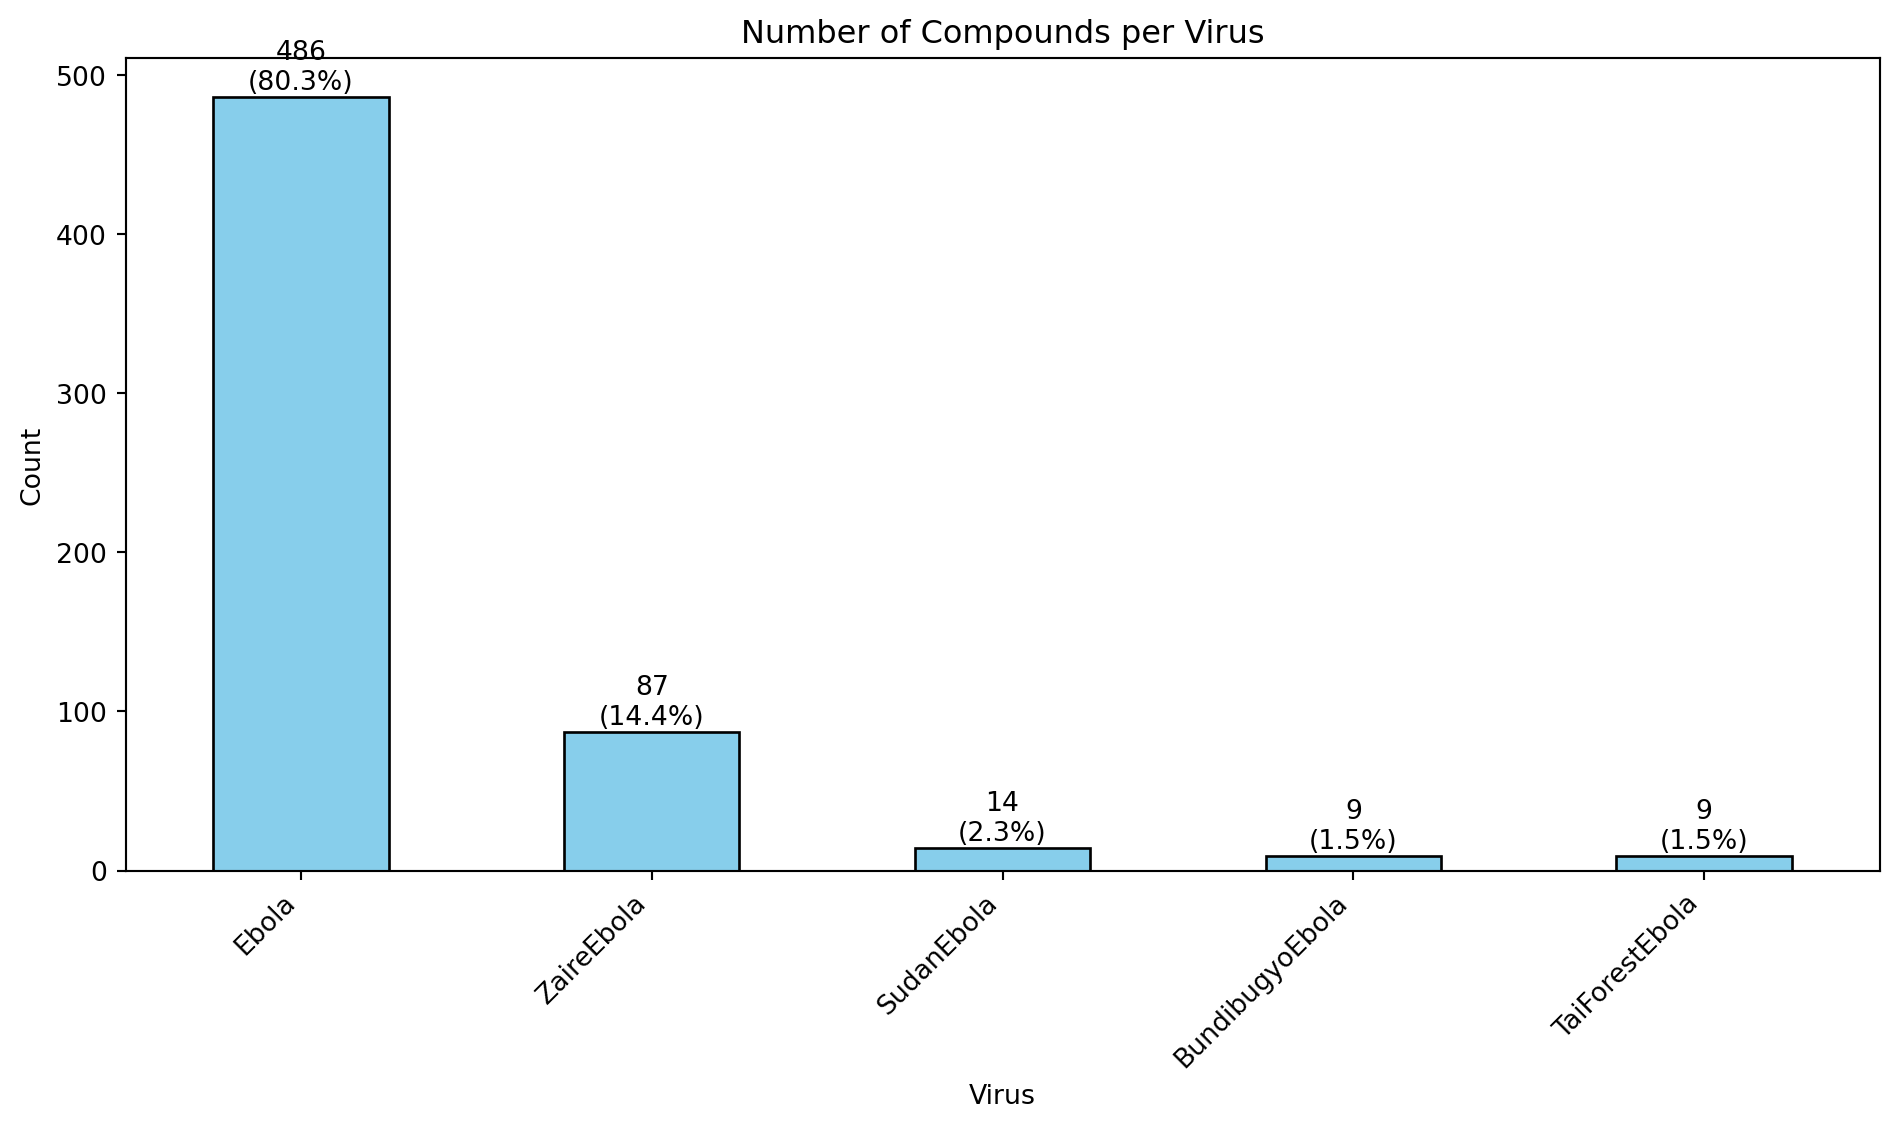

In [363]:
# Get counts and percentages
counts = EbolaAllSpeciesData_chEMBL_uM_noDuplicates['StrainClassifier'].value_counts()
percentages = counts / counts.sum() * 100

# Create bar plot
plt.figure(figsize=(10, 6))
bars = counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Number of Compounds per Virus')
plt.xlabel('Virus')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Annotate each bar with count and %
for i, (count, pct) in enumerate(zip(counts, percentages)):
    plt.text(
        i, count + 1,                 # position (x, y)
        f'{count}\n({pct:.1f}%)',     # label: count + percentage
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()

In [364]:
EbolaAllSpeciesData_chEMBL_uM_noDuplicates.to_csv(os.path.join(modelBuildingDataDir, "EbolaAllSpeciesData_chEMBL_uM_noDuplicates_MLready.csv"), index=False)

### pPotency value distribution across each Virus

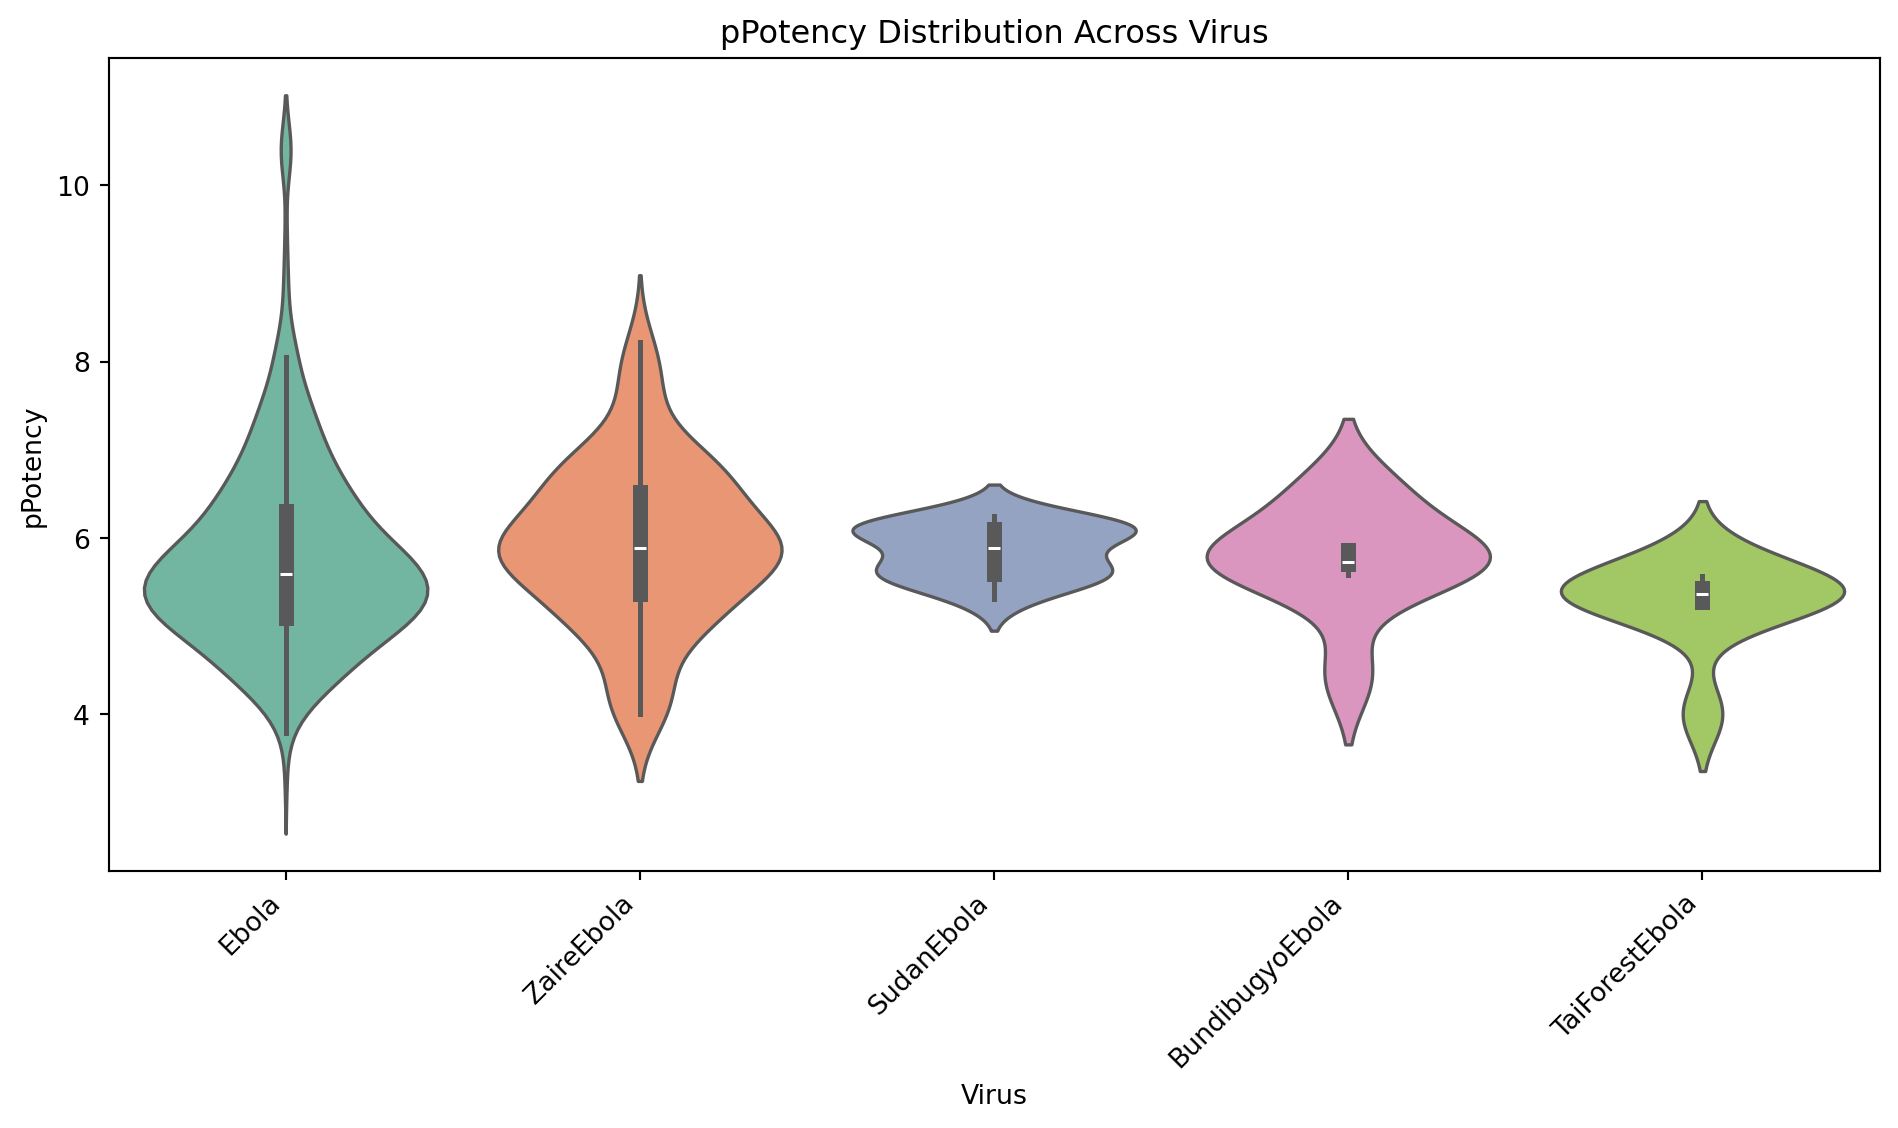

In [365]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=EbolaAllSpeciesData_chEMBL_uM_noDuplicates,
    x='StrainClassifier',
    y='pPotency',
    palette='Set2',
    inner='box'
)

plt.xticks(rotation=45, ha='right')
plt.title('pPotency Distribution Across Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

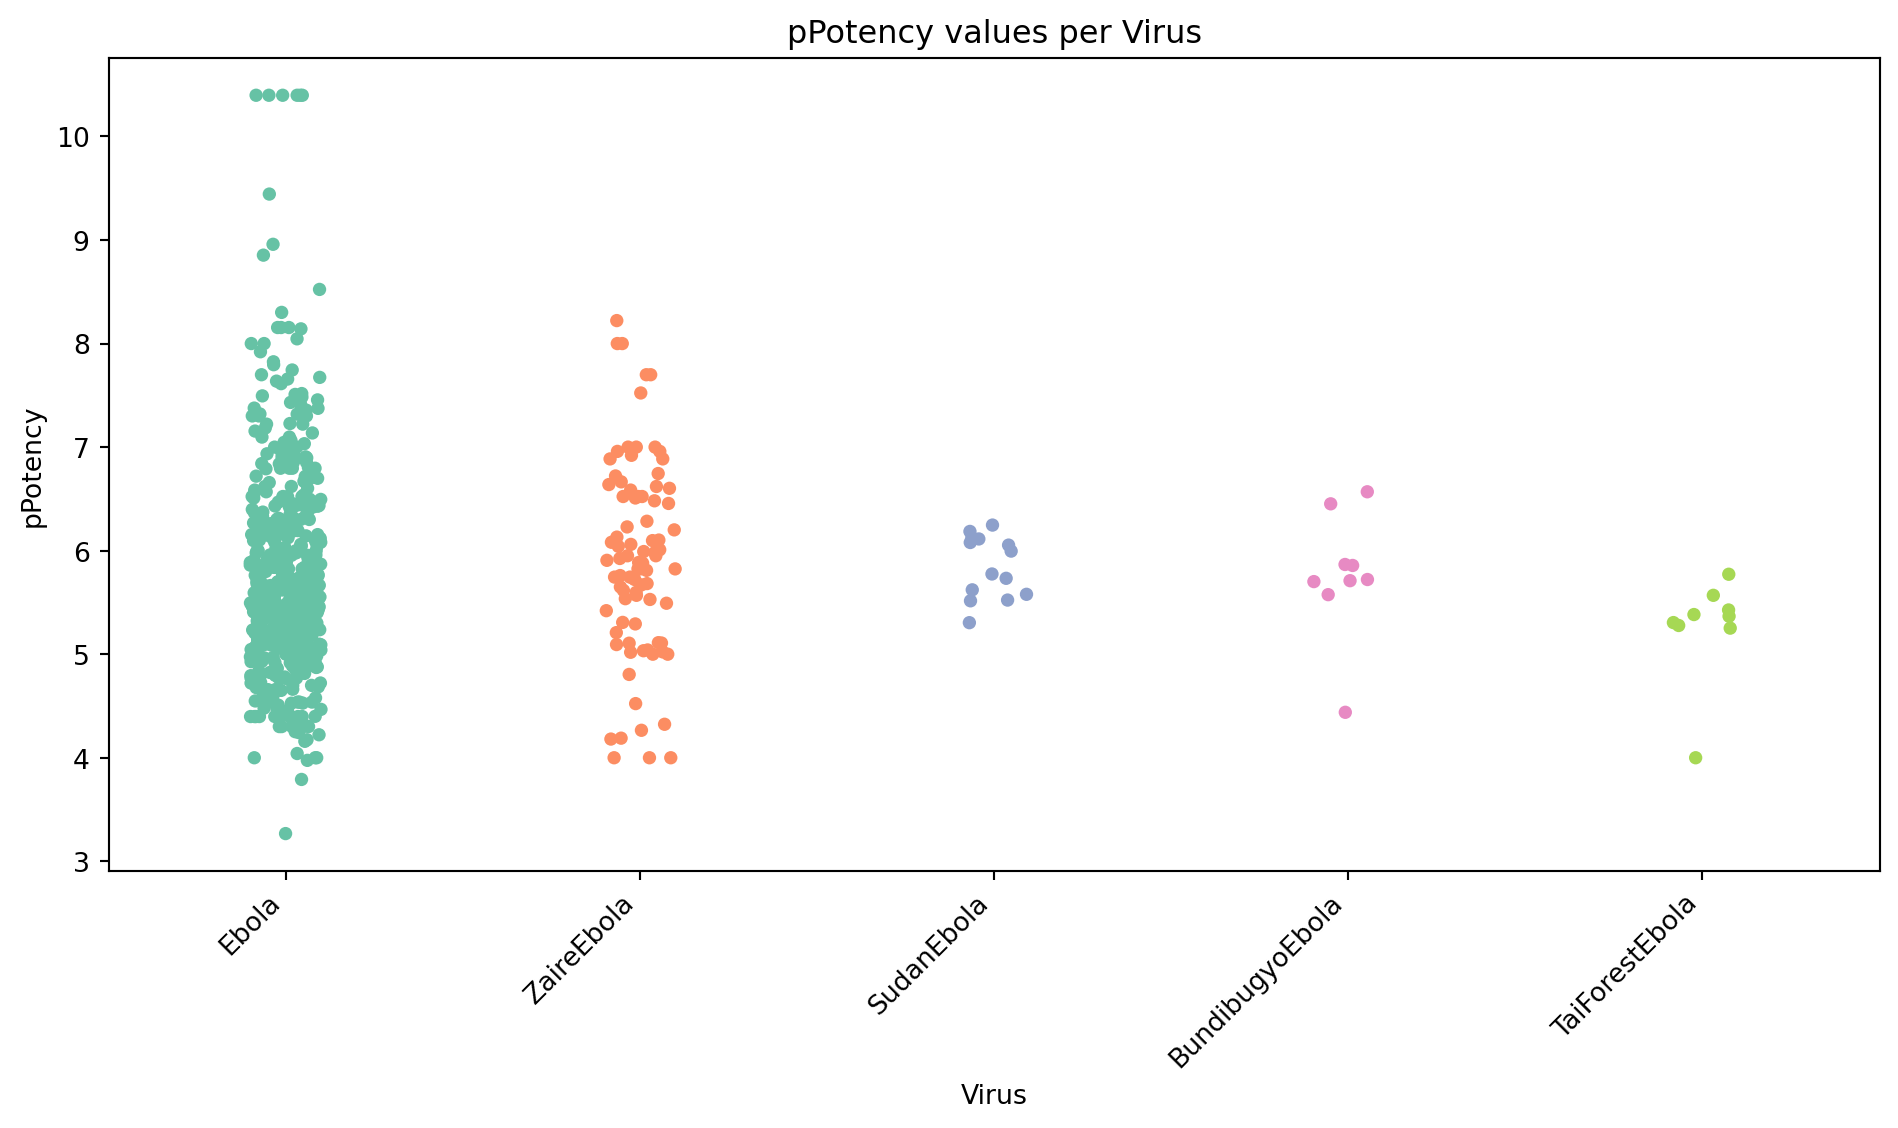

In [366]:
plt.figure(figsize=(10, 6))
sns.stripplot(
    data=EbolaAllSpeciesData_chEMBL_uM_noDuplicates,
    x='StrainClassifier',
    y='pPotency',
    jitter=True,          # spreads the dots to avoid overlap
    palette='Set2',
    alpha=1
)
plt.xticks(rotation=45, ha='right')
plt.title('pPotency values per Virus')
plt.xlabel('Virus')
plt.ylabel('pPotency')
plt.tight_layout()
plt.show()

### Clip first 1000 rows from the data set for fast testing

### Train ML Model

In [367]:
# df = EbolaAllSpeciesData_chEMBL_uM_noDuplicates
Y = EbolaAllSpeciesData_chEMBL_uM_noDuplicates.pPotency
smiles = EbolaAllSpeciesData_chEMBL_uM_noDuplicates.Smiles

In [368]:
print(len(smiles))

605


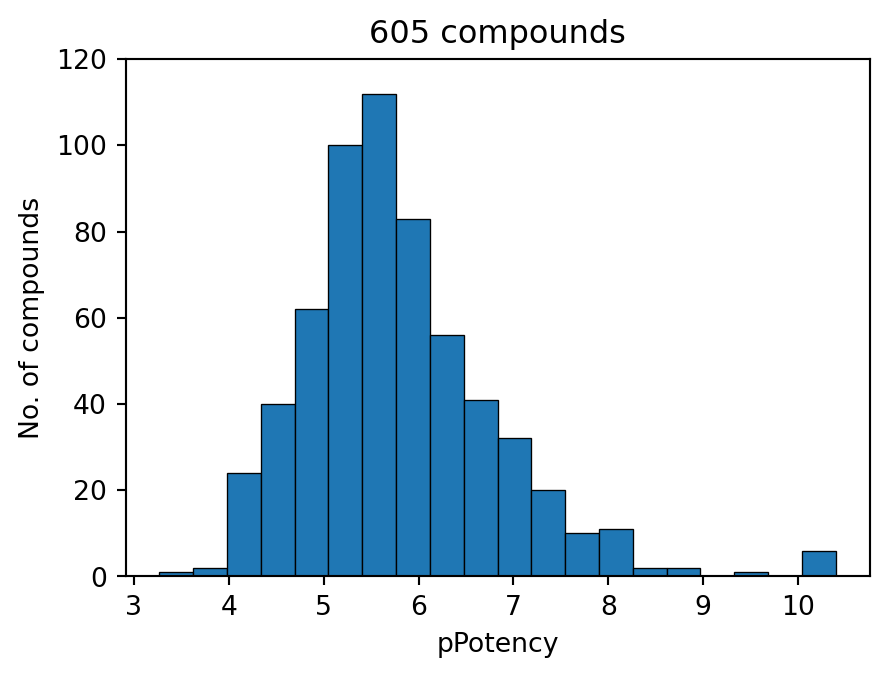

In [369]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [370]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [371]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [372]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)


After cleaning NaN values, reset the indices

In [373]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 605 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


### ML predictions with Train + Test results

In [374]:
%%time
import numpy as np
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from joblib import Parallel, delayed
from copy import deepcopy

def process_fold(fold_id, train_index, test_index, smiles, Y, mcw, param_grid, num_partitions):
    """Process a single CV fold"""
    print(f"Partition {fold_id}/{num_partitions}")
    
    # Split data
    smi_train = smiles.iloc[train_index]
    smi_test = smiles.iloc[test_index]
    y_train = Y[train_index]
    y_test = Y[test_index]
    
    # Compute MACAW embeddings (clone to avoid conflicts)
    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)
    
    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)
    
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
    
    best_params = grid.best_params_
    
    # Predict on both train and test
    y_cv_pred_train = grid.predict(X_train)
    y_cv_pred_test = grid.predict(X_test)
    
    # Calculate fold metrics
    train_mae = mean_absolute_error(y_train, y_cv_pred_train)
    test_mae = mean_absolute_error(y_test, y_cv_pred_test)
    print(f"  Fold {fold_id} - Train MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    
    # Return all predictions and parameters
    return {
        'train_pred': y_cv_pred_train,
        'train_obs': y_train,
        'test_pred': y_cv_pred_test,
        'test_obs': y_test,
        'best_params': best_params
    }

# Parallel execution
results = Parallel(n_jobs=4, verbose=10)(
    delayed(process_fold)(
        fold_id=i+1,
        train_index=train_idx,
        test_index=test_idx,
        smiles=smiles,
        Y=Y,
        mcw=mcw,
        param_grid=param_grid,
        num_partitions=num_of_partitions
    )
    for i, (train_idx, test_idx) in enumerate(kf.split(smiles))
)

# Combine results
Y_cv_pred_train = []
Y_obs_train = []
Y_cv_pred_test = []
Y_obs_test = []
best_params_per_fold = []

for fold_result in results:
    Y_cv_pred_train.extend(fold_result['train_pred'])
    Y_obs_train.extend(fold_result['train_obs'])
    Y_cv_pred_test.extend(fold_result['test_pred'])
    Y_obs_test.extend(fold_result['test_obs'])
    best_params_per_fold.append(fold_result['best_params'])

# Convert to numpy arrays
Y_cv_pred_train = np.array(Y_cv_pred_train)
Y_obs_train = np.array(Y_obs_train)
Y_cv_pred_test = np.array(Y_cv_pred_test)
Y_obs_test = np.array(Y_obs_test)

# ===== OVERALL METRICS =====
print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)

# Train metrics
train_mae = mean_absolute_error(Y_obs_train, Y_cv_pred_train)
train_rmse = np.sqrt(mean_squared_error(Y_obs_train, Y_cv_pred_train))
train_r2 = r2_score(Y_obs_train, Y_cv_pred_train)

print(f"Train Set:")
print(f"  MAE:  {train_mae:.2f}")
print(f"  RMSE: {train_rmse:.2f}")
print(f"  R²:   {train_r2:.2f}")

# Test metrics
test_mae = mean_absolute_error(Y_obs_test, Y_cv_pred_test)
test_rmse = np.sqrt(mean_squared_error(Y_obs_test, Y_cv_pred_test))
test_r2 = r2_score(Y_obs_test, Y_cv_pred_test)

print(f"Test Set:")
print(f"  MAE:  {test_mae:.2f}")
print(f"  RMSE: {test_rmse:.2f}")
print(f"  R²:   {test_r2:.2f}")

print(f"\nBest params (sample): {best_params_per_fold[:3]}")


----------------------------------------
Cross Validation Metrics
----------------------------------------
Train Set:
  MAE:  0.35
  RMSE: 0.48
  R²:   0.78
Test Set:
  MAE:  0.46
  RMSE: 0.60
  R²:   0.66

Best params (sample): [{'C': 7, 'epsilon': 0.3, 'kernel': 'rbf'}, {'C': 5, 'epsilon': 0.3, 'kernel': 'rbf'}, {'C': 5, 'epsilon': 0.3, 'kernel': 'rbf'}]
CPU times: user 222 ms, sys: 75.8 ms, total: 298 ms
Wall time: 11.3 s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/EbolavirusAllStrain/EbolavirusAllStrain_noDuplicates_CV_TrTs.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/EbolavirusAllStrain/EbolavirusAllStrain_noDuplicates_CV_TrTs.png


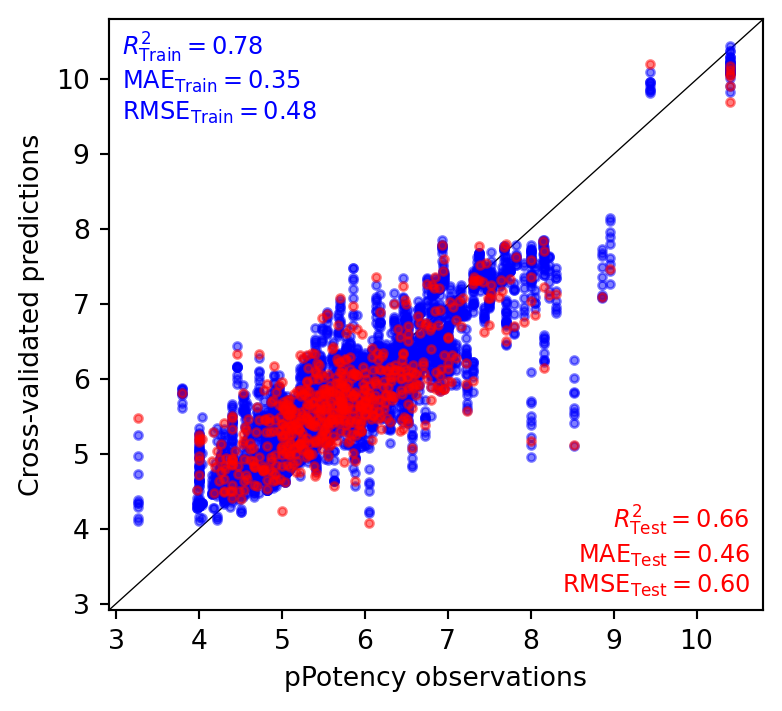

In [375]:
parity_plot(x=Y_obs_train, 
            y=Y_cv_pred_train, 
            x_test=Y_obs_test, 
            y_test=Y_cv_pred_test, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=resultsDir + 'EbolaAllSpecies/EbolaAllSpecies_noDuplicates_CV_TrTs.svg',
            save_formats=['svg', 'png'])

Generate a model trained on the whole data set, to be used for prediction tasks

In [376]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)
mcw.fit(smiles, Y)

In [377]:
X_all = mcw.transform(smiles)
X_all.shape

(605, 15)

Training samples: 484
Test samples: 121
Feature dimensions: 15

Running GridSearchCV with 4 parallel jobs...

------------------------------------------------------------
Best Hyperparameters:
------------------------------------------------------------
  C: 5
  epsilon: 0.1
  kernel: rbf

Best CV MAE (on training folds): 0.43

------------------------------------------------------------
PERFORMANCE COMPARISON:
------------------------------------------------------------
Metric     Training        Test            Difference     
------------------------------------------------------------
R²         0.79            0.69            0.10           
MAE        0.30            0.49            0.19           
RMSE       0.46            0.65            0.19           
------------------------------------------------------------


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/EbolavirusAllStrain/EbolavirusAllStrain_noDuplicates_fullData_TrTs.svg
Saved: /mnt/

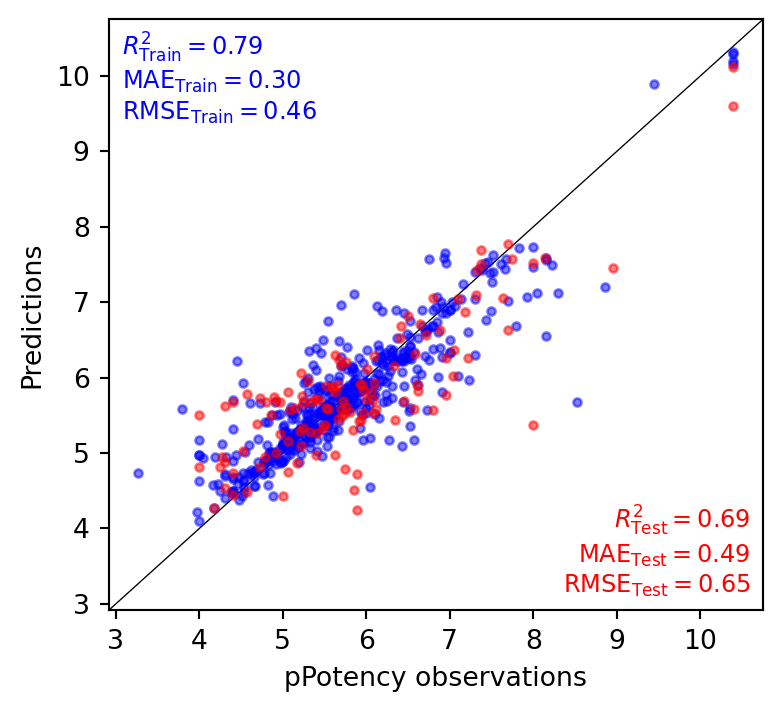

CPU times: user 1.37 s, sys: 35.9 ms, total: 1.4 s
Wall time: 2.07 s


In [378]:
%%time
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# ---------------------------
# 1. TRAIN-TEST SPLIT
# ---------------------------
# Since you're working with only one virus group, use regular train_test_split
X_train_smi, X_test_smi, Y_train, Y_test = train_test_split(
    smiles, Y, 
    test_size=0.2, 
    random_state=42,
    shuffle=True
)

print(f"Training samples: {len(X_train_smi)}")
print(f"Test samples: {len(X_test_smi)}")

# ---------------------------
# 2. FIT MACAW ON TRAINING DATA ONLY
# ---------------------------
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)
mcw.fit(X_train_smi, Y_train)

# Transform both train and test
X_train = mcw.transform(X_train_smi)
X_test = mcw.transform(X_test_smi)

print(f"Feature dimensions: {X_train.shape[1]}")

# ---------------------------
# 3. GRID SEARCH ON TRAINING DATA ONLY
# ---------------------------
n_jobs = 4

regr_pred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid,
    cv=5,
    refit=True,
    n_jobs=n_jobs,
    verbose=0,
    scoring='neg_mean_absolute_error',
    return_train_score=True,
    pre_dispatch='2*n_jobs'
)

print(f"\nRunning GridSearchCV with {n_jobs} parallel jobs...")
regr_pred.fit(X_train, Y_train)

# ---------------------------
# 4. DISPLAY BEST HYPERPARAMETERS
# ---------------------------
print("\n" + "-"*60)
print("Best Hyperparameters:")
print("-"*60)
for param, value in regr_pred.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest CV MAE (on training folds): {-regr_pred.best_score_:.2f}")

# ---------------------------
# 5. PREDICTIONS AND METRICS
# ---------------------------
# Training predictions (in-sample)
y_train_pred = regr_pred.predict(X_train)

# Test predictions (held-out)
y_test_pred = regr_pred.predict(X_test)

# Calculate metrics for TRAIN
train_r2 = r2_score(Y_train, y_train_pred)
train_mae = mean_absolute_error(Y_train, y_train_pred)
train_rmse = np.sqrt(np.mean((Y_train - y_train_pred)**2))

# Calculate metrics for TEST
test_r2 = r2_score(Y_test, y_test_pred)
test_mae = mean_absolute_error(Y_test, y_test_pred)
test_rmse = np.sqrt(np.mean((Y_test - y_test_pred)**2))

# ---------------------------
# 6. DISPLAY RESULTS
# ---------------------------
print("\n" + "-"*60)
print("PERFORMANCE COMPARISON:")
print("-"*60)
print(f"{'Metric':<10} {'Training':<15} {'Test':<15} {'Difference':<15}")
print("-"*60)
print(f"{'R²':<10} {train_r2:<15.2f} {test_r2:<15.2f} {abs(train_r2-test_r2):<15.2f}")
print(f"{'MAE':<10} {train_mae:<15.2f} {test_mae:<15.2f} {abs(train_mae-test_mae):<15.2f}")
print(f"{'RMSE':<10} {train_rmse:<15.2f} {test_rmse:<15.2f} {abs(train_rmse-test_rmse):<15.2f}")
print("-"*60)

# Check for overfitting
overfit_gap = train_r2 - test_r2
if overfit_gap > 0.1:
    print("\n  WARNING: Possible overfitting detected (R² gap > 0.1)")
elif test_r2 >= 0.7:
    print("\n Good generalization performance!")

print("\n" + "="*60)

# ---------------------------
# 7. GENERATE PARITY PLOT
# ---------------------------
parity_plot(
    x=Y_train,                      # observed train
    y=y_train_pred,                 # predicted train (in-sample)
    x_test=Y_test,                  # observed test
    y_test=y_test_pred,             # predicted test (held-out)
    xlabel="pPotency observations",
    ylabel="Predictions",
    savetitle=resultsDir + 'EbolaAllSpecies/EbolaAllSpecies_noDuplicates_fullData_TrTs.svg',
    save_formats=['svg', 'png']
)

### Compare performance of different ML model

- SVR
- Random Forest
- XGBoost
- LightGBM
- CatBoost
- Neural Network

Import all necessary libraries

## 2.1 Discovery of new hits specific to all viruses (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [379]:
EnamineAntiviralsData = pd.read_csv(dataDir + "Enamine/Enamine_Antiviral_Library_plated_3200cmpds_20251019.csv",
                                    sep=",", comment=None, skipinitialspace=True, engine="python", encoding="utf-8",          
                                    skiprows=1, skip_blank_lines=True)
print(f"Original Enamine data shape: {EnamineAntiviralsData.shape}")

smiles_train = EbolaAllSpeciesData_chEMBL_uM_noDuplicates.Smiles

# Function to canonicalize SMILES using RDKit
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            return Chem.MolToSmiles(mol, canonical=True)
        else:
            return None
    except:
        return None

# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to Enamine data
EnamineAntiviralsData['Canonical_SMILES'] = EnamineAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~EnamineAntiviralsData['Canonical_SMILES'].isin(canonical_train)
EnamineAntiviralsData_filtered = EnamineAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
EnamineAntiviralsData = EnamineAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered Enamine data shape for validation: {EnamineAntiviralsData.shape}")
print(f"Removed {EnamineAntiviralsData.shape[0] - EnamineAntiviralsData_filtered.shape[0]} duplicate compounds from Enamine data set")

# Now use the filtered data
smi_lib = EnamineAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
EnamineAntiviralsData.head()

Original Enamine data shape: (3200, 11)
Number of unique SMILES in training set: 540
Filtered Enamine data shape for validation: (3200, 11)
Removed 0 duplicate compounds from Enamine data set
Total compounds to screen: 3200


,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL
0,COCC(C)NC(=O)NC1=NN=C(S1)C2CC2,Z410227912,256.326,256.326,1.231,-2.190,2,4,76.140,5,https://real.enamine.net/public-enum-files/Z41...
1,CN1C(=O)C=CN(CC(=O)NCC2CC2)C1=O,Z383167688,237.256,237.256,-0.042,-0.692,1,3,69.720,5,https://real.enamine.net/public-enum-files/Z38...
2,CCN(CC)CCNC(=O)C1=CC=CN=C1N2CCOCC2,Z235579208,306.404,306.404,1.583,-2.082,1,5,57.700,7,NaN
3,CCC(CNC(=O)CC=1C(C)=NOC1C)N2CCCC2,Z403694008,279.379,279.379,1.156,-0.660,1,3,58.370,7,https://real.enamine.net/public-enum-files/Z40...
4,CCC(C)(CNC(=O)CN1C=CC=CC1=O)N2CCOCC2,Z384461492,307.389,307.389,1.084,-1.180,1,4,61.880,7,https://real.enamine.net/public-enum-files/Z38...


Generate predictions for the H1 receptor:

In [380]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [381]:
EnamineAntiviralsData_predicted = EnamineAntiviralsData.copy()
EnamineAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
EnamineAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-EnamineAntiviralsData_predicted['pPotency_prediction'])

EnamineAntiviralsData_predicted = EnamineAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
EnamineAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "EbolaAllSpecies/EbolaAllSpecies_noDuplicates_EnamineDatasets_predicted_all.csv"), index=False)
EnamineAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "EbolaAllSpecies/EbolaAllSpecies_noDuplicates_EnamineDatasets_predicted_all_SMILES.csv"), index=False)
EnamineAntiviralsData_predicted

,SMILES,pPotency_prediction,pPotency(M)_prediction
0,COCC(C)NC(=O)NC1=NN=C(S1)C2CC2,4.560,2.756e-05
1,CN1C(=O)C=CN(CC(=O)NCC2CC2)C1=O,5.097,7.999e-06
2,CCN(CC)CCNC(=O)C1=CC=CN=C1N2CCOCC2,4.986,1.033e-05
3,CCC(CNC(=O)CC=1C(C)=NOC1C)N2CCCC2,5.241,5.746e-06
4,CCC(C)(CNC(=O)CN1C=CC=CC1=O)N2CCOCC2,5.223,5.979e-06
...,...,...,...
3195,CCOC=1N=CC=CC1NC(=O)NC2CCN3CCCCC23,5.522,3.008e-06
3196,CC1=NN(CC(O)C=2C=CC=CC2)C(=O)C(C#N)=C1C,5.079,8.338e-06
3197,CCC1=NN=NN1CC(=O)NC2CCN(CC2)C(C)=O,5.040,9.123e-06
3198,CC=1C=C2N=CN(CC(O)CN3CCS(=O)CC3)C2=CC1C,5.430,3.714e-06


Let us represent the predictions of both models:

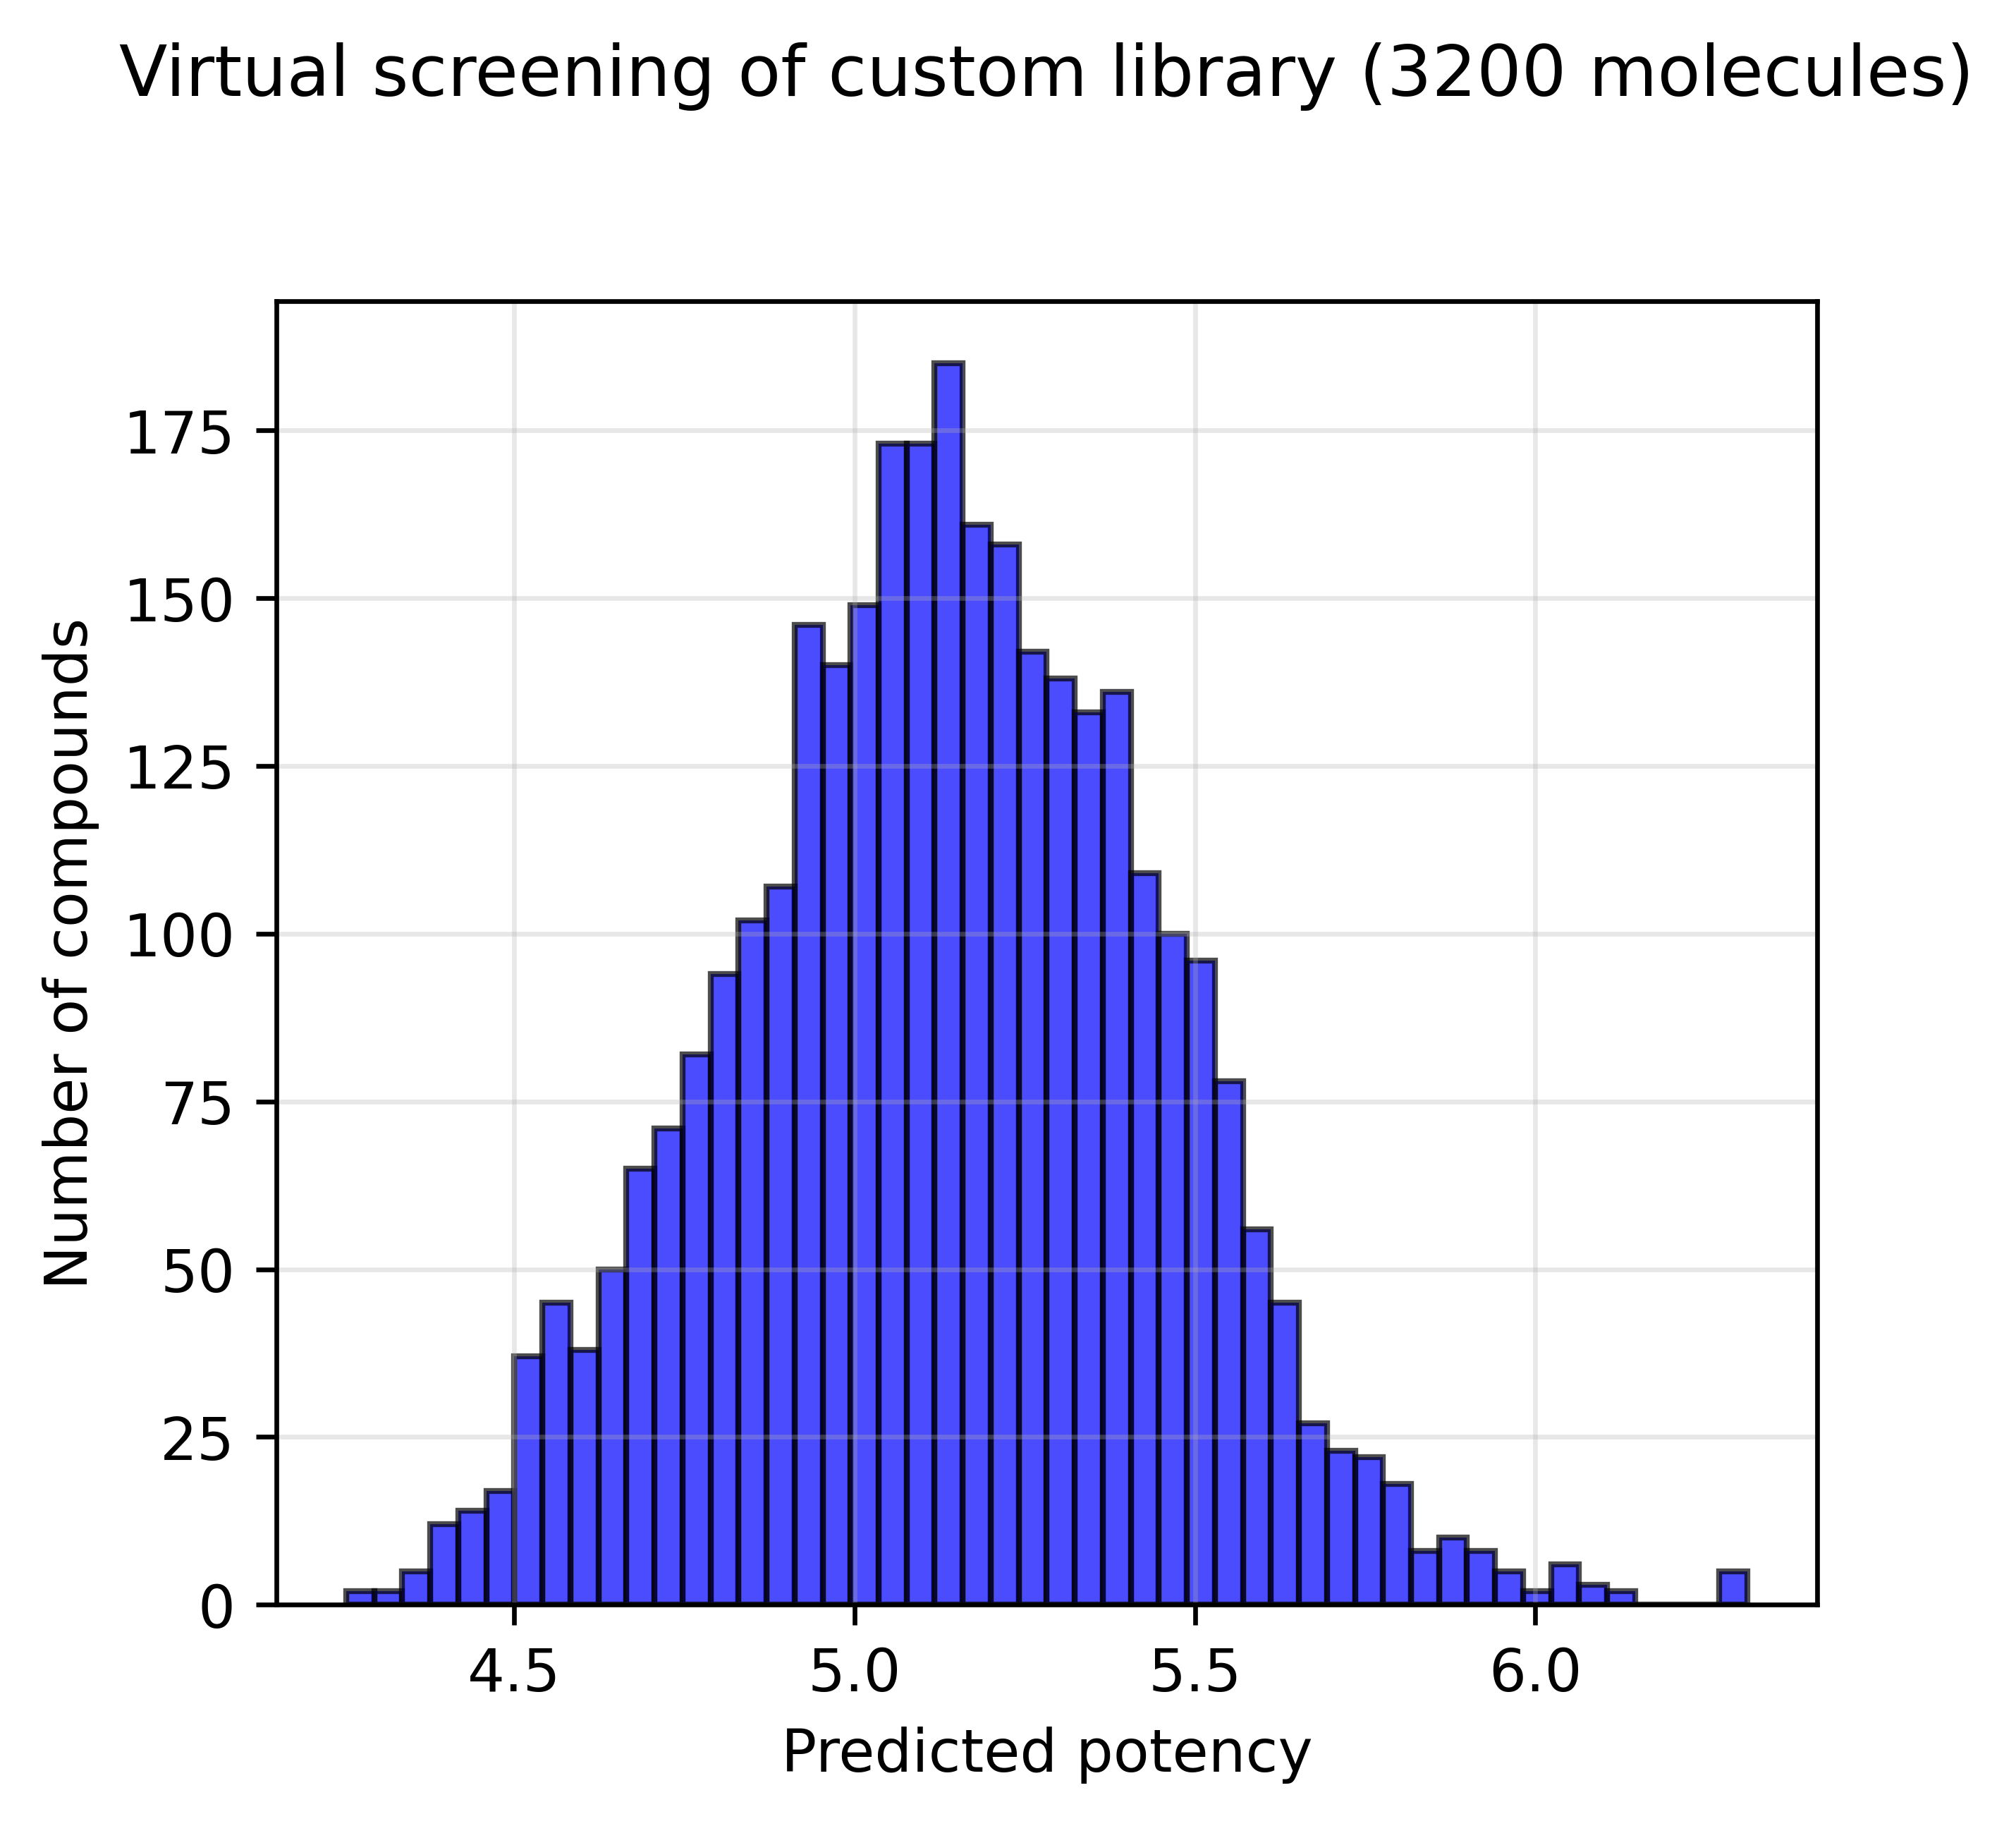

In [382]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'EbolaAllSpecies/EbolaAllSpecies_noDuplicates_validation.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'EbolaAllSpecies/EbolaAllSpecies_noDuplicates_validation.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [383]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 0 compounds
Medium priority (6 ≤ pPotency < 7.0): 18 compounds
Low priority (5 ≤ pPotency < 6): 2130 compounds


In [384]:
EnamineAntiviralsData_final = EnamineAntiviralsData.iloc[idx].copy()
EnamineAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntiviralsData_final

,SMILES,Catalog ID,MW,MW (desalted),ClogP,logS,HBD,HBA,TPSA,RotBonds,AnalogsFromREAL,pPotency_prediction


### Top 20 compounds with higher PpPotency

In [385]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 5.98
Highest predicted pPotency: 6.31
Range of top 20: 5.98 - 6.31


In [386]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
EnamineAntiviralsData_top20 = EnamineAntiviralsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
EnamineAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
EnamineAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
EnamineAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
EnamineAntiviralsData_top20 = EnamineAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
EnamineAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    5.978
  IC50:        1.052e-06 M  (1051.98 nM)

Best Values (1st ranked compound):
  pPotency:    6.311
  IC50:        4.885e-07 M  (488.46 nM)
Range for Top 20 Compounds:
pPotency Range:  5.978 - 6.311

IC50 Range (M):  1.052e-06 - 4.885e-07


,Rank,SMILES,pPotency_prediction,IC50 (M)
1656,1,CC=1C=NC=C(C1)NC(=O)NC2CCN(CC2)C3CCN(C)CC3,6.311,4.885e-07
699,2,CC=1C=CC(=CN1)NC(=O)NC2CCN(CC2)C3CCN(C)CC3,6.311,4.886e-07
1486,3,CC=1C=CC=C(N1)NC(=O)NC2CCN(CC2)C3CCN(C)CC3,6.306,4.946e-07
2691,4,CC1=CC(=NC(C)=C1)NC(=O)NC2CCN(CC2)C3CCN(C)CC3,6.292,5.102e-07
2595,5,CCN1CCOC(CNCC(O)CN2C=NC=3C=C(C)C(C)=CC32)C1,6.272,5.348e-07
1956,6,CC=1C=C2N=CN(CC(O)CN3CCN(CC(C)O)CC3)C2=CC1C,6.114,7.688e-07
1470,7,CC=1C=C(C)N=C(C1)NC(=O)NCC(C)CN2CCN(C)CC2,6.110,7.764e-07
1271,8,CC=1C=NC=CC1CCNC(=O)NC(C)C(=O)N2CCCCC2C,6.076,8.399e-07
3010,9,CC(C)CC(=O)N1CCC(CC1)NC(=O)NC=2C=CC(=NC2)N(C)C,6.068,8.545e-07
2282,10,CN1CCC(CC1)N2CCC(CC2)NC(=O)NC3=CC=NC=C3F,6.068,8.554e-07


In [387]:
EnamineAntiviralsData_top20.to_csv(os.path.join(resultsDir + "EbolaAllSpecies/EbolaAllSpecies_noDuplicates_EnamineAntiviralsData_top20.csv"), index=False)
EnamineAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "EbolaAllSpecies/EbolaAllSpecies_noDuplicates_EnamineAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/EbolavirusAllStrain/EbolavirusAllStrain_noDuplicates_enamine_predictedCompounds.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/EbolavirusAllStrain/EbolavirusAllStrain_noDuplicates_enamine_predictedCompounds.svg


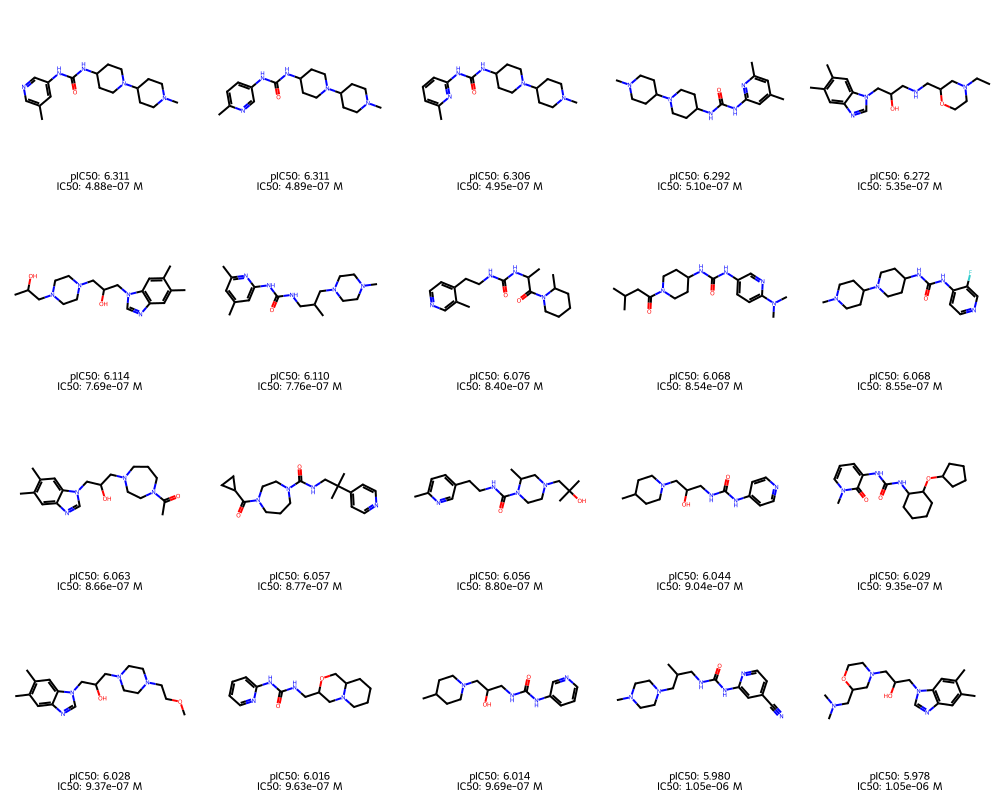

In [388]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = resultsDir + 'EbolaAllSpecies/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in EnamineAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'EbolaAllSpecies_noDuplicates_enamine_predictedCompounds.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'EbolaAllSpecies_noDuplicates_enamine_predictedCompounds.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

## 2.2 Discovery of new hits specific to all viruses (data source Life chemicals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [389]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "LifeChemicals/LC_Merged_Antiviral_Screening_Superset.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

LCAntiviralsData_superset = pd.DataFrame(records)
print(f"Original LifeChemicals data shape: {LCAntiviralsData_superset.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to LifeChemicals data (reusing canonical_train from code-1)
LCAntiviralsData_superset['Canonical_SMILES'] = LCAntiviralsData_superset['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~LCAntiviralsData_superset['Canonical_SMILES'].isin(canonical_train)
LCAntiviralsData_superset_filtered = LCAntiviralsData_superset[mask].copy()

# Remove the helper column if you don't need it
LCAntiviralsData_superset = LCAntiviralsData_superset_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered LifeChemicals data shape for validation: {LCAntiviralsData_superset.shape}")
print(f"Removed {LCAntiviralsData_superset_filtered.shape[0] - LCAntiviralsData_superset.shape[0]} duplicate compounds from LifeChemicals data set")

# Now use the filtered data
smi_lib = LCAntiviralsData_superset.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
LCAntiviralsData_superset.head()

Original LifeChemicals data shape: (45573, 17)
Number of unique SMILES in training set: 540
Filtered LifeChemicals data shape for validation: (45573, 17)
Removed 0 duplicate compounds from LifeChemicals data set
Total compounds to screen: 45573


,IDNUMBER,Chemical_Name,CAS,PriceCoeff,MW,Description,FSP3,clogP,TPSA,Acceptor,Donor,RotBonds,HAC,Collection,Library,PPDS,SMILES
0,F6544-0534,"11-(oxan-4-yl)-7,11-diazatricyclo[7.3.1.0²,⁷]t...",2034607-75-3,1.500,274.360,solid,0.690,-0.120,32.780,2,1,1,20.000,Advanced,Anti-Hepatitis_A_B_ Screening_Library,,Cl.O=c1cccc2n1CC1CC2CN(C2CCOCC2)C1
1,F6559-5304,6-[4-(trifluoromethyl)pyrimidin-2-yl]-6-azaspi...,2034225-11-9,1.500,301.260,solid,0.620,2.030,66.320,4,1,2,21.000,Advanced,2019-nCoV_Main_Protease_Targeted_Library,+,O=C(O)C1CN(c2nccc(C(F)(F)F)n2)CC12CCC2
2,F6610-6619,"1-methyl-4-[(pyridin-4-yl)methyl]-1,4-diazepane",2320860-02-2,1.000,205.300,oil,0.580,0.890,19.370,3,3,2,15.000,General,Anti-HIV_Focused_Library,,CN1CCCN(Cc2ccncc2)CC1
3,F6559-5274,"6-(4,6-dimethylpyrimidin-2-yl)-6-azaspiro[3.4]...",2034225-08-4,1.500,261.320,oil,0.640,2.090,66.320,4,1,2,19.000,Advanced,Antiviral_Screening_Compound_Library_2D_Simila...,,Cc1cc(C)nc(N2CC(C(=O)O)C3(CCC3)C2)n1
4,F1912-1536,N-cyclopropyl-N-(piperidin-4-yl)pyrimidin-4-amine,1781768-10-2,1.500,218.290,solid,0.670,0.790,41.050,2,2,3,16.000,Advanced,Antiviral_Screening_Compound_Library_2D_Simila...,,c1cc(N(C2CCNCC2)C2CC2)ncn1


Generate predictions for the H1 receptor:

In [390]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [391]:
LCAntiviralsData_predicted = LCAntiviralsData_superset.copy()
LCAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
LCAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-LCAntiviralsData_predicted['pPotency_prediction'])

LCAntiviralsData_predicted = LCAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
LCAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "EbolaAllSpecies/EbolaAllSpecies_noDuplicates_LCDatasets_predicted_all.csv"), index=False)
LCAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "EbolaAllSpecies/EbolaAllSpecies_noDuplicates_LCDatasets_predicted_all_SMILES.csv"), index=False)
LCAntiviralsData_predicted

,SMILES,pPotency_prediction,pPotency(M)_prediction
0,Cl.O=c1cccc2n1CC1CC2CN(C2CCOCC2)C1,5.363,4.338e-06
1,O=C(O)C1CN(c2nccc(C(F)(F)F)n2)CC12CCC2,5.129,7.436e-06
2,CN1CCCN(Cc2ccncc2)CC1,4.893,1.280e-05
3,Cc1cc(C)nc(N2CC(C(=O)O)C3(CCC3)C2)n1,4.770,1.697e-05
4,c1cc(N(C2CCNCC2)C2CC2)ncn1,5.025,9.451e-06
...,...,...,...
45568,CCN1C=C/C(=C\C=C\c2cc[n+](CC)c3ccccc23)c2ccccc...,5.394,4.041e-06
45569,CCCN1/C(=C/C=C/c2sc3ccccc3[n+]2CCC)Sc2ccccc21....,5.119,7.609e-06
45570,COC(=O)c1ccccc1-c1c2ccc(=N)cc-2oc2cc(N)ccc12.Cl,5.022,9.499e-06
45571,CCN1/C(=C/C=C2\CCC(/C=C/c3sc4ccc(Cl)cc4[n+]3CC...,6.044,9.027e-07


Let us represent the predictions of both models:

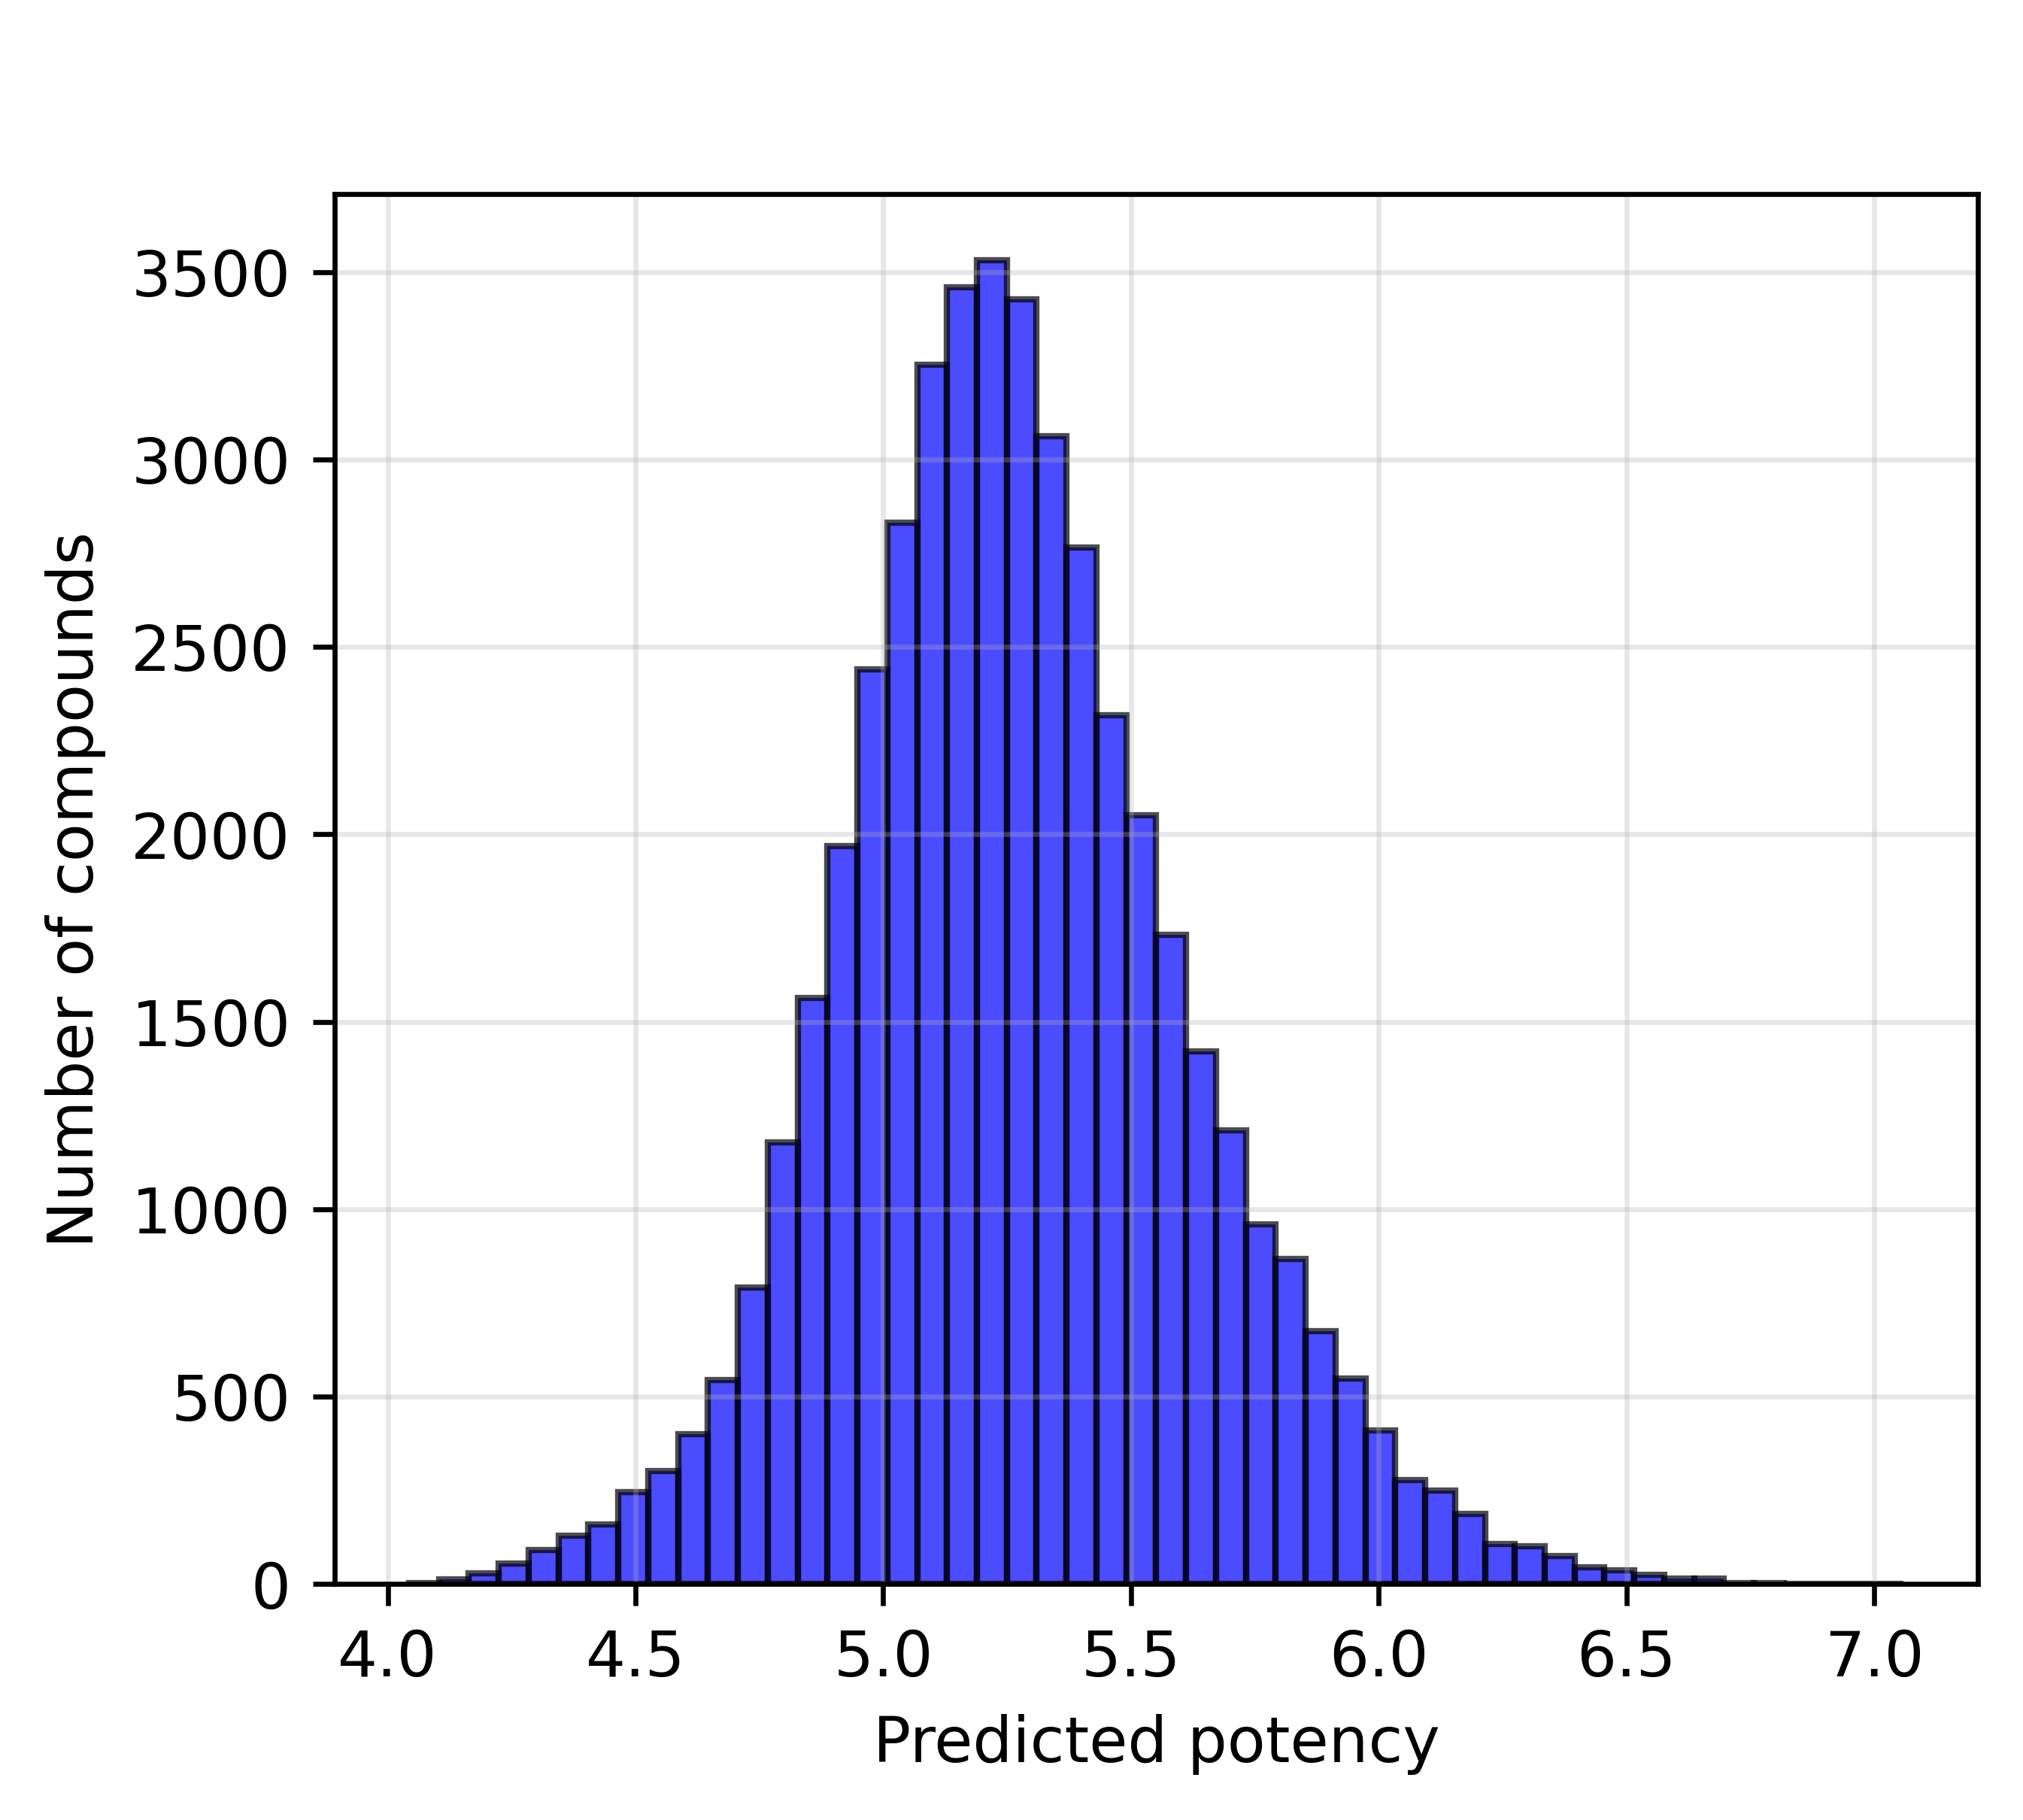

In [392]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'EbolaAllSpecies/EbolaAllSpecies_noDuplicates_validation_LCDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'EbolaAllSpecies/EbolaAllSpecies_noDuplicates_validation_LCDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [393]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 1 compounds
Medium priority (6 ≤ pPotency < 7.0): 1352 compounds
Low priority (5 ≤ pPotency < 6): 34650 compounds


In [394]:
LCAntiviralsData_superset_final = LCAntiviralsData_superset.iloc[idx].copy()
LCAntiviralsData_superset_final['pPotency_prediction'] = Y1_lib_pred[idx]
LCAntiviralsData_superset_final = LCAntiviralsData_superset_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
LCAntiviralsData_superset_final

,SMILES,pPotency_prediction,clogP
43899,Cc1ccc(S(=O)(=O)NCCCN(CCN(CCCNS(=O)(=O)c2ccc(C...,7.058,8.110


### Top 20 compounds with higher PpPotency

In [395]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 6.64
Highest predicted pPotency: 7.06
Range of top 20: 6.64 - 7.06


In [396]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
LCAntiviralsData_top20 = LCAntiviralsData_superset.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
LCAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
LCAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
LCAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
LCAntiviralsData_top20 = LCAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
LCAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    6.645
  IC50:        2.266e-07 M  (226.62 nM)

Best Values (1st ranked compound):
  pPotency:    7.058
  IC50:        8.744e-08 M  (87.44 nM)
Range for Top 20 Compounds:
pPotency Range:  6.645 - 7.058

IC50 Range (M):  2.266e-07 - 8.744e-08


,Rank,SMILES,pPotency_prediction,IC50 (M)
43899,1,Cc1ccc(S(=O)(=O)NCCCN(CCN(CCCNS(=O)(=O)c2ccc(C...,7.058,8.744e-08
25908,2,COc1cc2c(=O)n(Cc3ccc(C(=O)N4CCCC4)cc3)c(=O)n(C...,6.835,1.462e-07
44367,3,CCOC(=O)c1c(C)n(-c2ccc(C)cc2)c2ccc(OCC(O)CN3CC...,6.777,1.671e-07
39937,4,CCOc1ccc(NC(=O)c2ccc(N3CC4CC(C3)c3cccc(=O)n3C4...,6.775,1.680e-07
43745,5,COc1ccc(N2CCN(S(=O)(=O)c3cc(C(=O)Nc4ccc(Oc5ccc...,6.734,1.845e-07
38431,6,Cc1cc(C)cc(NC(=O)C(=O)NCCC2CCCCN2S(=O)(=O)c2c(...,6.714,1.934e-07
38437,7,Cc1cc(C)c(S(=O)(=O)N2CCCCC2CCNC(=O)C(=O)Nc2cc(...,6.712,1.942e-07
41558,8,CCOc1ccc(CC(=O)NCC(c2ccc(N(C)C)cc2)N2CCN(c3ccc...,6.696,2.013e-07
38508,9,Cc1ccc(CNC(=O)C(=O)NCCC2CCCCN2S(=O)(=O)c2c(C)c...,6.695,2.019e-07
38393,10,Cc1cc(C)c(S(=O)(=O)N2CCCCC2CCNC(=O)C(=O)Nc2ccc...,6.692,2.034e-07


In [397]:
LCAntiviralsData_top20.to_csv(os.path.join(resultsDir + "EbolaAllSpecies/EbolaAllSpecies_noDuplicates_LCAntiviralsData_top20.csv"), index=False)
LCAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "EbolaAllSpecies/EbolaAllSpecies_noDuplicates_LCAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/EbolavirusAllStrain/EbolavirusAllStrain_noDuplicates_predictedCompounds_LCDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/EbolavirusAllStrain/EbolavirusAllStrain_noDuplicates_predictedCompounds_LCDataset.svg


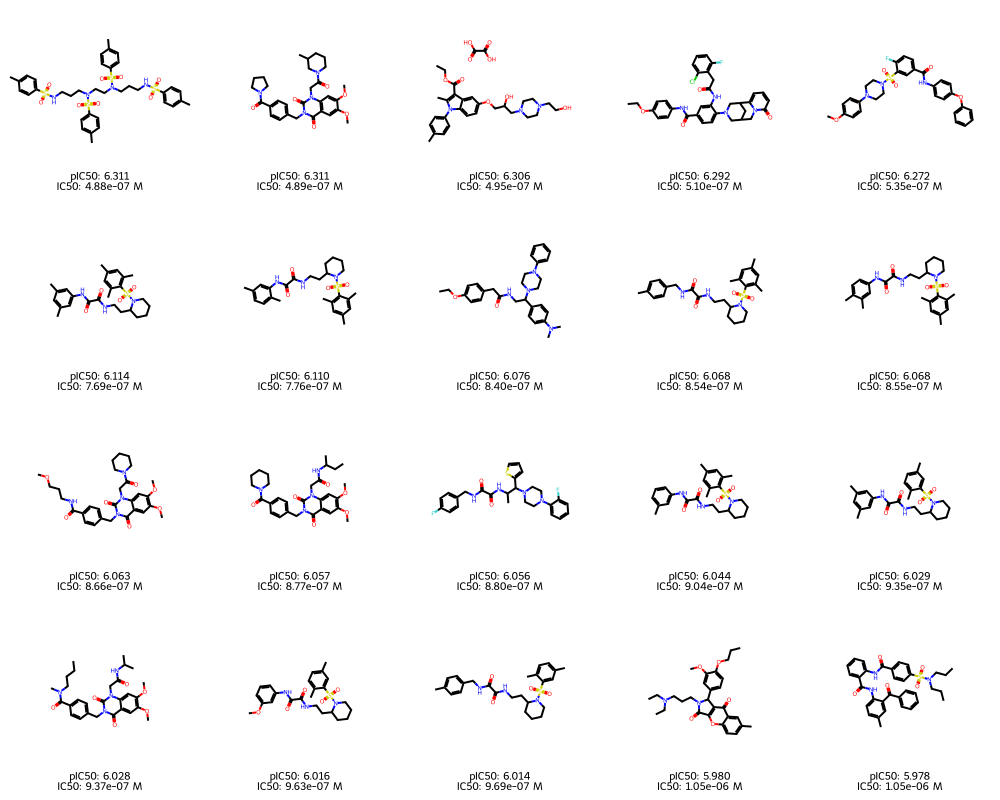

In [398]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = resultsDir + 'EbolaAllSpecies/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in LCAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in EnamineAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'EbolaAllSpecies_noDuplicates_predictedCompounds_LCDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'EbolaAllSpecies_noDuplicates_predictedCompounds_LCDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

# 2.3 Discovery of new hits specific to all viruses (data source chemDiv data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. The custom library compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [399]:
# Read all molecules from SDF
supplier = Chem.SDMolSupplier(dataDir + "ChemDiv/ChemDiv_Antiviral-Library-64958.sdf")
mols = [mol for mol in supplier if mol is not None]

# Extract properties into DataFrame
records = []
for mol in mols:
    props = mol.GetPropsAsDict()
    props["SMILES"] = Chem.MolToSmiles(mol)
    records.append(props)

ChemDivAntiviralsData = pd.DataFrame(records)
print(f"Original ChemDiv data shape: {ChemDivAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to ChemDiv data (reusing canonical_train from previous code)
ChemDivAntiviralsData['Canonical_SMILES'] = ChemDivAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~ChemDivAntiviralsData['Canonical_SMILES'].isin(canonical_train)
ChemDivAntiviralsData_filtered = ChemDivAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
ChemDivAntiviralsData = ChemDivAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered ChemDiv data shape for validation: {ChemDivAntiviralsData.shape}")
print(f"Removed {ChemDivAntiviralsData_filtered.shape[0] - ChemDivAntiviralsData.shape[0]} duplicate compounds from ChemDiv data set")

# Now use the filtered data
smi_lib = ChemDivAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
ChemDivAntiviralsData

Original ChemDiv data shape: (64958, 28)
Number of unique SMILES in training set: 540
Filtered ChemDiv data shape for validation: (64957, 28)
Removed 0 duplicate compounds from ChemDiv data set
Total compounds to screen: 64957


,IDNUMBER,available,H_acceptor,H_donor,B_rotN,N_O,logP,logD,logSw,PSA,...,InChI Key,PERCENTSP3,Link,CLNUMBER,Saltdata,Saltdata_MW,STEREO,State,SMILES,CAS
0,E676-1193,55,6,0,10,6.000,4.584,3.825,-4.736,44.193,...,CADSCKHSUSMLDE-UHFFFAOYSA-N,33.300,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,ACHIRAL,Solid,CCOc1cccc2sc(N(CCN(C)C)C(=O)COc3ccc(Cl)cc3)nc12,NaN
1,E676-4289,2,8,0,9,7.000,2.084,1.279,-2.867,59.381,...,GBCBRISSOXAFMF-UHFFFAOYSA-N,47.400,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,ACHIRAL,Solid,CCN(CC)CCN(C(=O)CN1C(=O)CCC1=O)c1nc2c(Cl)cccc2s1,NaN
2,E676-2516,15,7,0,7,7.000,4.274,3.444,-4.355,53.078,...,LSLRIDUYGBBIBR-SFHVURJKSA-N,36.400,https://www.chemdiv.com/catalog/screening-comp...,CL4971B,HCl,36.461,RACEMIC MIXTURE,Solid,COc1ccc(C)c2sc(N(CCN(C)C)C(=O)C3COc4ccccc4O3)nc12,NaN
3,F735-0482,21,7,2,9,7.000,3.231,3.225,-3.423,79.491,...,NBFDETMKPOQYSJ-UHFFFAOYSA-N,22.200,https://www.chemdiv.com/catalog/screening-comp...,CL8286,NaN,NaN,ACHIRAL,Solid,CCCc1nnc(C(=O)Nc2ccc(C(=O)NCc3ccco3)cc2)s1,NaN
4,G211-0195,304,5,1,5,5.000,5.054,5.054,-5.469,49.877,...,DRPXIGZHBISZAU-UHFFFAOYSA-N,32.000,https://www.chemdiv.com/catalog/screening-comp...,CL6036,NaN,NaN,ACHIRAL,Solid,O=C(NCc1cccc(Cl)c1)c1c2c(nc3ccccc13)C(=O)N(C1C...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64953,8010-2606,54,8,1,9,8.000,6.685,3.100,-6.678,70.818,...,ZQXAXHNEVALOJP-UHFFFAOYSA-N,30.800,https://www.chemdiv.com/catalog/screening-comp...,CL1650,NaN,NaN,ACHIRAL,Solid,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,NaN
64954,2774-1508,1,7,1,8,7.000,6.551,3.884,-5.738,62.323,...,KDXCUTJRVPCZKK-UHFFFAOYSA-N,25.000,https://www.chemdiv.com/catalog/screening-comp...,CL1652,NaN,NaN,ACHIRAL,Solid,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,NaN
64955,K061-0539,124,7,1,7,7.000,6.014,2.429,-5.464,64.713,...,XEIANUQFWJNADZ-UHFFFAOYSA-N,27.300,https://www.chemdiv.com/catalog/screening-comp...,CL1647,NaN,NaN,ACHIRAL,Solid,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,NaN
64956,K061-0894,165,6,1,7,7.000,6.905,6.387,-6.761,57.369,...,IBXAKUXFQPUZBE-UHFFFAOYSA-N,13.600,https://www.chemdiv.com/catalog/screening-comp...,CL1650,NaN,NaN,ACHIRAL,Solid,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,NaN


In [400]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

50000


In [401]:
ChemDivAntiviralsData_predicted = ChemDivAntiviralsData.copy()
ChemDivAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
ChemDivAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-ChemDivAntiviralsData_predicted['pPotency_prediction'])

ChemDivAntiviralsData_predicted = ChemDivAntiviralsData_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
ChemDivAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "EbolaAllSpecies/EbolaAllSpecies_noDuplicates_ChemDivDatasets_predicted_all.csv"), index=False)
ChemDivAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "EbolaAllSpecies/EbolaAllSpecies_noDuplicates_ChemDivDatasets_predicted_all_SMILES.csv"), index=False)
ChemDivAntiviralsData_predicted

,SMILES,pPotency_prediction,pPotency(M)_prediction
0,CCOc1cccc2sc(N(CCN(C)C)C(=O)COc3ccc(Cl)cc3)nc12,5.491,3.228e-06
1,CCN(CC)CCN(C(=O)CN1C(=O)CCC1=O)c1nc2c(Cl)cccc2s1,5.435,3.676e-06
2,COc1ccc(C)c2sc(N(CCN(C)C)C(=O)C3COc4ccccc4O3)nc12,5.516,3.044e-06
3,CCCc1nnc(C(=O)Nc2ccc(C(=O)NCc3ccco3)cc2)s1,4.902,1.254e-05
4,O=C(NCc1cccc(Cl)c1)c1c2c(nc3ccccc13)C(=O)N(C1C...,5.362,4.345e-06
...,...,...,...
64953,CCOC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(OC...,5.752,1.771e-06
64954,CCOC(=O)c1c(NC(=O)c2cc3nc(-c4ccc(Br)cc4)cc(C(F...,5.519,3.029e-06
64955,COC(=O)c1c(NC(=O)c2nn3c(C(F)(F)F)cc(-c4cccs4)n...,5.564,2.730e-06
64956,COc1cc(NC(=O)c2nn3c(C(F)(F)F)cc(-c4ccc(Br)cc4)...,5.565,2.720e-06


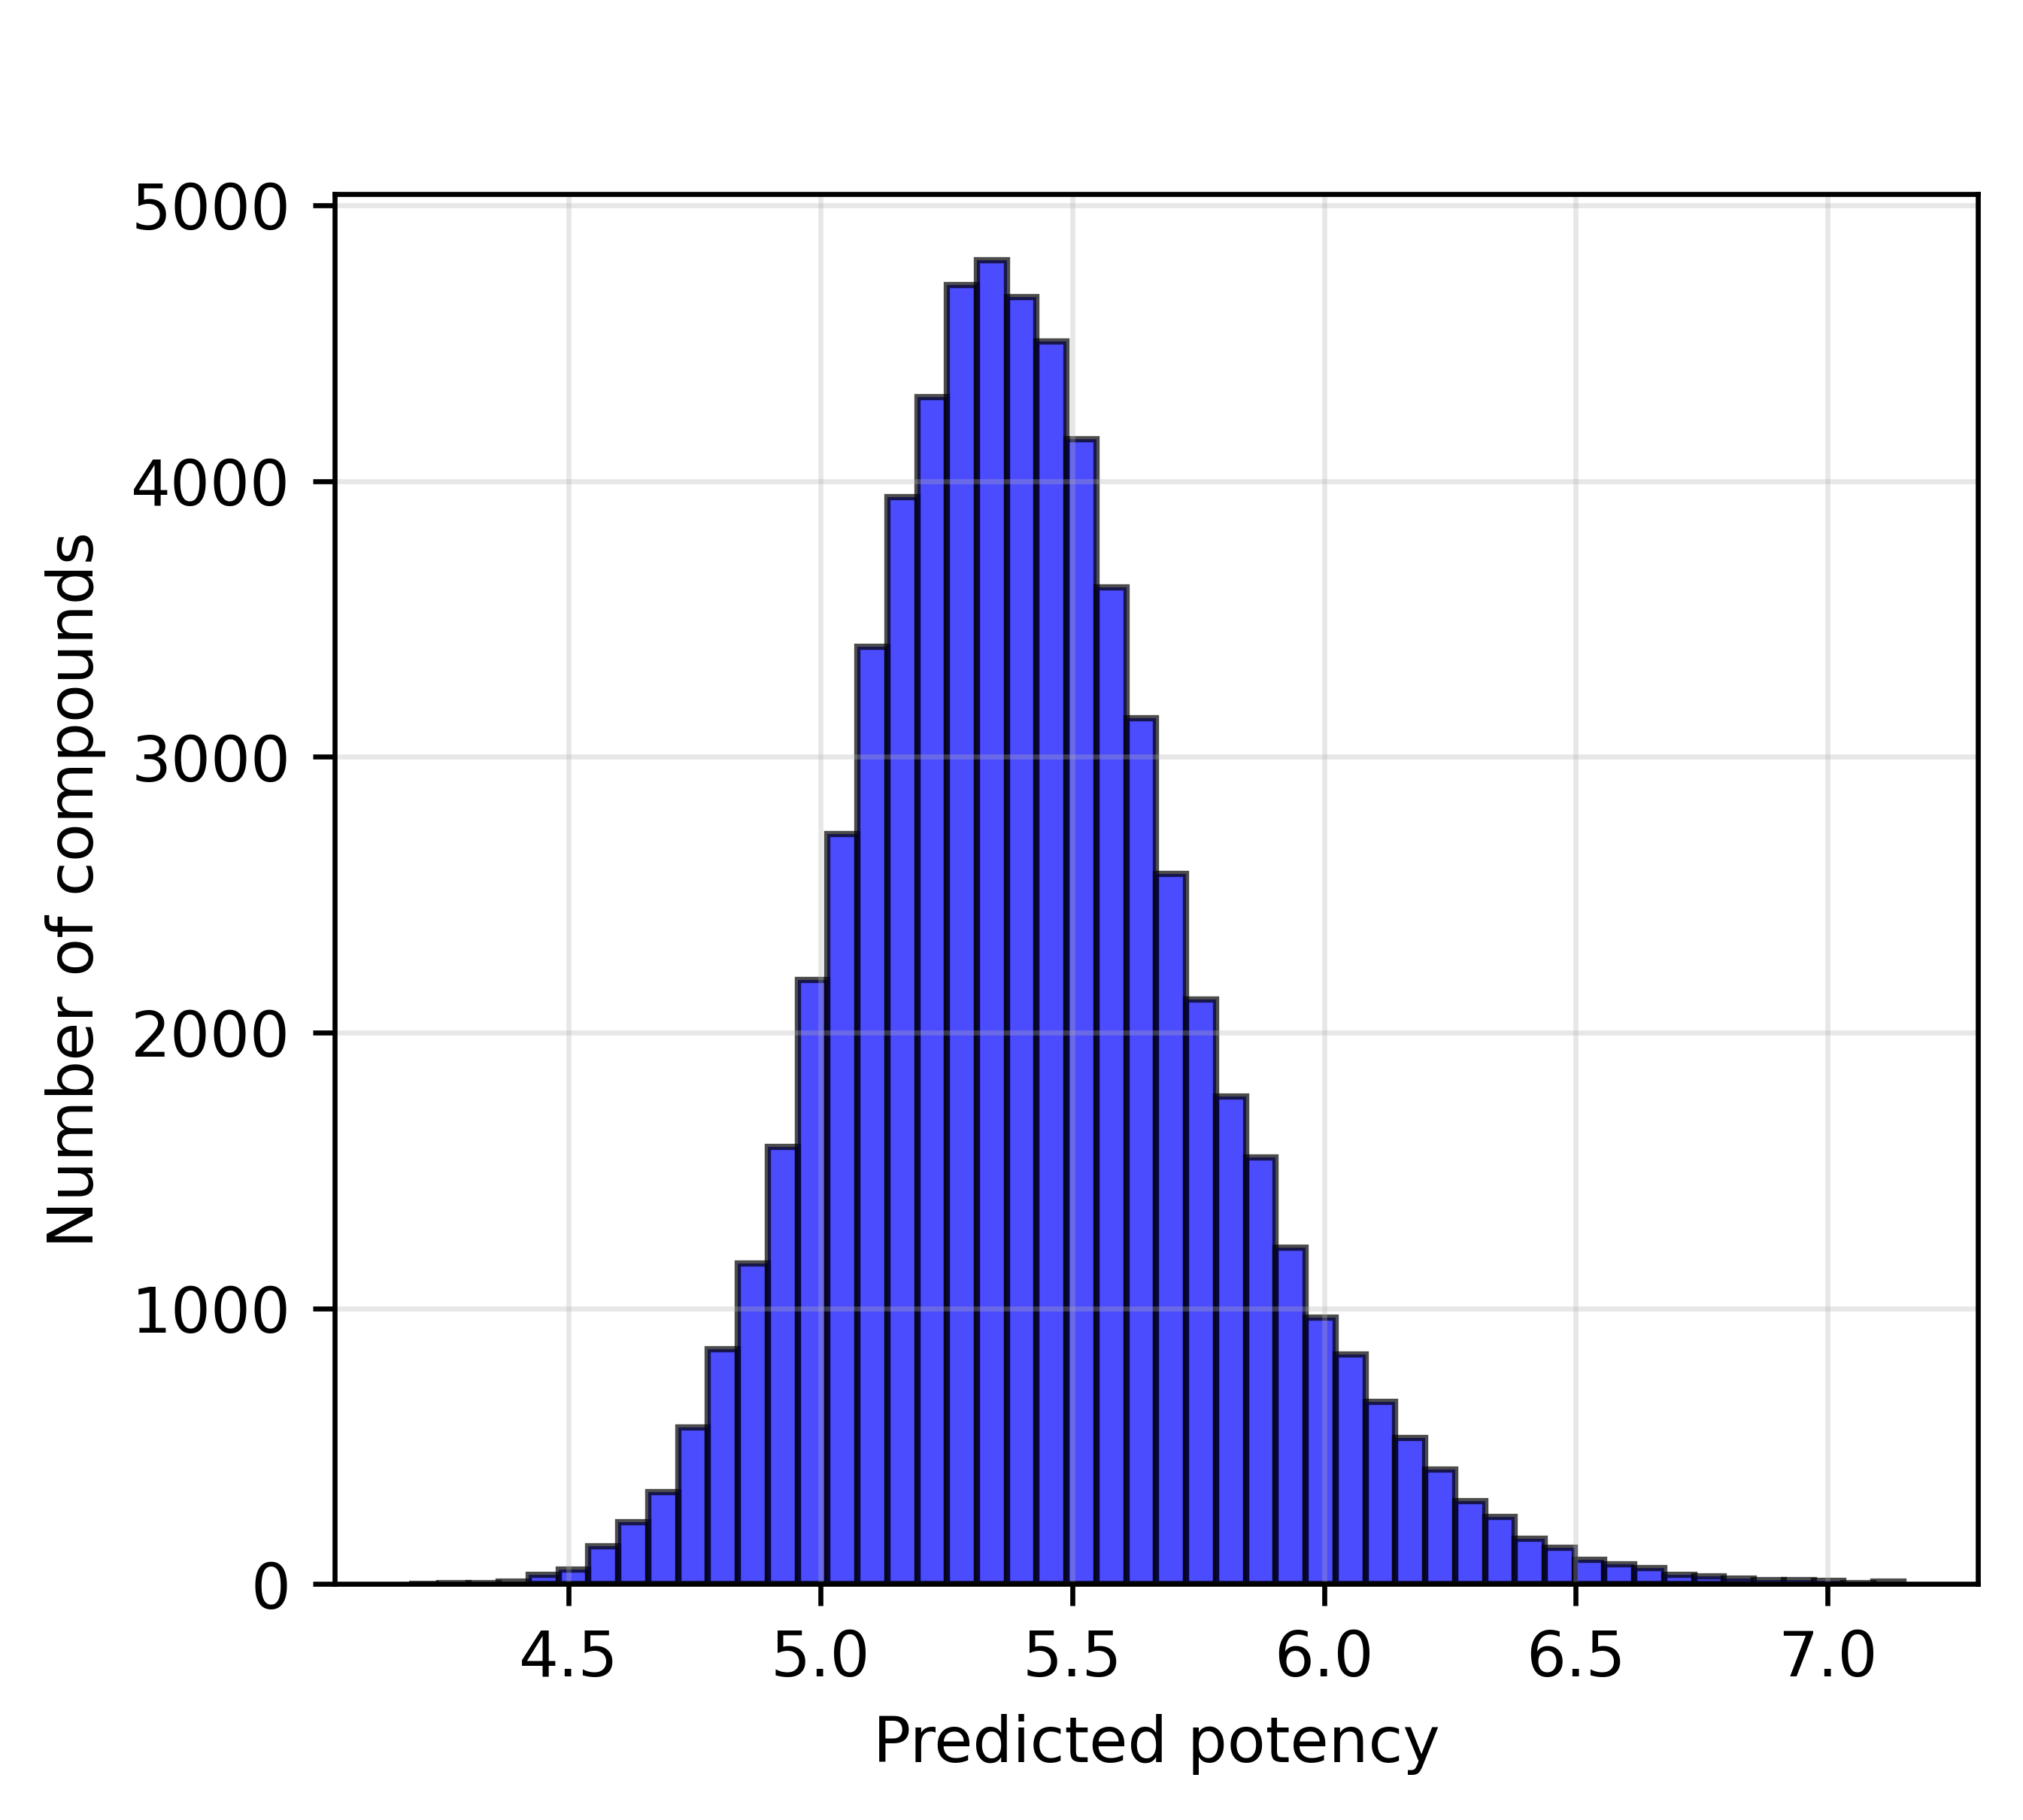

In [402]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'EbolaAllSpecies/EbolaAllSpecies_ChemDivDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'EbolaAllSpecies/EbolaAllSpecies_ChemDivDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [403]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7.0)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 20 compounds
Medium priority (6 ≤ pPotency < 7.0): 3971 compounds
Low priority (5 ≤ pPotency < 6): 54336 compounds


In [404]:
ChemDivAntiviralsData_final = ChemDivAntiviralsData.iloc[idx].copy()
ChemDivAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]
ChemDivAntiviralsData_final = ChemDivAntiviralsData_final.filter(
    items=["SMILES", "pPotency_prediction", "clogP"]
)
ChemDivAntiviralsData_final

,SMILES,pPotency_prediction
25,COc1cccc(NC(=O)C2[C@@H]3C=C[C@@]4(O3)C(C(=O)NC...,7.003
1611,CCOC(=O)N1CCC(NC(=O)c2ccc3c(c2)N(Cc2cc(C)ccc2C...,7.000
9595,CCN(CC)CCN1C(=O)C(O)=C(C(=O)c2ccc(S(=O)(=O)N3C...,7.080
34126,CCN1CCN(S(=O)(=O)c2cc(NC(=O)C3CC3)ccc2Oc2c(C)c...,7.032
34948,CCN(C)CCN(CC)C(=O)CCc1cc2c(n1-c1ccc(C)cc1OC)-c...,7.016
35031,C=CCN1C(=O)NC(c2ccc(C)cc2)C2=C1CN(C(Cc1ccccc1)...,7.138
36542,CCN1CCN(S(=O)(=O)c2cc(NC(=O)C3CC3)ccc2Oc2c(C)c...,7.018
36543,CCN1CCN(S(=O)(=O)c2cc(NC(=O)C(C)C)ccc2Oc2c(C)c...,7.151
37304,CCN1CCN(S(=O)(=O)c2cc(NC(=O)C3CCC3)ccc2Oc2c(C)...,7.009
42925,CCCCN(C)CCN1C(=O)[C@H]2C(C(=O)Nc3cccc(OC)c3)[C...,7.119


### Top 20 compounds with higher pPotency

In [405]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 7.00
Highest predicted pPotency: 7.15
Range of top 20: 7.00 - 7.15


In [406]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
ChemDivAntiviralsData_top20 = ChemDivAntiviralsData.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
ChemDivAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
ChemDivAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
ChemDivAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'

# Display the dataframe
ChemDivAntiviralsData_top20 = ChemDivAntiviralsData_top20.filter(
    items=["Rank", "SMILES", "pPotency_prediction", "IC50 (M)"]
)
ChemDivAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    7.000
  IC50:        9.989e-08 M  (99.89 nM)

Best Values (1st ranked compound):
  pPotency:    7.151
  IC50:        7.071e-08 M  (70.71 nM)
Range for Top 20 Compounds:
pPotency Range:  7.000 - 7.151

IC50 Range (M):  9.989e-08 - 7.071e-08


,Rank,SMILES,pPotency_prediction,IC50 (M)
36543,1,CCN1CCN(S(=O)(=O)c2cc(NC(=O)C(C)C)ccc2Oc2c(C)c...,7.151,7.071e-08
56756,2,CCOC(=O)N1CCN(C(=O)c2ccc3c(c2)N(Cc2cc(C)ccc2C)...,7.143,7.199e-08
35031,3,C=CCN1C(=O)NC(c2ccc(C)cc2)C2=C1CN(C(Cc1ccccc1)...,7.138,7.270e-08
45587,4,Cc1ccc(NC(=O)C2[C@H]3C=C[C@]4(O3)C(C(=O)NC3CCC...,7.128,7.442e-08
50253,5,CCCOc1ccc(C2C(C(=O)c3ccc(S(=O)(=O)N(C)C)cc3)=C...,7.125,7.496e-08
42925,6,CCCCN(C)CCN1C(=O)[C@H]2C(C(=O)Nc3cccc(OC)c3)[C...,7.119,7.595e-08
63240,7,Cc1ccc(NC(=O)C2[C@H]3C=C[C@]4(O3)C(C(=O)NC3CCC...,7.112,7.732e-08
50846,8,C=CCN1C(=O)NC(c2cccc(OCc3ccccc3)c2)C2=C1CN(CCN...,7.110,7.761e-08
45588,9,COc1cccc(NC(=O)C2[C@H]3C=C[C@]4(O3)C(C(=O)NC3C...,7.095,8.031e-08
9595,10,CCN(CC)CCN1C(=O)C(O)=C(C(=O)c2ccc(S(=O)(=O)N3C...,7.080,8.312e-08


In [407]:
ChemDivAntiviralsData_top20.to_csv(os.path.join(resultsDir + "EbolaAllSpecies/EbolaAllSpecies_noDuplicates_ChemDivAntiviralsData_top20.csv"), index=False)
ChemDivAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "EbolaAllSpecies/EbolaAllSpecies_noDuplicates_ChemDivAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Ebolavirus/EbolaVirus_predictedCompounds_noDuplicates_ChemDivDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/Ebolavirus/EbolaVirus_predictedCompounds_noDuplicates_ChemDivDataset.svg


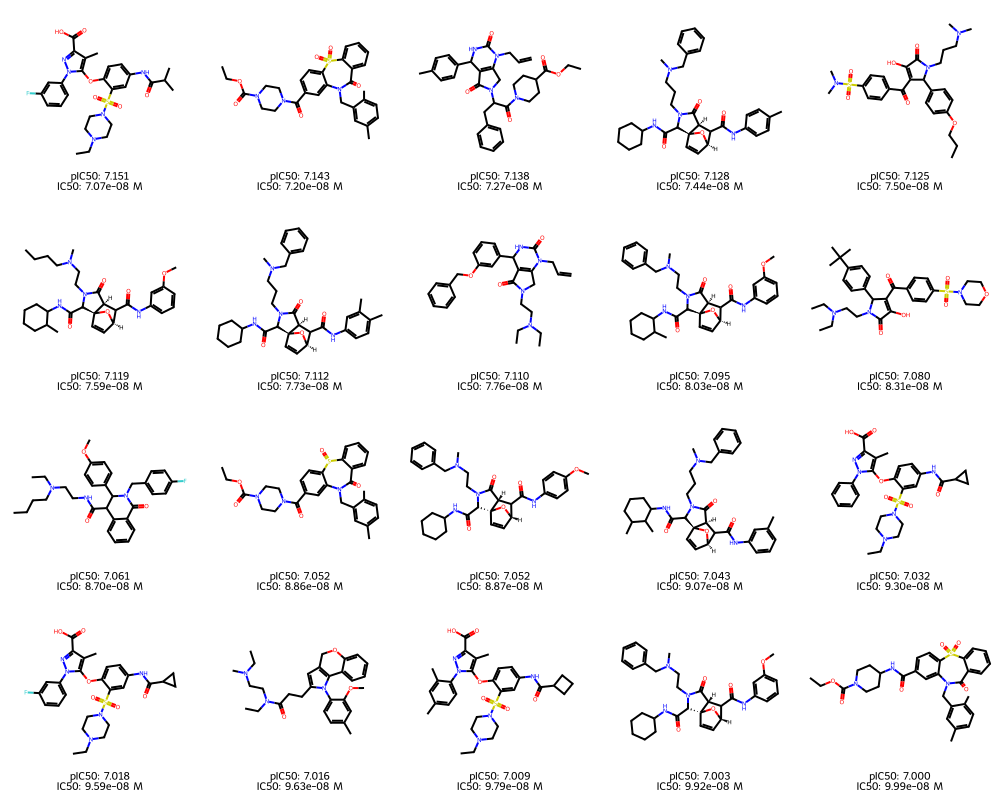

In [408]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = resultsDir + 'Ebolavirus/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in ChemDivAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in ChemDivAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'EbolaVirus_predictedCompounds_noDuplicates_ChemDivDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'EbolaVirus_predictedCompounds_noDuplicates_ChemDivDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### 2.4 Discovery of new hits specific to all viruses (data source SMACC Antivirals data set)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models regr above, which use 15-D MACAW embeddings as their input. In particular, we are interested in molecules with high predicted pPotency.

In [409]:
SMACCAntiviralsData = pd.read_csv(modelBuildingDataDir + "SMACCAntiviralsData_clean.csv")

# Check for duplicates
dup_check = SMACCAntiviralsData.groupby('SMILES')['pIC50'].agg(['count', 'median', 'std'])
duplicates = dup_check[dup_check['count'] > 1]
print(f"Original SMACC data shape: {SMACCAntiviralsData.shape}, with Duplicate SMILES: {len(duplicates)}")

# Take median pIC50 for duplicates
SMACCAntiviralsData = SMACCAntiviralsData.groupby('SMILES').agg({
    'Molecule ChEMBL ID': 'first',
    'pIC50': 'median',  # Use median instead of mean
    'Virus': 'first'
}).reset_index()

print(f"After removing internal duplicates: {SMACCAntiviralsData.shape}")

print(f"Number of unique SMILES in training set: {len(canonical_train)}")
# Add canonical SMILES column to SMACC data (reusing canonical_train from previous code)
SMACCAntiviralsData['Canonical_SMILES'] = SMACCAntiviralsData['SMILES'].apply(canonicalize_smiles)

# Filter out duplicates - keep only those NOT in training set
mask = ~SMACCAntiviralsData['Canonical_SMILES'].isin(canonical_train)
SMACCAntiviralsData_filtered = SMACCAntiviralsData[mask].copy()

# Remove the helper column if you don't need it
SMACCAntiviralsData = SMACCAntiviralsData_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered SMACC data shape for validation: {SMACCAntiviralsData.shape}")
print(f"Removed {SMACCAntiviralsData_filtered.shape[0] - SMACCAntiviralsData.shape[0]} duplicate compounds from SMACC data set")
SMACCAntiviralsData = SMACCAntiviralsData.rename(columns={'pIC50': 'pIC50_experimental'})

smi_lib = SMACCAntiviralsData.SMILES
print(f"Total compounds to screen: {len(smi_lib)}")
SMACCAntiviralsData.head()

Original SMACC data shape: (1923, 5), with Duplicate SMILES: 197
After removing internal duplicates: (1612, 4)
Number of unique SMILES in training set: 540
Filtered SMACC data shape for validation: (1612, 4)
Removed 0 duplicate compounds from SMACC data set
Total compounds to screen: 1612


,SMILES,Molecule ChEMBL ID,pIC50_experimental,Virus
0,Brc1ccc(NC(=O)CC2Sc3ncnn3C2=O)cc1,CHEMBL243652,5.690,SARS-CoV-2
1,Brc1ccc(Oc2ccc3NS(=O)(=O)C=C(OC(=O)c4ccccc4)c3...,CHEMBL4284511,5.328,Dengue
2,Brc1ccc(cc1)C1C2=C(NC(=S)NC2=O)OC2=C1C(=O)NC(=...,CHEMBL1402117,4.132,Dengue
3,Brc1ccc2C(=O)C(=O)C=Cc2c1,CHEMBL4303595,7.097,SARS-CoV-2
4,Brc1ccc2NC(=O)C(=C3SC(=S)N(NS(=O)(=O)c4ccccc4)...,CHEMBL1361582,4.627,Dengue


Generate predictions

In [410]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [411]:
SMACCAntiviralsData_predicted = SMACCAntiviralsData.copy()
SMACCAntiviralsData_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
SMACCAntiviralsData_predicted['IC50(M)_experimental'] = 10 ** (-SMACCAntiviralsData_predicted['pIC50_experimental'])
SMACCAntiviralsData_predicted['pPotency(M)_prediction'] = 10 ** (-SMACCAntiviralsData_predicted['pPotency_prediction'])

SMACCAntiviralsData_predicted = SMACCAntiviralsData_predicted.filter(
    items=["SMILES", "Virus", "pIC50_experimental", "pPotency_prediction",  "IC50(M)_experimental", "pPotency(M)_prediction"]
)
SMACCAntiviralsData_predicted

,SMILES,Virus,pIC50_experimental,pPotency_prediction,IC50(M)_experimental,pPotency(M)_prediction
0,Brc1ccc(NC(=O)CC2Sc3ncnn3C2=O)cc1,SARS-CoV-2,5.690,4.805,2.040e-06,1.568e-05
1,Brc1ccc(Oc2ccc3NS(=O)(=O)C=C(OC(=O)c4ccccc4)c3...,Dengue,5.328,5.118,4.700e-06,7.618e-06
2,Brc1ccc(cc1)C1C2=C(NC(=S)NC2=O)OC2=C1C(=O)NC(=...,Dengue,4.132,4.841,7.371e-05,1.442e-05
3,Brc1ccc2C(=O)C(=O)C=Cc2c1,SARS-CoV-2,7.097,4.290,8.000e-08,5.125e-05
4,Brc1ccc2NC(=O)C(=C3SC(=S)N(NS(=O)(=O)c4ccccc4)...,Dengue,4.627,5.069,2.359e-05,8.539e-06
...,...,...,...,...,...,...
1607,S=C1NN=C(Nc2ccccc2)S1,SARS-CoV-2,6.409,4.312,3.900e-07,4.876e-05
1608,S=C1Nc2ccccc2S1,SARS-CoV-2,5.759,4.254,1.740e-06,5.572e-05
1609,SC(=S)N1CCCC1,SARS-CoV-2,6.678,4.465,2.100e-07,3.426e-05
1610,c1coc(c1)-c1nc2ccccc2nc1-c1ccco1,Dengue,4.000,4.556,1.000e-04,2.780e-05


In [412]:
SMACCAntiviralsData_predicted.to_csv(os.path.join(resultsDir + "EbolaAllSpecies/EbolaAllSpecies_noDuplicates_SMACCAntiviralsData_predicted_all.csv"), index=False)
SMACCAntiviralsData_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "EbolaAllSpecies/EbolaAllSpecies_noDuplicates_SMACCAntiviralsData_predicted_all_SMILES.csv"), index=False)

### Plot the error between `experimental_pPotency` and `predicted_pPotency`

Mean Residual: 0.421
Std Dev of Residuals: 1.089
Min Residual: -4.417
Max Residual: 3.375


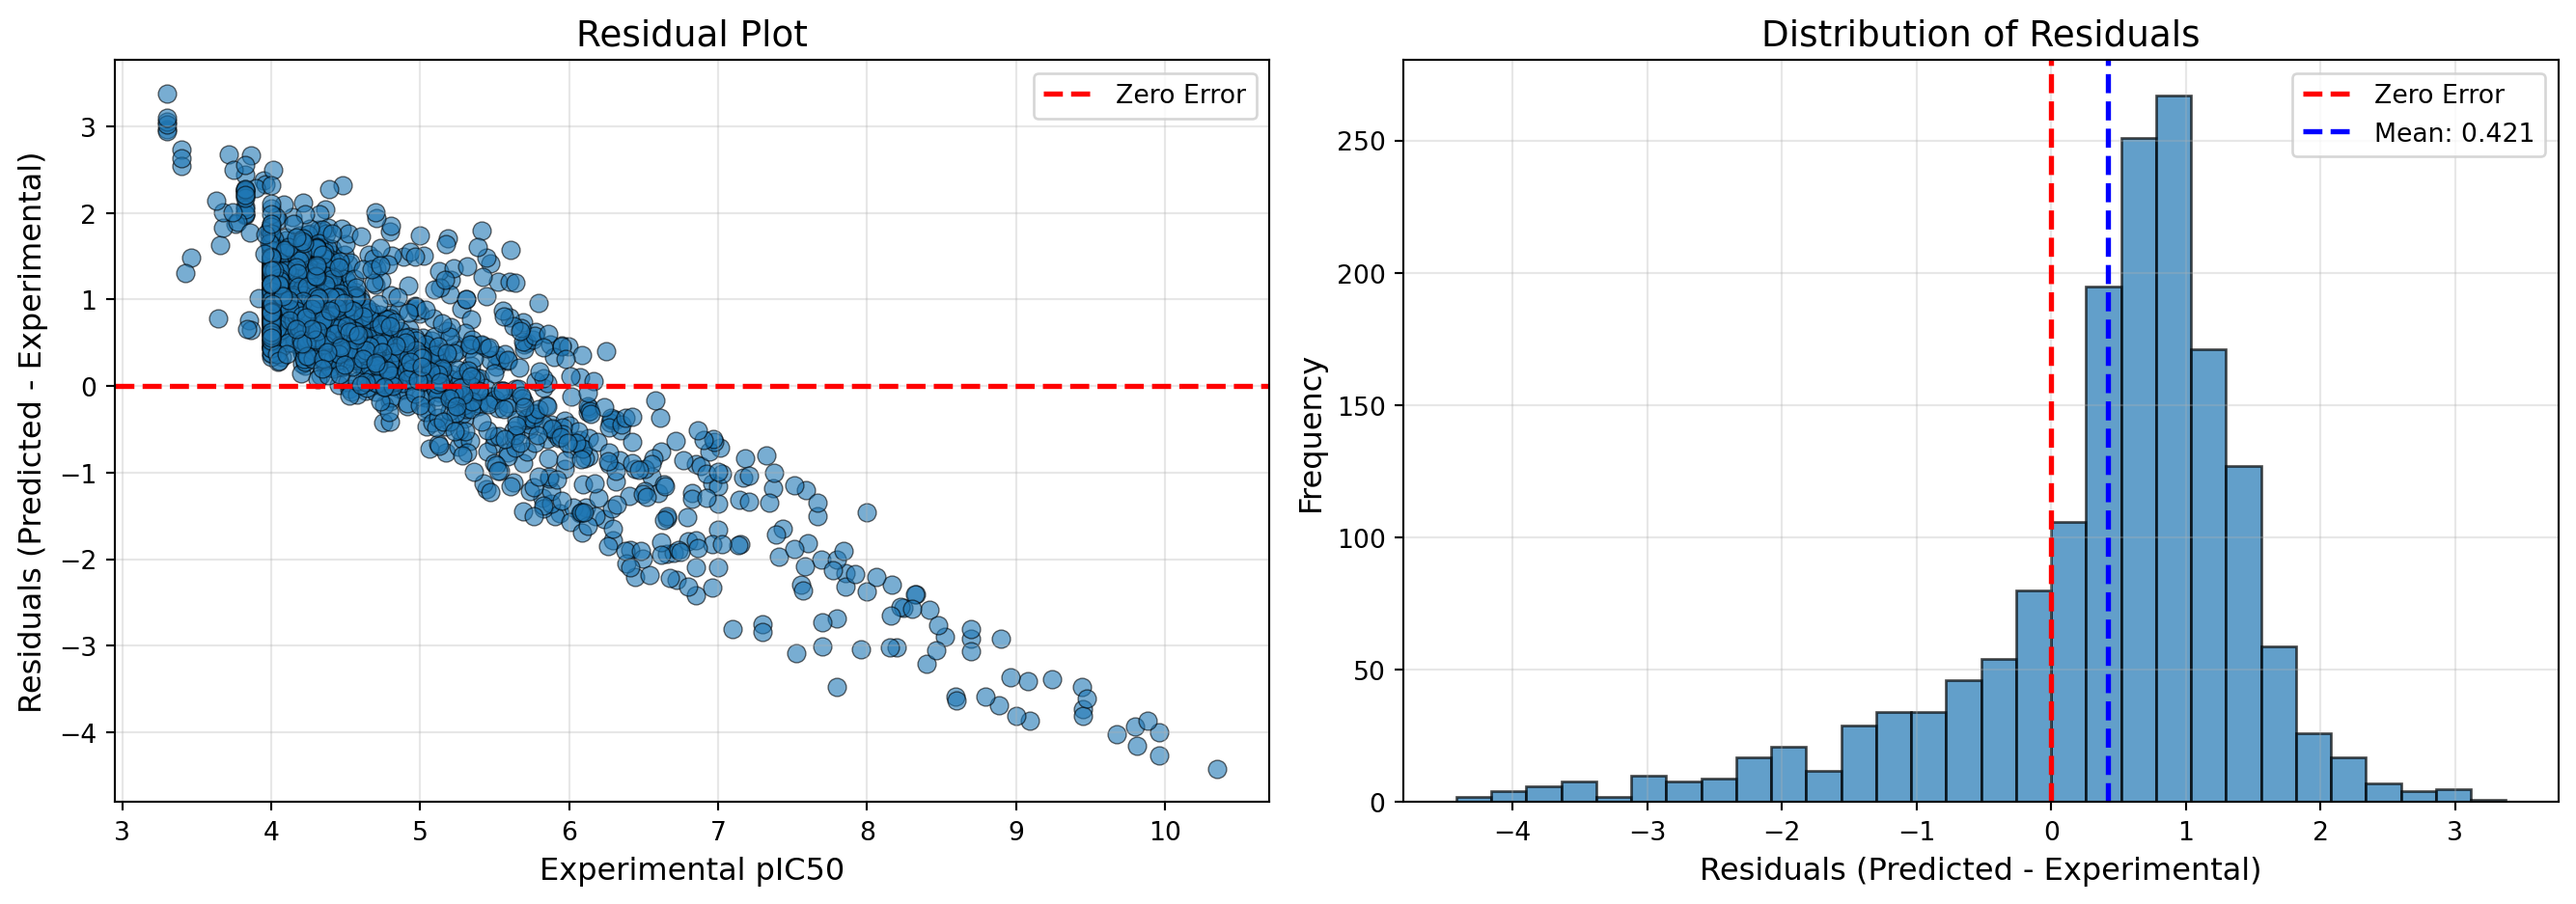

In [413]:
# Calculate residuals (difference)
SMACCAntiviralsData_predicted['residuals'] = (
    SMACCAntiviralsData_predicted['pPotency_prediction'] - 
    SMACCAntiviralsData_predicted['pIC50_experimental']
)

# Print statistics
print(f"Mean Residual: {SMACCAntiviralsData_predicted['residuals'].mean():.3f}")
print(f"Std Dev of Residuals: {SMACCAntiviralsData_predicted['residuals'].std():.3f}")
print(f"Min Residual: {SMACCAntiviralsData_predicted['residuals'].min():.3f}")
print(f"Max Residual: {SMACCAntiviralsData_predicted['residuals'].max():.3f}")

# Create residual plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residuals vs Experimental values
axes[0].scatter(SMACCAntiviralsData_predicted['pIC50_experimental'], 
                SMACCAntiviralsData_predicted['residuals'], 
                alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[0].set_xlabel('Experimental pIC50', fontsize=12)
axes[0].set_ylabel('Residuals (Predicted - Experimental)', fontsize=12)
axes[0].set_title('Residual Plot', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Distribution of residuals
axes[1].hist(SMACCAntiviralsData_predicted['residuals'], bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].axvline(x=SMACCAntiviralsData_predicted['residuals'].mean(), 
                color='blue', linestyle='--', linewidth=2, 
                label=f'Mean: {SMACCAntiviralsData_predicted["residuals"].mean():.3f}')
axes[1].set_xlabel('Residuals (Predicted - Experimental)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Residuals', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Residual Plot Analysis

In [414]:
print(f"Mean residual: {SMACCAntiviralsData_predicted['residuals'].mean():.3f} (Close to 0 indicates no systematic bias)")
print(f"Std deviation: {SMACCAntiviralsData_predicted['residuals'].std():.3f} (typical prediction error)")
print(f"95% of predictions are within ±{1.96 * SMACCAntiviralsData_predicted['residuals'].std():.3f} pIC50 units")

Mean residual: 0.421 (Close to 0 indicates no systematic bias)
Std deviation: 1.089 (typical prediction error)
95% of predictions are within ±2.135 pIC50 units


Let us have a look at the compounds:

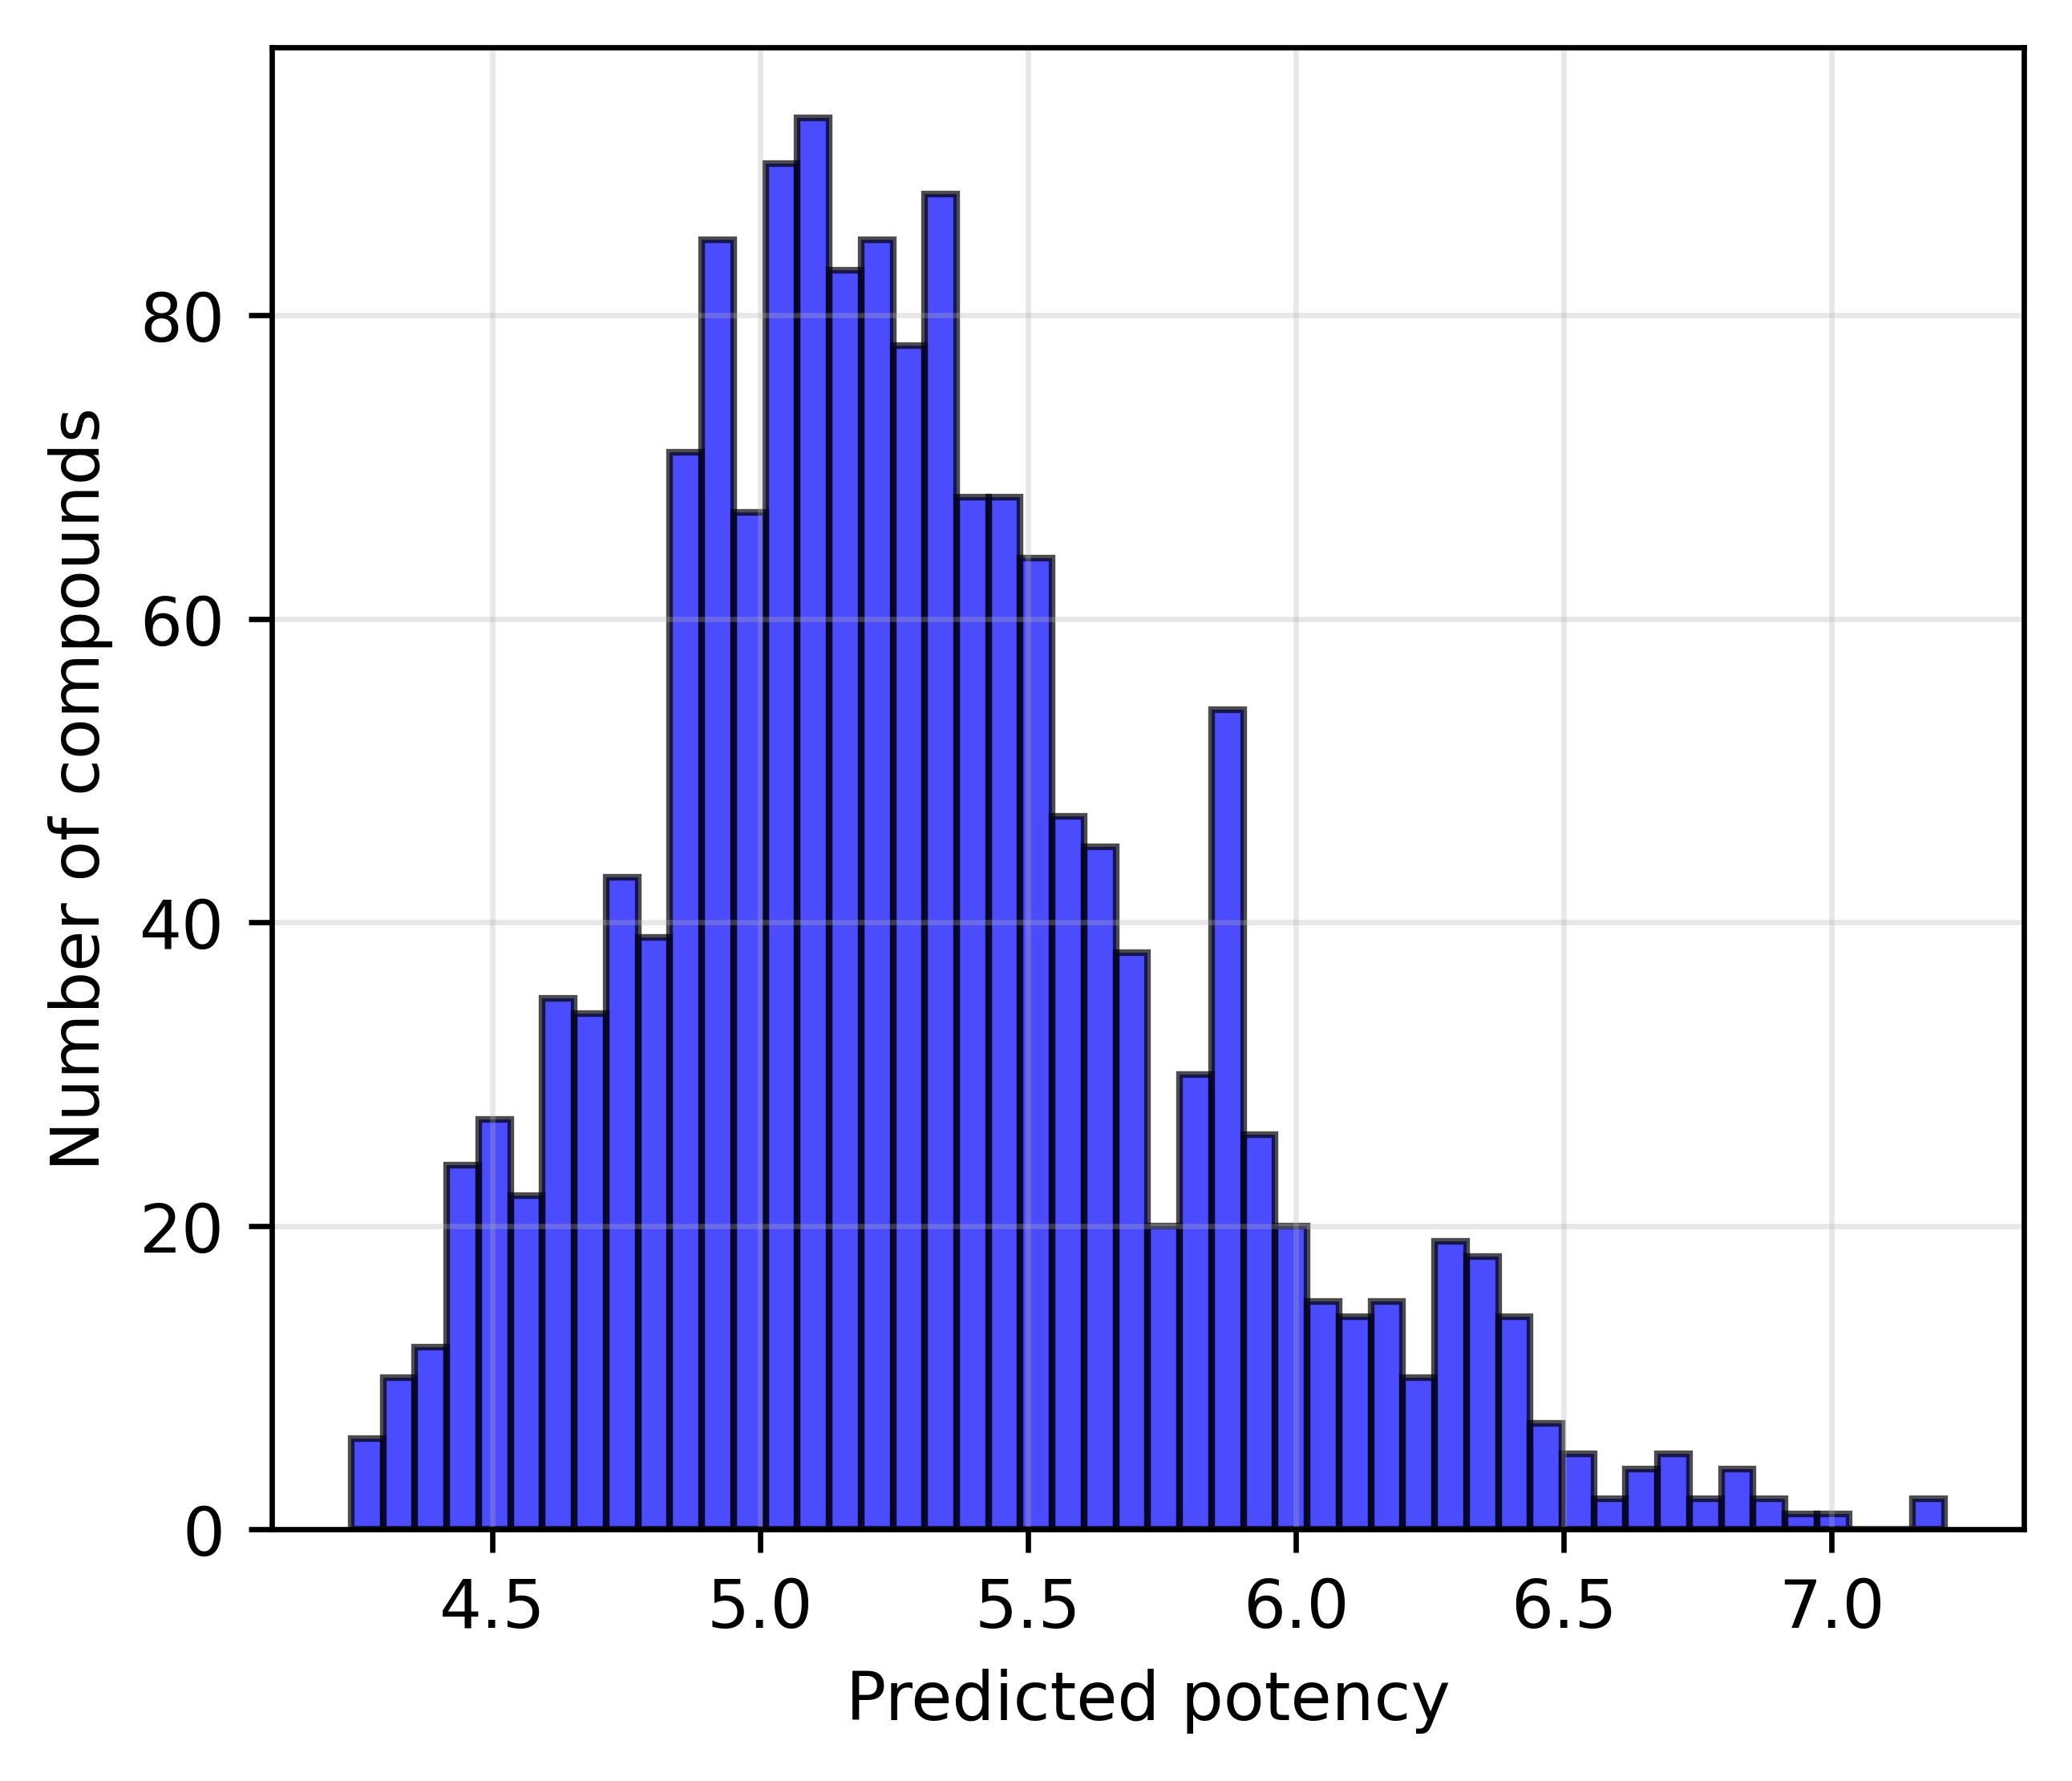

In [415]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
#plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
#plt.axvline(x=5, color='r', linestyle='--', linewidth=2) # label='pPotency = 5.0 (minimum)'
#plt.axvline(x=6, color='g', linestyle='--', linewidth=2) # label='pPotency = 6.0 (good)'
#plt.axvline(x=7, color='b', linestyle='--', linewidth=2) # label='pPotency = 7.0 (excellent)'

# Legend on top, outside plot area
#plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'EbolaAllSpecies/EbolaAllSpecies_noDuplicates_validation_noDuplicates_SMACCDatasets.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'EbolaAllSpecies/EbolaAllSpecies_noDuplicates_validation_noDuplicates_SMACCDatasets.png', bbox_inches='tight', dpi=300)
plt.show()

In [416]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 2 compounds
Medium priority (6 ≤ pPotency < 7.0): 144 compounds
Low priority (5 ≤ pPotency < 6): 1009 compounds


### Top 20 compounds with higher pPotency

In [417]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Get the cutoff pPotency (minimum value in top 20)
cutoff_pPotency = Y1_lib_pred[top_20_idx[-1]]  # Last (20th) value

print(f"Top 20 compounds cutoff pPotency: {cutoff_pPotency:.2f}")
print(f"Highest predicted pPotency: {Y1_lib_pred[top_20_idx[0]]:.2f}")
print(f"Range of top 20: {cutoff_pPotency:.2f} - {Y1_lib_pred[top_20_idx[0]]:.2f}")

Top 20 compounds cutoff pPotency: 6.65
Highest predicted pPotency: 7.21
Range of top 20: 6.65 - 7.21


In [418]:
# Get top 20 indices by highest predicted pPotency
top_20_idx = np.argsort(Y1_lib_pred)[::-1][:20]

# Create dataframe with top 20
SMACCAntiviralsData_top20 = SMACCAntiviralsData_predicted.iloc[top_20_idx].copy()

# Add pPotency_prediction rounded to 3 decimal places
SMACCAntiviralsData_top20['pPotency_prediction'] = Y1_lib_pred[top_20_idx].round(3)

# Add IC50 column (convert pPotency to Molar units)
# IC50 (M) = 10^(-pPotency)
SMACCAntiviralsData_top20['IC50 (M)'] = 10**(-Y1_lib_pred[top_20_idx])

# Add rank column at the beginning
SMACCAntiviralsData_top20.insert(0, 'Rank', range(1, 21))

# Calculate ranges
pPotency_max = Y1_lib_pred[top_20_idx[0]]   # Highest (best)
pPotency_min = Y1_lib_pred[top_20_idx[-1]]  # Lowest (cutoff)
IC50_min = 10**(-pPotency_max)              # Lowest IC50 (most potent)
IC50_max = 10**(-pPotency_min)              # Highest IC50 (least potent in top 20)
IC50_min_nM = IC50_min * 1e9
IC50_max_nM = IC50_max * 1e9

# Display information
print("-"*70)
print("Top 20 Compounds with Highest Predicted pPotency")
print("-"*70)
print("\nCutoff Values (20th ranked compound):")
print(f"  pPotency:    {pPotency_min:.3f}")
print(f"  IC50:        {IC50_max:.3e} M  ({IC50_max_nM:.2f} nM)")

print("\nBest Values (1st ranked compound):")
print(f"  pPotency:    {pPotency_max:.3f}")
print(f"  IC50:        {IC50_min:.3e} M  ({IC50_min_nM:.2f} nM)")


print("Range for Top 20 Compounds:")
print(f"pPotency Range:  {pPotency_min:.3f} - {pPotency_max:.3f}")
print(f"\nIC50 Range (M):  {IC50_max:.3e} - {IC50_min:.3e}")
#print(f"IC50 Range (nM): {IC50_max_nM:.2f} - {IC50_min_nM:.2f} nM")
#print(f"                 (Δ = {pPotency_max - pPotency_min:.3f})")
#print(f"                 (Fold change = {IC50_max/IC50_min:.1f}x)")


# Set pandas display options for scientific notation
pd.options.display.float_format = lambda x: f'{x:.3e}' if abs(x) < 0.01 or abs(x) > 1000 else f'{x:.3f}'


SMACCAntiviralsData_top20

----------------------------------------------------------------------
Top 20 Compounds with Highest Predicted pPotency
----------------------------------------------------------------------

Cutoff Values (20th ranked compound):
  pPotency:    6.651
  IC50:        2.236e-07 M  (223.58 nM)

Best Values (1st ranked compound):
  pPotency:    7.210
  IC50:        6.159e-08 M  (61.59 nM)
Range for Top 20 Compounds:
pPotency Range:  6.651 - 7.210

IC50 Range (M):  2.236e-07 - 6.159e-08


,Rank,SMILES,Virus,pIC50_experimental,pPotency_prediction,IC50(M)_experimental,pPotency(M)_prediction,residuals,IC50 (M)
47,1,CC(=O)Nc1ccc(CC(NC(=O)c2ccccc2)C(=O)NC(CCCCN)C...,West_Nile,5.415,7.210,3.850e-06,6.159e-08,1.796,6.159e-08
1148,2,NCCCCC(NC(=O)C(Cc1cccc(NC(N)=N)c1)NC(=O)c1cccc...,West_Nile,5.606,7.182,2.480e-06,6.574e-08,1.577,6.574e-08
1126,3,NCCCCC(NC(=O)C(CCCNC(N)=N)NC(=O)C(=O)c1ccccc1)...,Dengue,5.387,6.993,4.100e-06,1.016e-07,1.606,1.016e-07
453,4,CN(C(CCCNC(N)=N)C(=O)NC(CCCCN)C(=O)NC(C(N)=O)c...,Dengue,5.444,6.924,3.600e-06,1.191e-07,1.480,1.191e-07
900,5,Cc1ccc(cc1)N1CC(NC(=O)C(NC(=O)C(CCCCN)NC(=O)C(...,Dengue,5.184,6.891,6.552e-06,1.286e-07,1.707,1.286e-07
452,6,CN(C(CCCNC(N)=N)C(=O)NC(CCCCN)C(=O)NC(C(N)=O)c...,Dengue,5.472,6.885,3.370e-06,1.303e-07,1.413,1.303e-07
1141,7,NCCCCC(NC(=O)C(CCCNC(N)=N)NC(=O)c1ccccc1)C(=O)...,Dengue,5.638,6.828,2.300e-06,1.485e-07,1.190,1.485e-07
1139,8,NCCCCC(NC(=O)C(CCCNC(N)=N)NC(=O)c1ccccc1)C(=O)...,Dengue,5.602,6.809,2.500e-06,1.552e-07,1.207,1.552e-07
978,9,Cc1cccc(c1)N1CC(NC(=O)C(NC(=O)C(CCCCN)NC(=O)C(...,Dengue,5.169,6.808,6.776e-06,1.557e-07,1.639,1.557e-07
281,10,CCCCC(NC(=O)c1ccccc1)C(=O)NC(CCCCN)C(=O)NC(CCC...,Dengue,4.481,6.804,3.300e-05,1.572e-07,2.322,1.572e-07


In [419]:
SMACCAntiviralsData_top20.to_csv(os.path.join(resultsDir + "EbolaAllSpecies/EbolaAllSpecies_noDuplicates_SMACCAntiviralsData_top20.csv"), index=False)
SMACCAntiviralsData_top20[['SMILES']].to_csv(os.path.join(resultsDir + "EbolaAllSpecies/EbolaAllSpecies_noDuplicates_SMACCAntiviralsData_top20_SMILES.csv"), index=False)

 Saved PNG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/EbolavirusAllStrain/EbolavirusAllStrain_predictedCompounds_noDuplicates_SMACCDataset.png
 Saved SVG: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/EbolavirusAllStrain/EbolavirusAllStrain_predictedCompounds_noDuplicates_SMACCDataset.svg


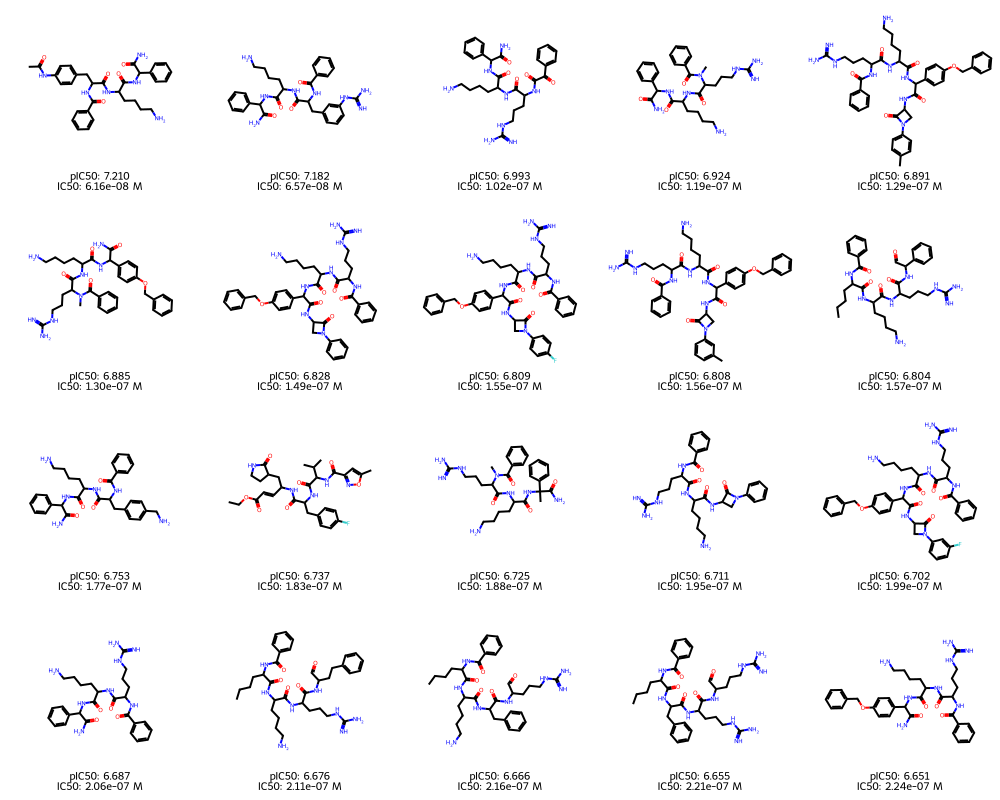

In [420]:
from rdkit import Chem
from rdkit.Chem import Draw
import os
from PIL import Image

# Setup paths
output_dir = resultsDir + 'EbolaAllSpecies/'
os.makedirs(output_dir, exist_ok=True)

# Get molecules
molecules = [Chem.MolFromSmiles(smi) for smi in SMACCAntiviralsData_top20.SMILES[:50]]

# Create legends
legends = []
for idx, row in SMACCAntiviralsData_top20[:50].iterrows():
    legend = f"pIC50: {row['pPotency_prediction']:.3f}\nIC50: {row['IC50 (M)']:.2e} M"
    legends.append(legend)

# Generate PNG image
img = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=False, 
    legends=legends,
    returnPNG=False  # Returns PIL Image object
)

# Save PNG
output_png = output_dir + 'EbolaAllSpecies_predictedCompounds_noDuplicates_SMACCDataset.png'
img.save(output_png, dpi=(600, 600))
print(f" Saved PNG: {output_png}")

# Generate and save SVG
svg = Draw.MolsToGridImage(
    molecules, 
    subImgSize=(200, 200), 
    molsPerRow=5, 
    useSVG=True,
    legends=legends
)

output_svg = output_dir + 'EbolaAllSpecies_predictedCompounds_noDuplicates_SMACCDataset.svg'
with open(output_svg, 'w') as f:
    f.write(svg.data)
print(f" Saved SVG: {output_svg}")


display(img)  

### Checking drug likeliness of `Remdesivir` and `Molnupiravir`

In [421]:
Remdesivir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Remdesivir_structure.mol")
Molnupiravir_SMILES_file = os.path.join(dataDir + "/target_SMILES/Molnupiravir_structure.mol")

In [422]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd

# SMILES strings
Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'
Molnupiravir_SMILES = 'CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=C\C(NC1=O)=N\O'

# Dictionary of drugs and their SMILES
drugs = {
    'Remdesivir': Remdesivir_SMILES,
    'Molnupiravir': Molnupiravir_SMILES
}

# List to store results
smiles_data = []

# Process each drug
for drug_name, smiles in drugs.items():
    # Convert SMILES to molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        smiles_data.append({
            'Drug_Name': drug_name,
            'SMILES': smiles,
            'Molecular_Formula': rdMolDescriptors.CalcMolFormula(mol),
            'Molecular_Weight': round(Descriptors.MolWt(mol), 2)
        })
        print(f" {drug_name}")
        print(f"  Formula: {rdMolDescriptors.CalcMolFormula(mol)}")
        print(f"  MW: {round(Descriptors.MolWt(mol), 2)} g/mol")
    else:
        print(f" Failed to parse SMILES for {drug_name}")

# Create DataFrame
DTRA_target_SMILES = pd.DataFrame(smiles_data)
DTRA_target_SMILES

 Remdesivir
  Formula: C27H35N6O8P
  MW: 602.59 g/mol
 Molnupiravir
  Formula: C13H19N3O7
  MW: 329.31 g/mol


,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,C27H35N6O8P,602.590
1,Molnupiravir,CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=...,C13H19N3O7,329.310


In [423]:
# Canonicalize training SMILES and create a set for fast lookup
canonical_train = set()
for smi in smiles_train:
    canonical_smi = canonicalize_smiles(smi)
    if canonical_smi is not None:
        canonical_train.add(canonical_smi)

print(f"Number of unique SMILES in training set: {len(canonical_train)}")

# Add canonical SMILES column to DTRA target data
DTRA_target_SMILES['Canonical_SMILES'] = DTRA_target_SMILES['SMILES'].apply(canonicalize_smiles)

# ADDED: Save original count BEFORE filtering
original_count = DTRA_target_SMILES.shape[0]

# Filter out duplicates - keep only those NOT in training set
mask = ~DTRA_target_SMILES['Canonical_SMILES'].isin(canonical_train)
DTRA_target_SMILES_filtered = DTRA_target_SMILES[mask].copy()

# Remove the helper column if you don't need it
DTRA_target_SMILES = DTRA_target_SMILES_filtered.drop('Canonical_SMILES', axis=1)

print(f"Filtered DTRA target data shape for validation: {DTRA_target_SMILES.shape}")
print(f"Removed {original_count - DTRA_target_SMILES.shape[0]} duplicate compounds from DTRA target data set")  # FIXED

# Now use the filtered data
smi_lib = DTRA_target_SMILES.SMILES
print(f"Total DTRA target compounds to screen: {len(smi_lib)}")

# Display the filtered data
DTRA_target_SMILES

Number of unique SMILES in training set: 540
Filtered DTRA target data shape for validation: (1, 4)
Removed 1 duplicate compounds from DTRA target data set
Total DTRA target compounds to screen: 1


,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight
1,Molnupiravir,CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=...,C13H19N3O7,329.310


Generate predictions

In [424]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [425]:
DTRA_target_SMILES_predicted = DTRA_target_SMILES.copy()
DTRA_target_SMILES_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
DTRA_target_SMILES_predicted['pPotency(M)_prediction'] = 10 ** (-DTRA_target_SMILES_predicted['pPotency_prediction'])

DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted.filter(
    items=["SMILES", "pPotency_prediction",  "pPotency(M)_prediction"]
)
DTRA_target_SMILES_predicted.to_csv(os.path.join(resultsDir + "EbolaAllSpecies/EbolaAllSpecies_noDuplicates_DTRAtargets_predicted_all.csv"), index=False)
DTRA_target_SMILES_predicted[['SMILES']].to_csv(os.path.join(resultsDir + "EbolaAllSpecies/EbolaAllSpecies_noDuplicates_DTRAtargets_predicted_all_SMILES.csv"), index=False)
DTRA_target_SMILES_predicted

,SMILES,pPotency_prediction,pPotency(M)_prediction
1,CC(C)C(=O)OC[C@H]1O[C@H]([C@H](O)[C@@H]1O)N1C=...,5.263,5.460e-06


### Checking efficiency of `Remdesivir` as a antiviral, it present in training data set

In [426]:
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
import pandas as pd

# SMILES strings
Remdesivir_SMILES = 'CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](C#N)([C@H](O)[C@@H]1O)C1=CC=C2N1N=CN=C2N)OC1=CC=CC=C1'

# Dictionary of drugs and their SMILES
drugs = {
    'Remdesivir': Remdesivir_SMILES,
}

# List to store results
smiles_data = []

# Process each drug
for drug_name, smiles in drugs.items():
    # Convert SMILES to molecule object
    mol = Chem.MolFromSmiles(smiles)
    
    if mol is not None:
        smiles_data.append({
            'Drug_Name': drug_name,
            'SMILES': smiles,
            'Molecular_Formula': rdMolDescriptors.CalcMolFormula(mol),
            'Molecular_Weight': round(Descriptors.MolWt(mol), 2)
        })
        print(f" {drug_name}")
        print(f"  Formula: {rdMolDescriptors.CalcMolFormula(mol)}")
        print(f"  MW: {round(Descriptors.MolWt(mol), 2)} g/mol")
    else:
        print(f" Failed to parse SMILES for {drug_name}")

# Create DataFrame
DTRA_target_SMILES = pd.DataFrame(smiles_data)
DTRA_target_SMILES

 Remdesivir
  Formula: C27H35N6O8P
  MW: 602.59 g/mol


,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,C27H35N6O8P,602.590


Find experimental pPotency value for `Remdesivir`

In [427]:
# Function to canonicalize SMILES
def canonicalize_smiles(smi):
    try:
        mol = Chem.MolFromSmiles(smi)
        return Chem.MolToSmiles(mol, canonical=True) if mol else None
    except:
        return None

# Create mappings from allVirusData (without modifying it)
canonical_smiles = EbolaAllSpeciesData_chEMBL_uM_noDuplicates['Smiles'].apply(canonicalize_smiles)
smiles_to_pPotency = dict(zip(canonical_smiles, EbolaAllSpeciesData_chEMBL_uM_noDuplicates['pPotency']))
smiles_to_virus = dict(zip(canonical_smiles, EbolaAllSpeciesData_chEMBL_uM_noDuplicates['StrainClassifier']))

# Add columns to DTRA_target_SMILES
DTRA_target_SMILES['pIC50_experimental'] = DTRA_target_SMILES['SMILES'].apply(
    lambda x: smiles_to_pPotency.get(canonicalize_smiles(x), None)
)
DTRA_target_SMILES['StrainClassifier'] = DTRA_target_SMILES['SMILES'].apply(
    lambda x: smiles_to_virus.get(canonicalize_smiles(x), None)
)

# Display
print(f"Compounds with experimental data: {DTRA_target_SMILES['pIC50_experimental'].notna().sum()}")
DTRA_target_SMILES

Compounds with experimental data: 1


,Drug_Name,SMILES,Molecular_Formula,Molecular_Weight,pIC50_experimental,StrainClassifier
0,Remdesivir,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,C27H35N6O8P,602.590,7.033,Ebola


In [428]:
# Now use the filtered data
smi_lib = DTRA_target_SMILES.SMILES
print(f"Total DTRA target compounds to screen: {len(smi_lib)}")

Total DTRA target compounds to screen: 1


Generate predictions

In [429]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

In [430]:
DTRA_target_SMILES_predicted = DTRA_target_SMILES.copy()
DTRA_target_SMILES_predicted['pPotency_prediction'] = Y1_lib_pred

# Convert pPotency to IC50 (M)
# pPotency = -log10(IC50), so IC50 = 10^(-pPotency)
DTRA_target_SMILES_predicted['IC50(M)_experimental'] = 10 ** (-DTRA_target_SMILES_predicted['pIC50_experimental'])
DTRA_target_SMILES_predicted['pPotency(M)_prediction'] = 10 ** (-DTRA_target_SMILES_predicted['pPotency_prediction'])

DTRA_target_SMILES_predicted = DTRA_target_SMILES_predicted.filter(
    items=["SMILES", "VirusClassifier", "pIC50_experimental", "pPotency_prediction",  "IC50(M)_experimental", "pPotency(M)_prediction"]
)
DTRA_target_SMILES_predicted

,SMILES,pIC50_experimental,pPotency_prediction,IC50(M)_experimental,pPotency(M)_prediction
0,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@](...,7.033,6.022,9.274e-08,9.513e-07


Partition 3/10
  Fold 3 - Train MAE: 0.36, Test MAE: 0.41
Partition 7/10
  Fold 7 - Train MAE: 0.35, Test MAE: 0.55
Partition 4/10
  Fold 4 - Train MAE: 0.38, Test MAE: 0.51
Partition 5/10
  Fold 5 - Train MAE: 0.37, Test MAE: 0.37
Partition 9/10
  Fold 9 - Train MAE: 0.31, Test MAE: 0.46
Partition 1/10
  Fold 1 - Train MAE: 0.35, Test MAE: 0.46
Partition 6/10
  Fold 6 - Train MAE: 0.36, Test MAE: 0.43
Partition 10/10
  Fold 10 - Train MAE: 0.36, Test MAE: 0.40
Partition 2/10
  Fold 2 - Train MAE: 0.35, Test MAE: 0.50
Partition 8/10
  Fold 8 - Train MAE: 0.36, Test MAE: 0.46
